50


/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_67722/1241496753.py:376: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


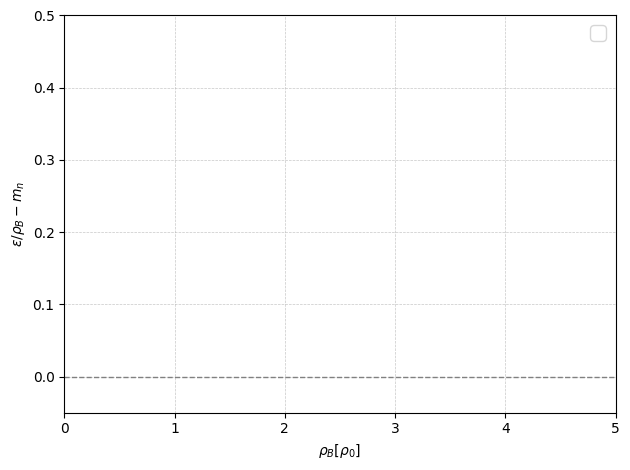

cs model
isospin-blind repulsion $b_n = b_{pn}$


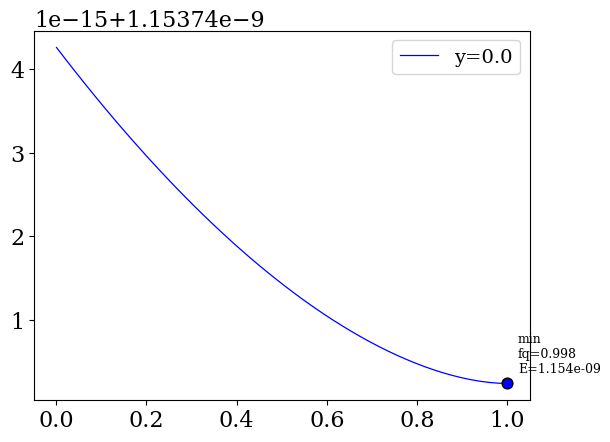

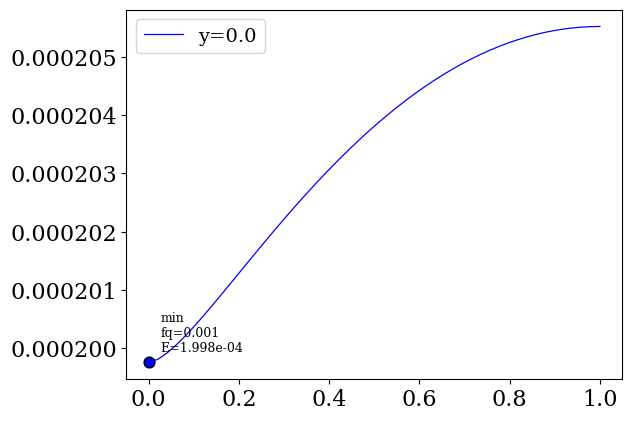

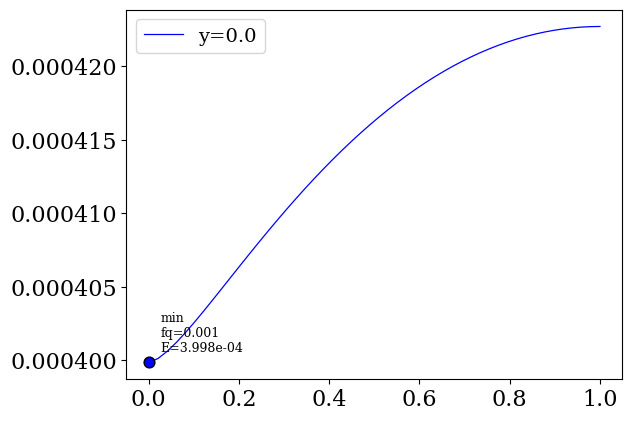

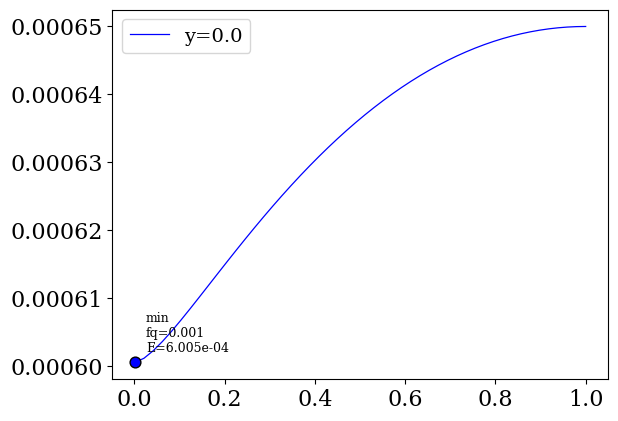

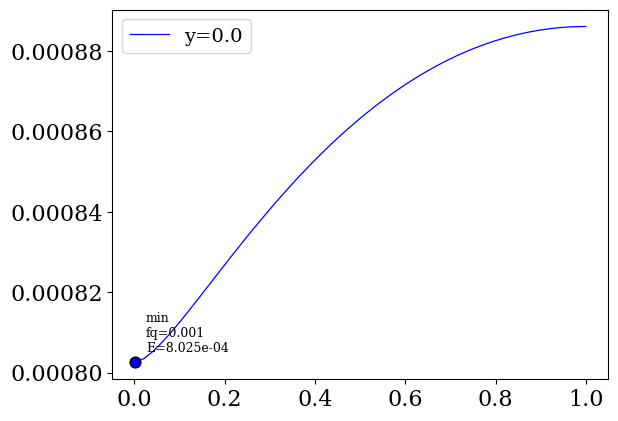

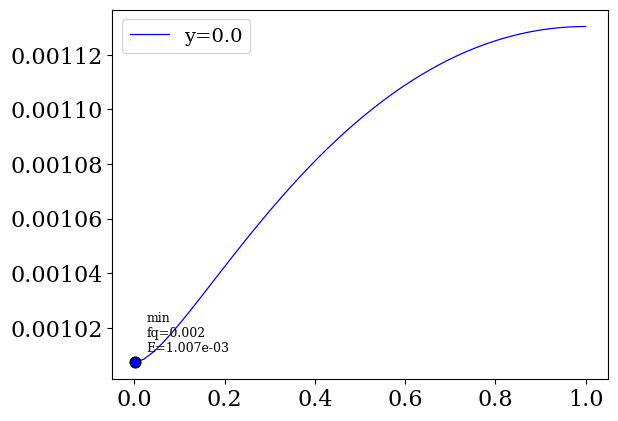

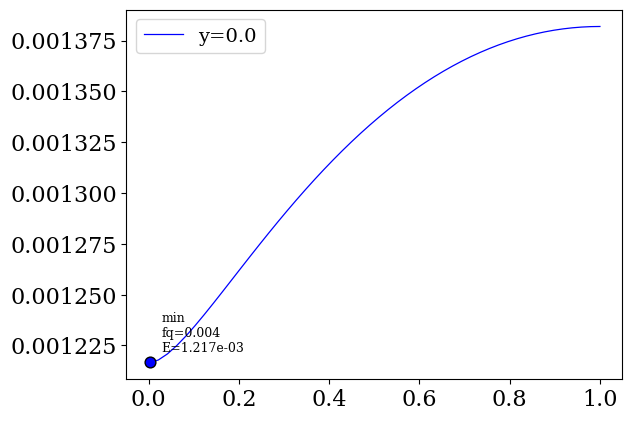

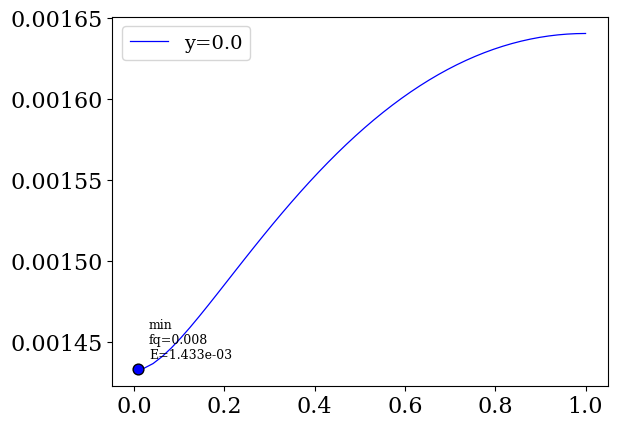

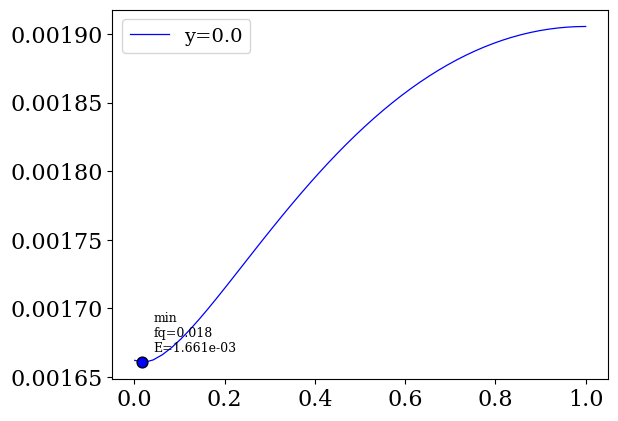

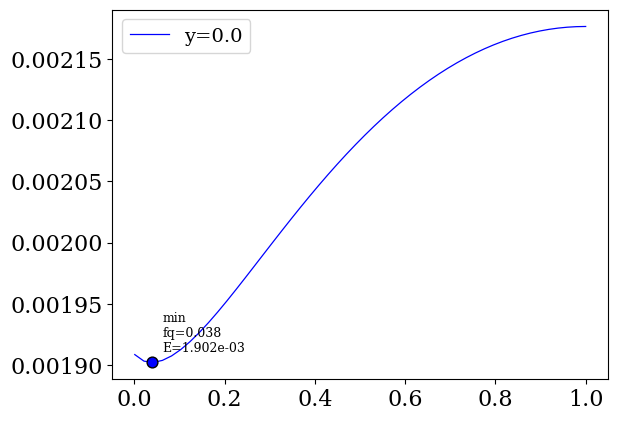

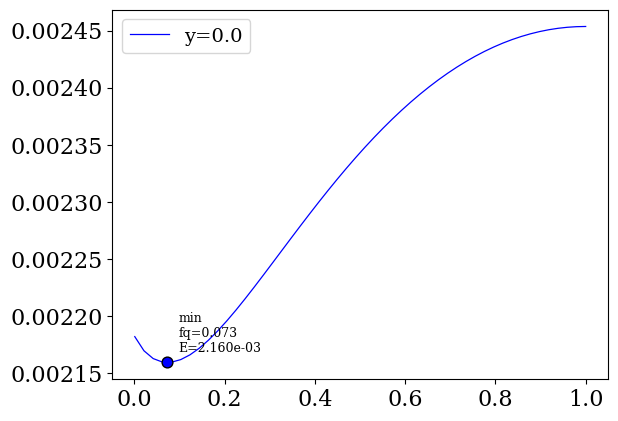

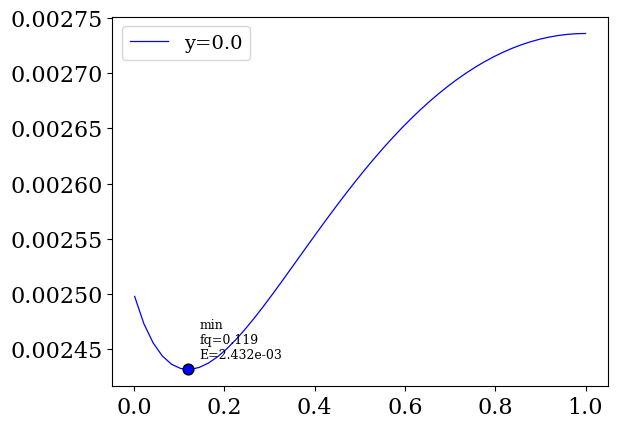

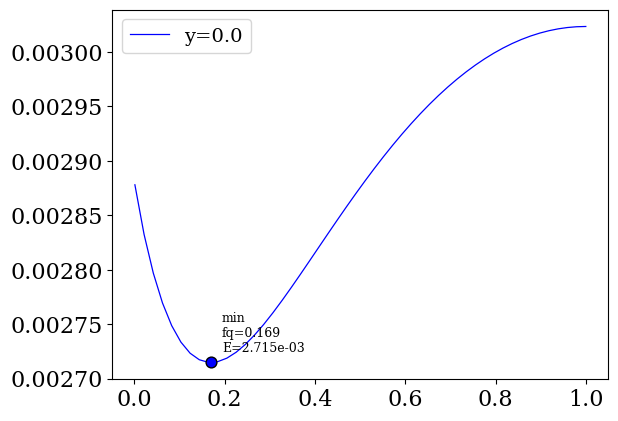

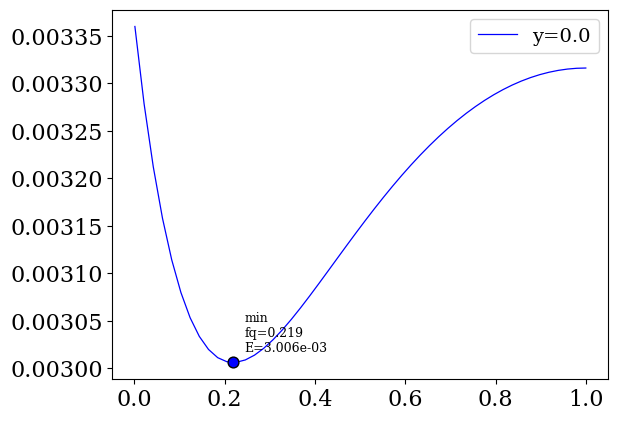

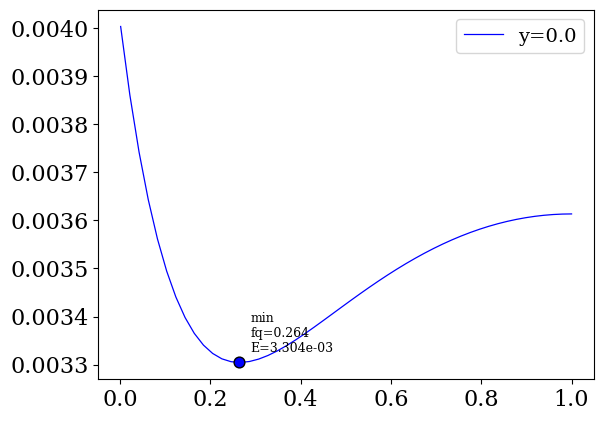

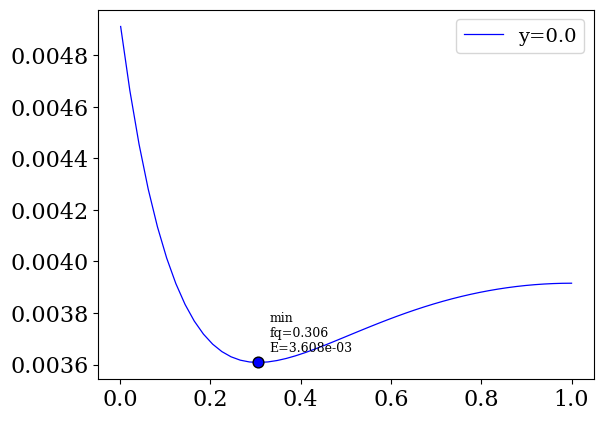

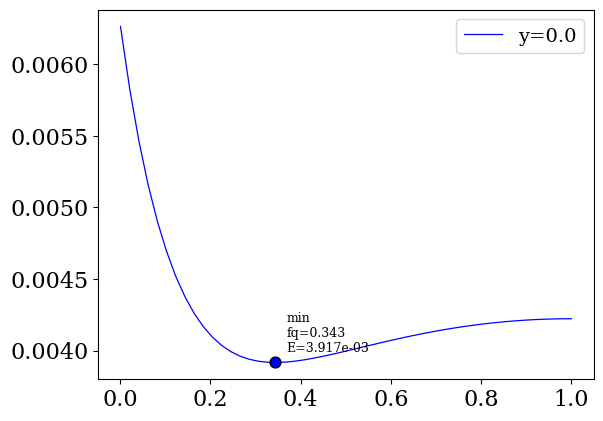

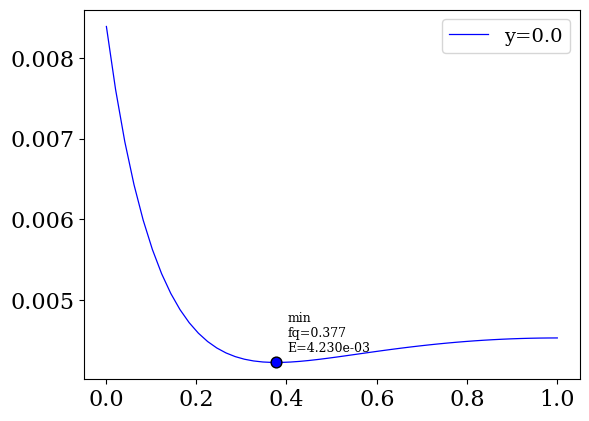

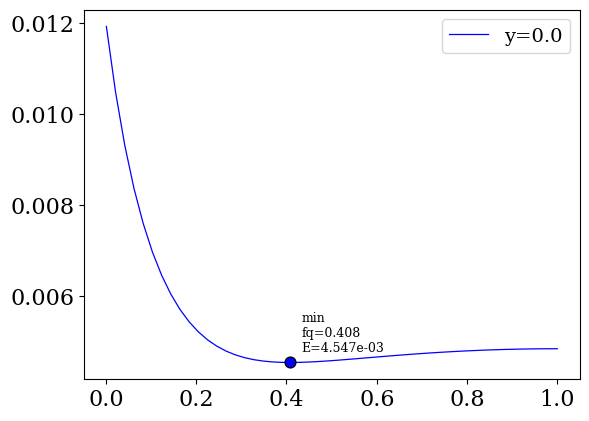

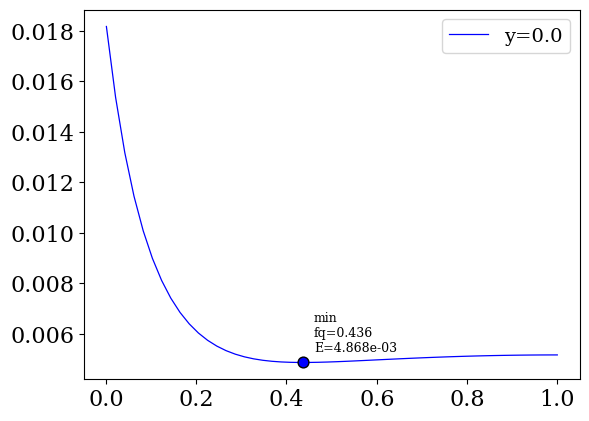

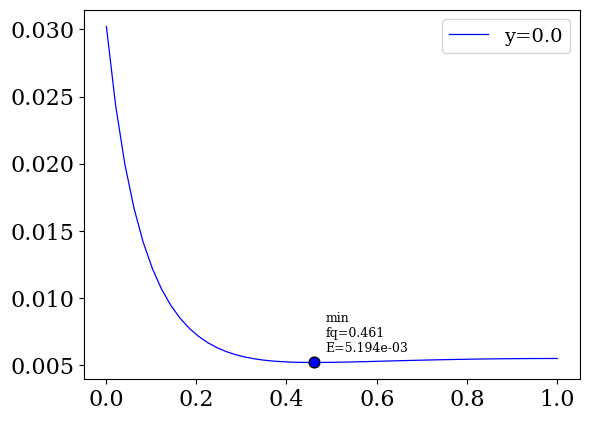

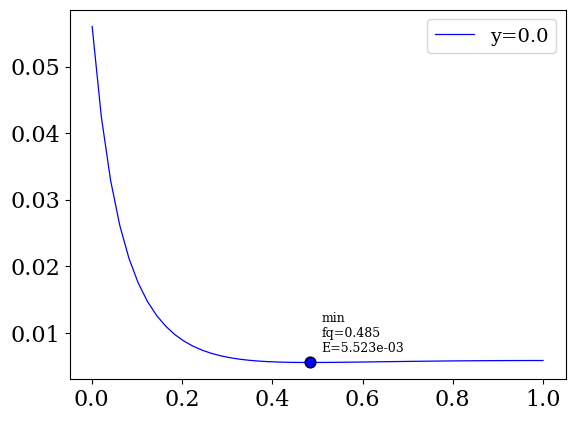

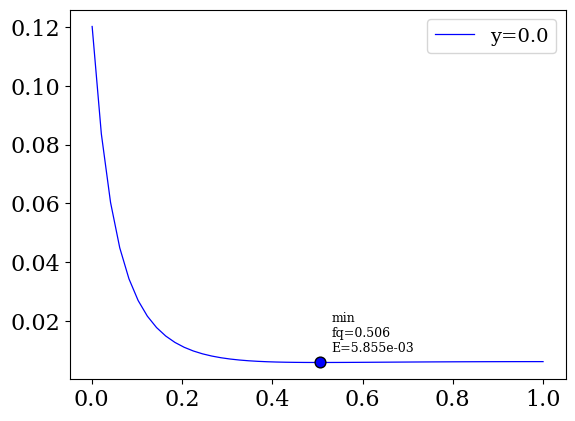

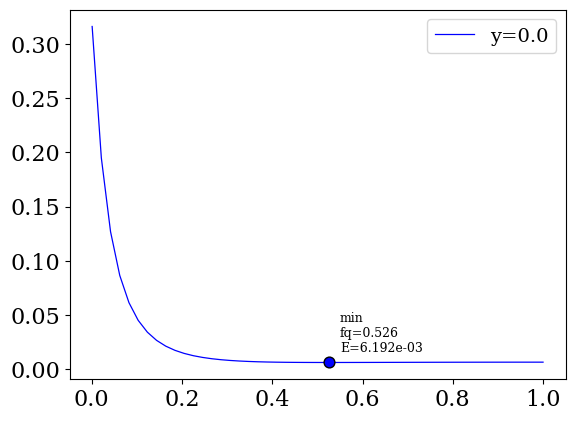

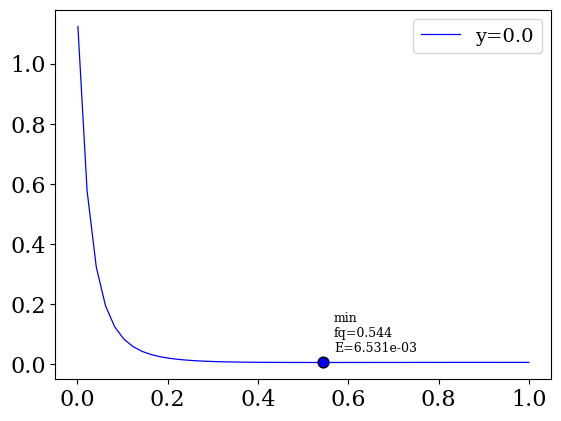

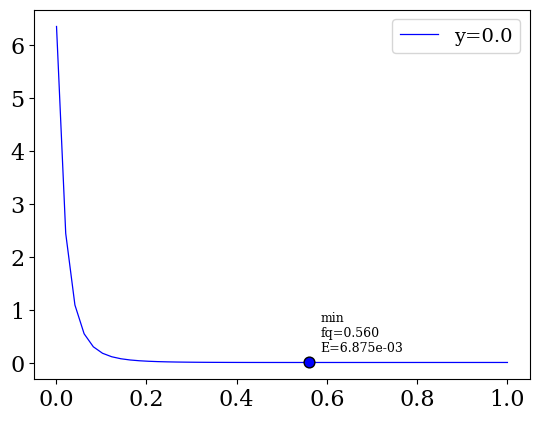

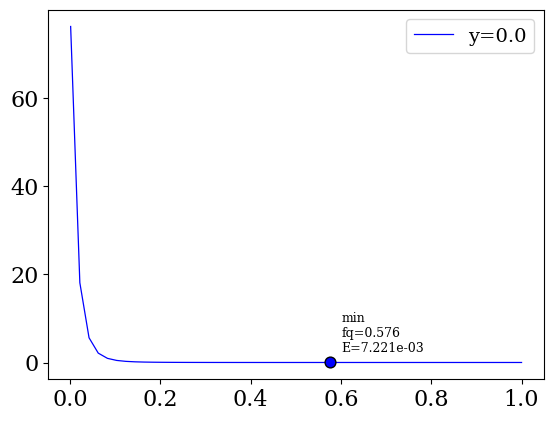

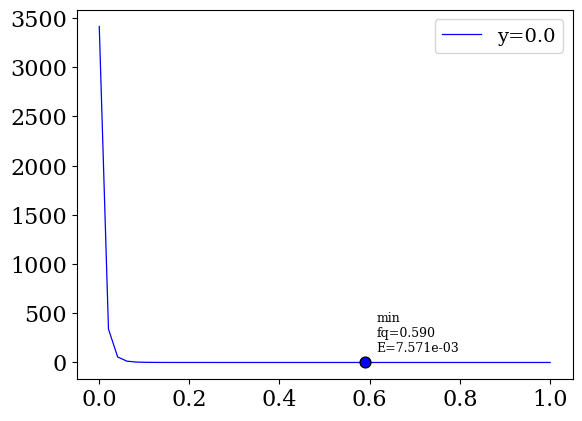

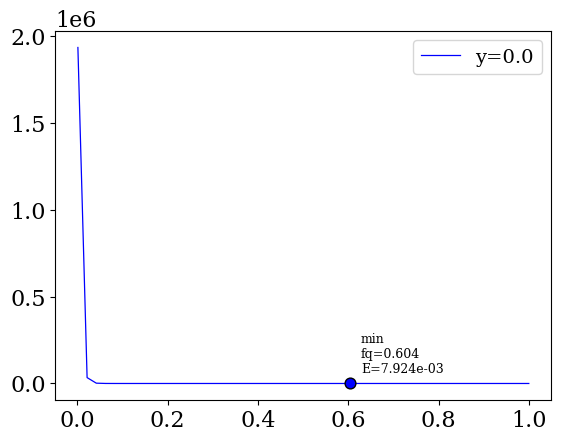

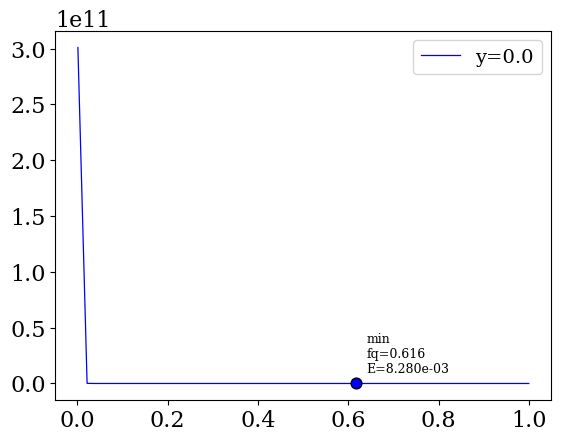

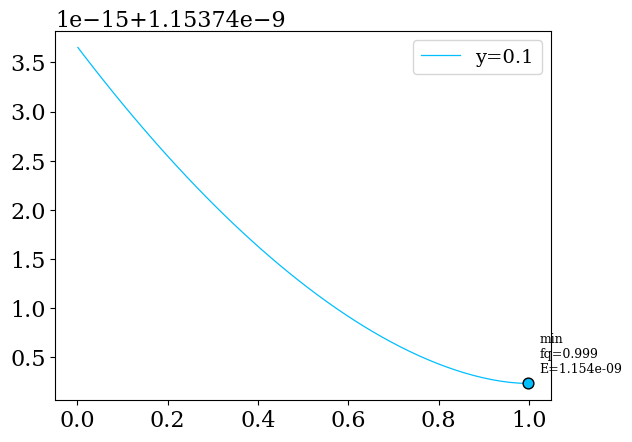

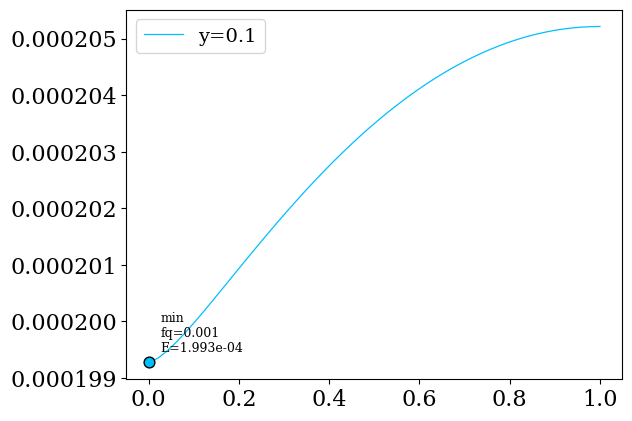

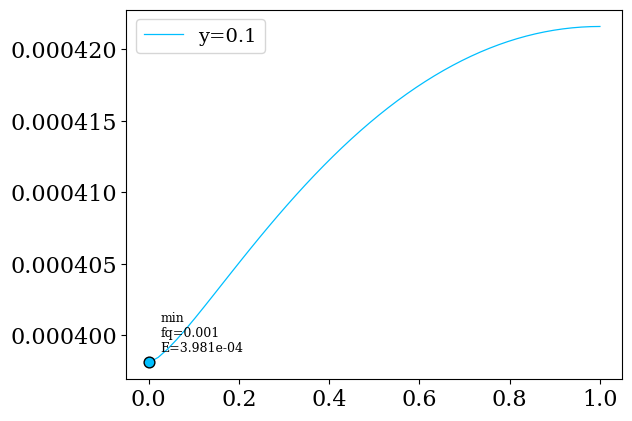

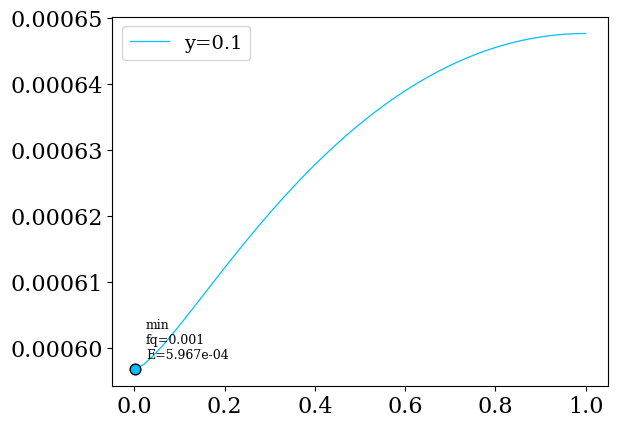

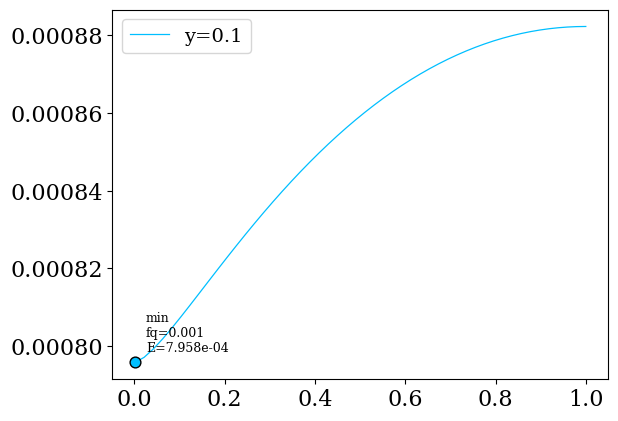

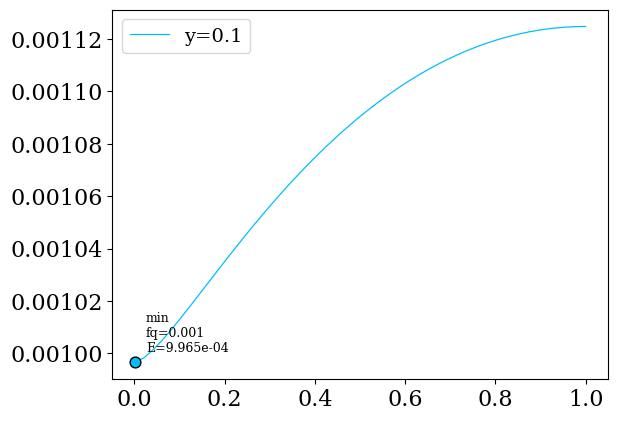

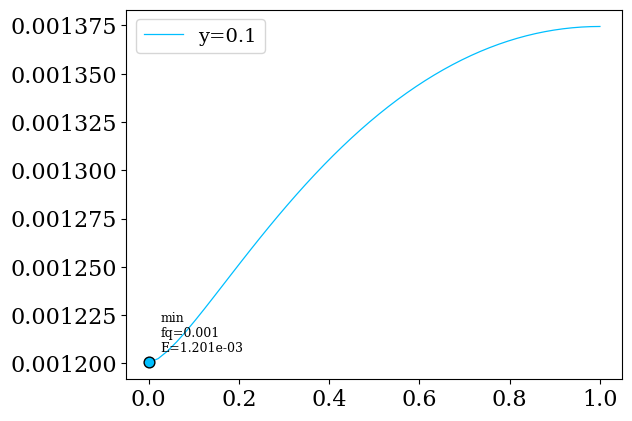

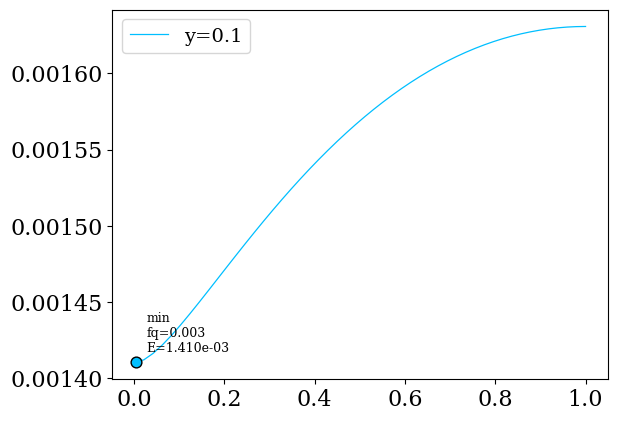

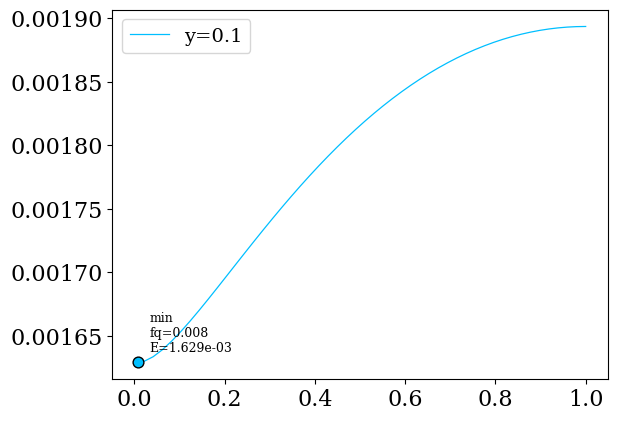

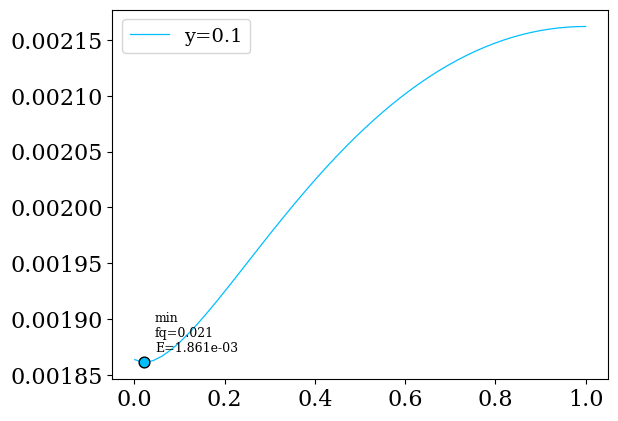

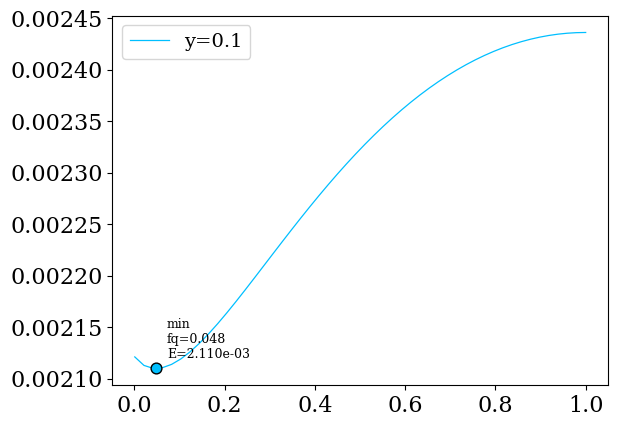

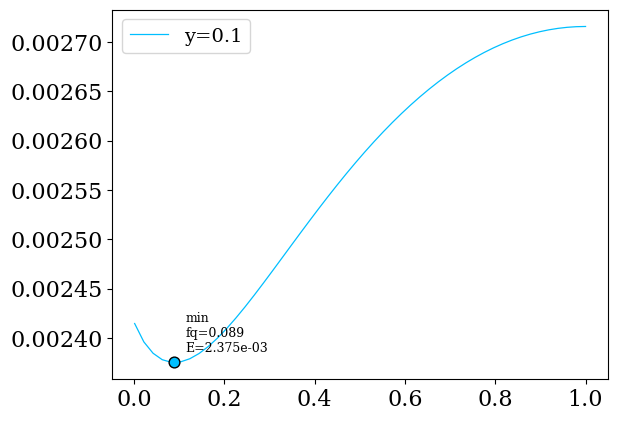

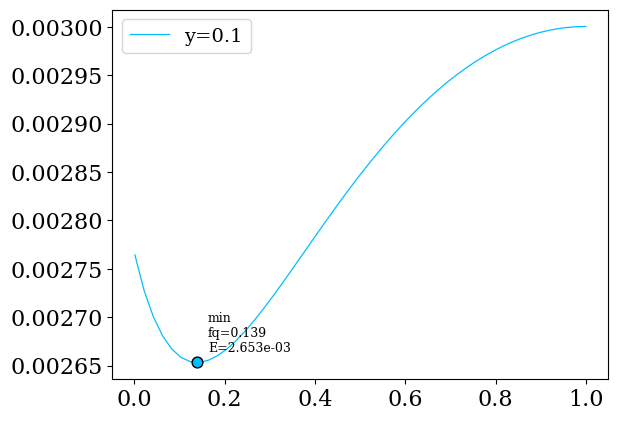

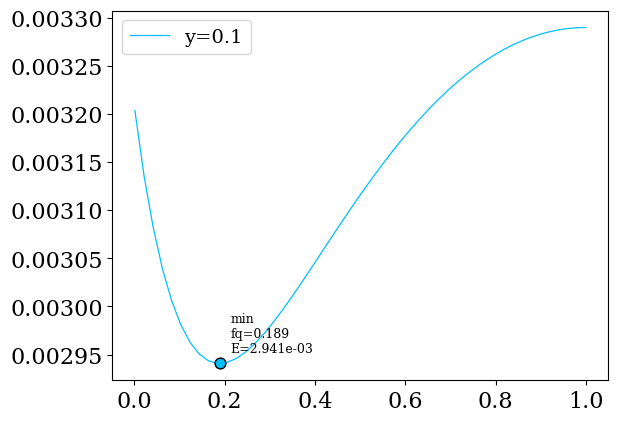

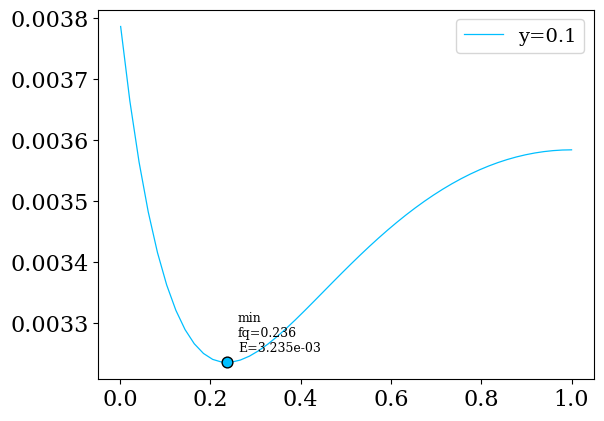

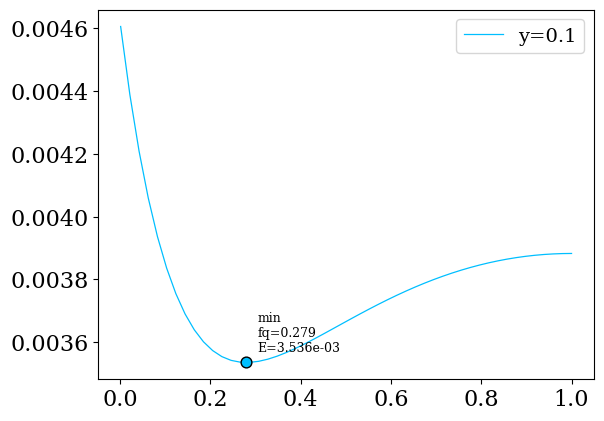

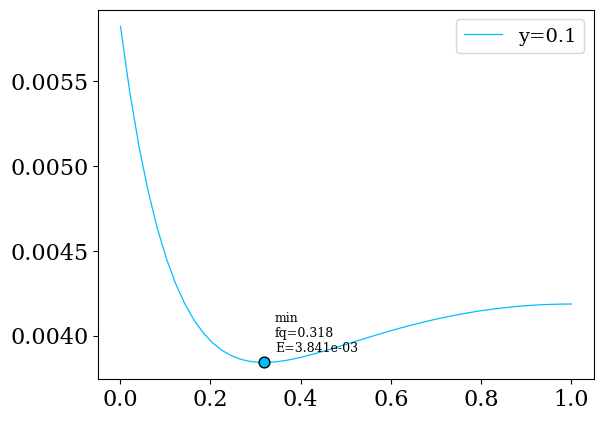

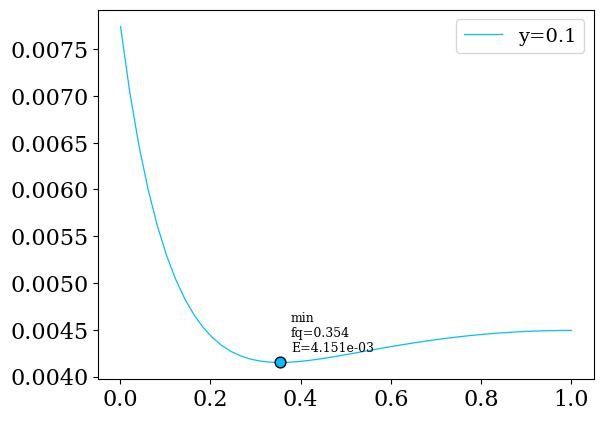

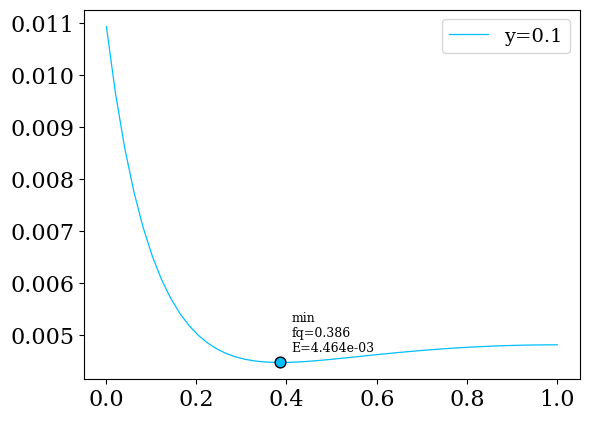

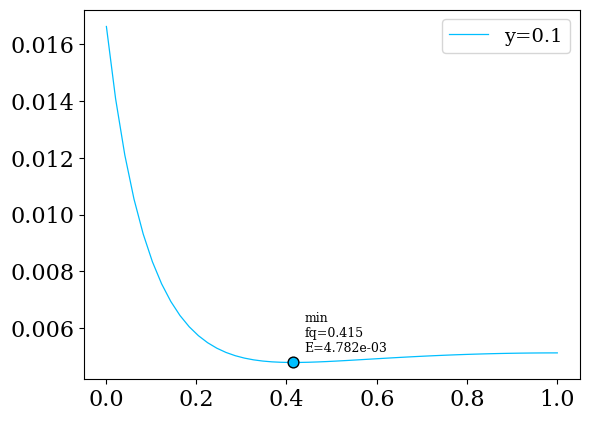

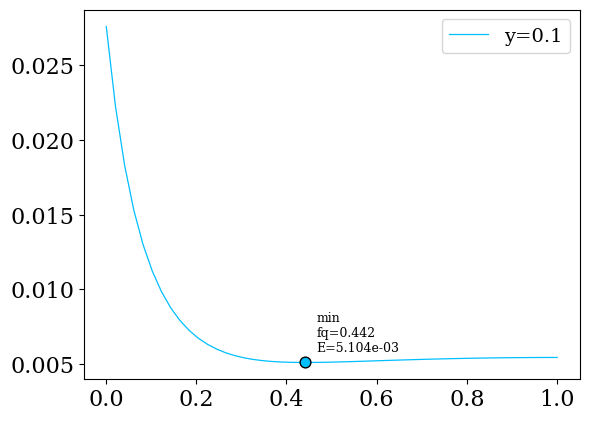

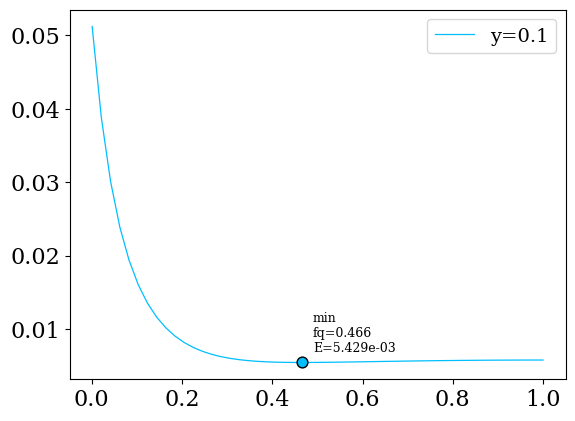

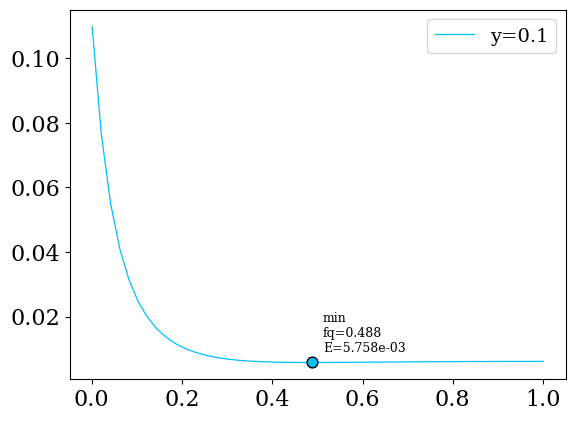

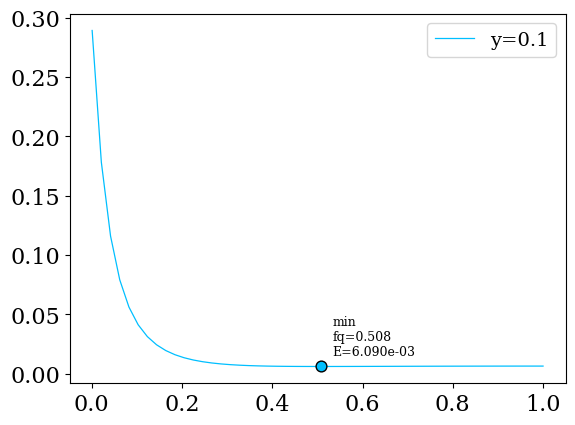

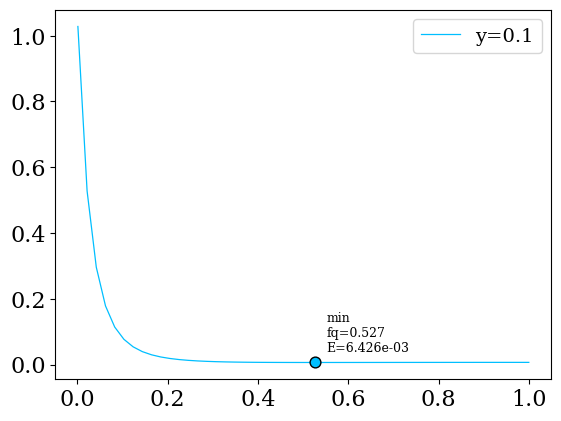

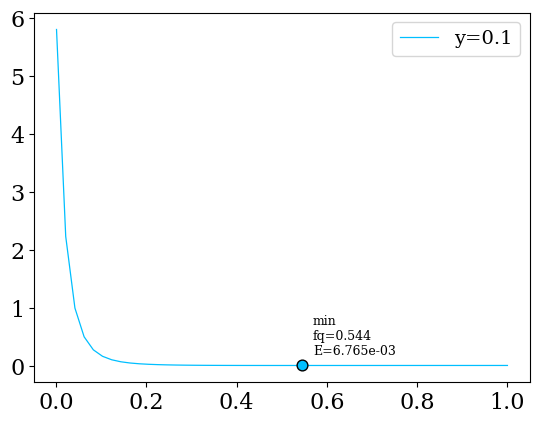

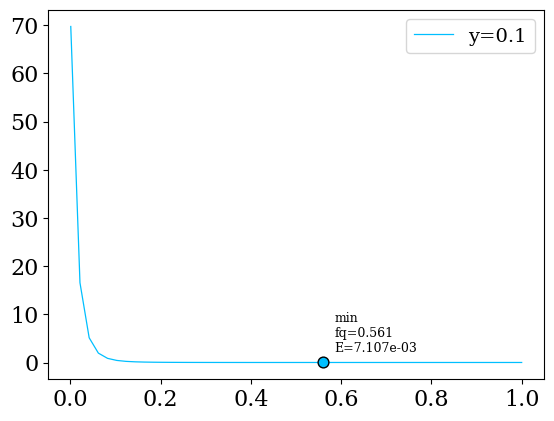

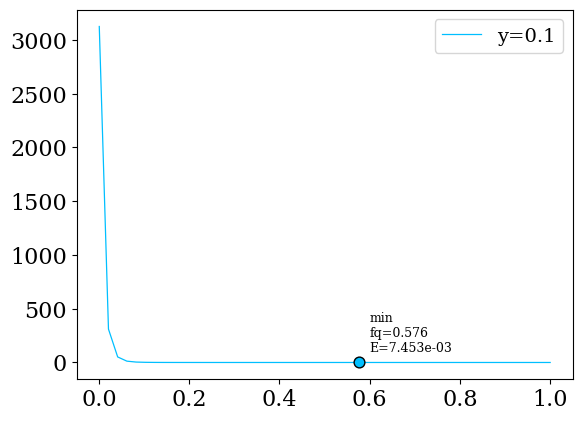

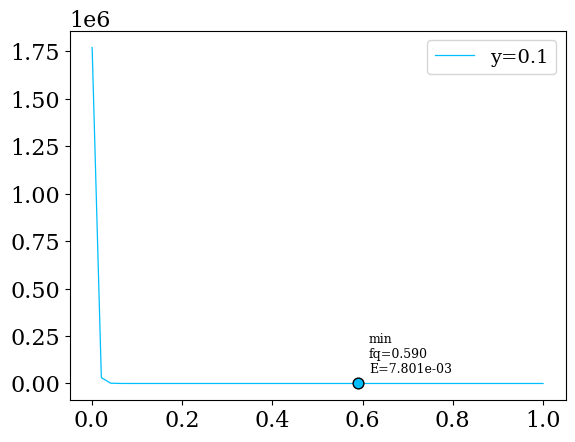

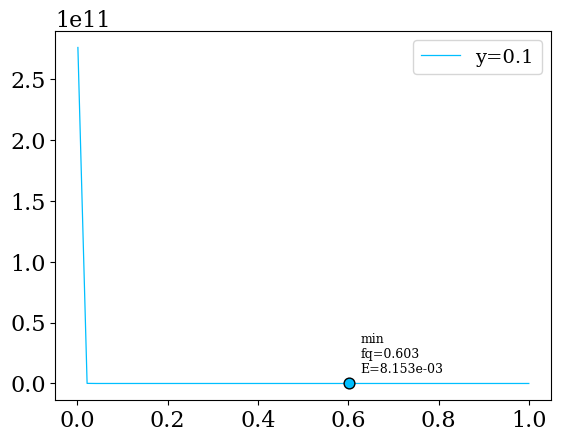

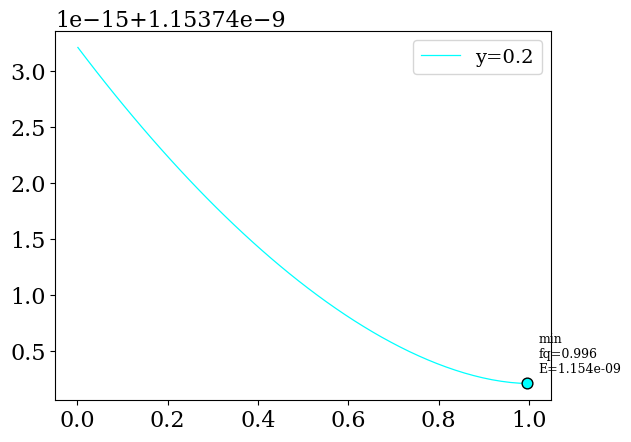

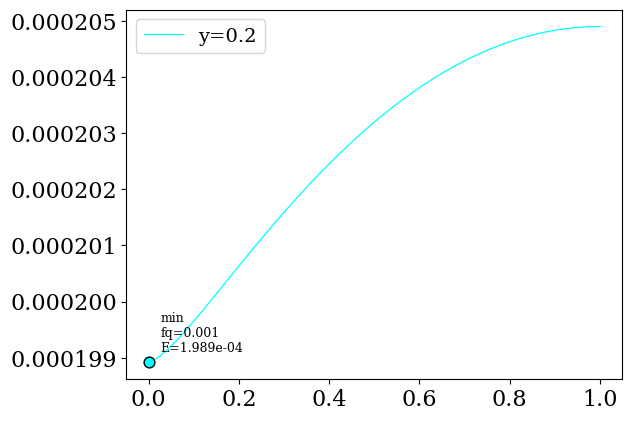

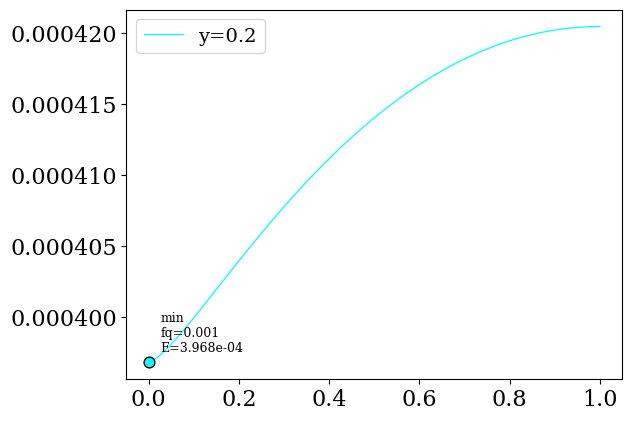

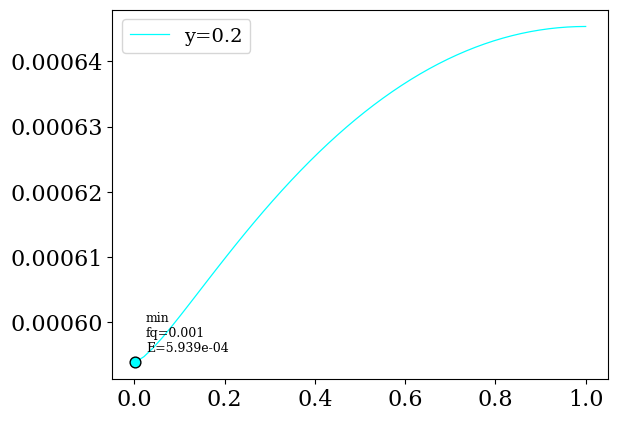

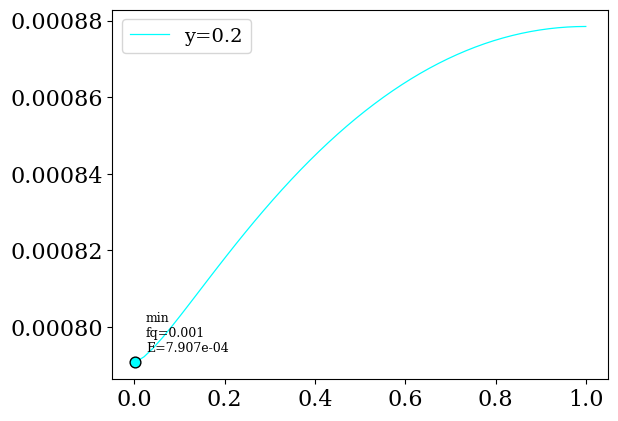

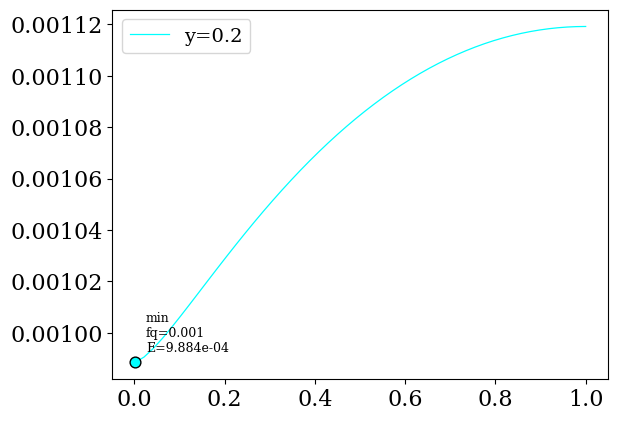

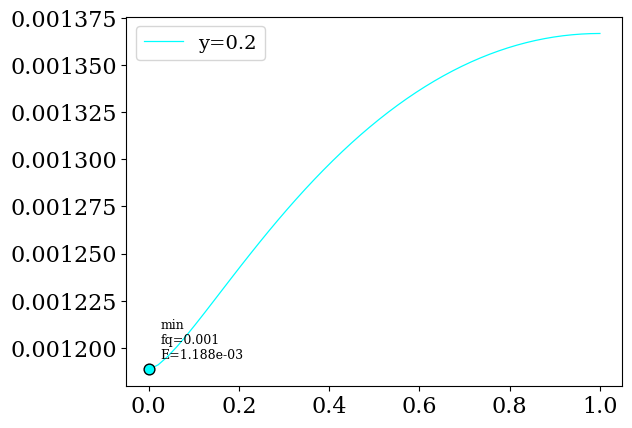

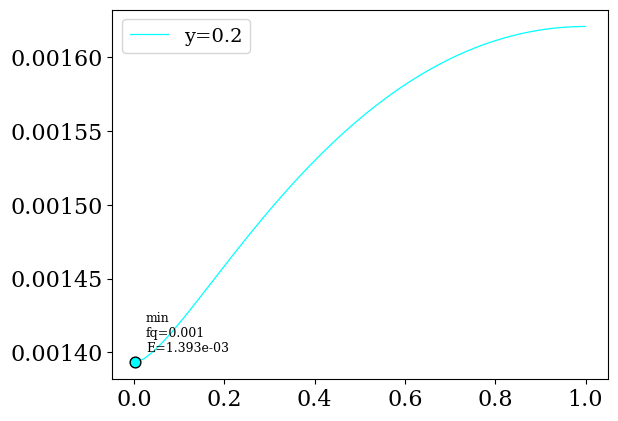

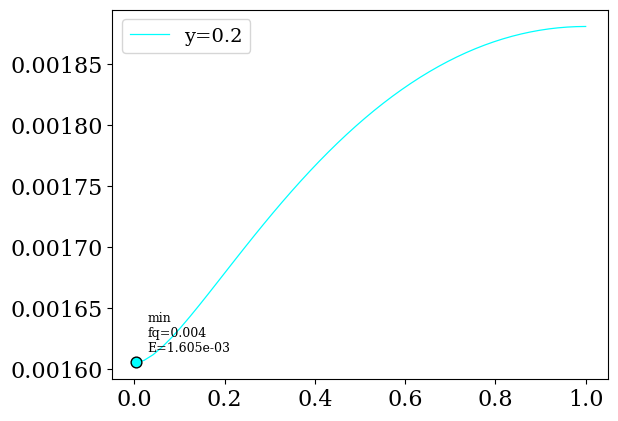

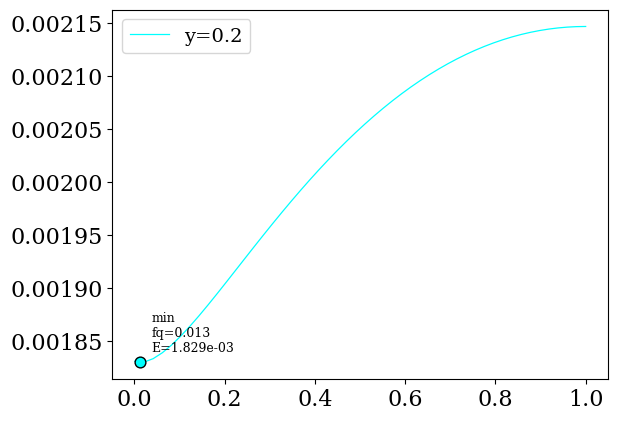

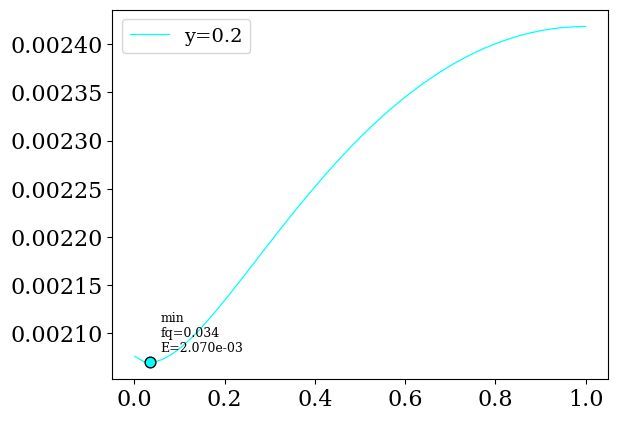

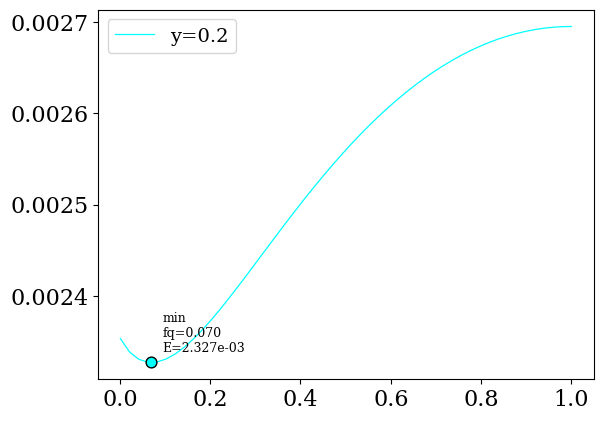

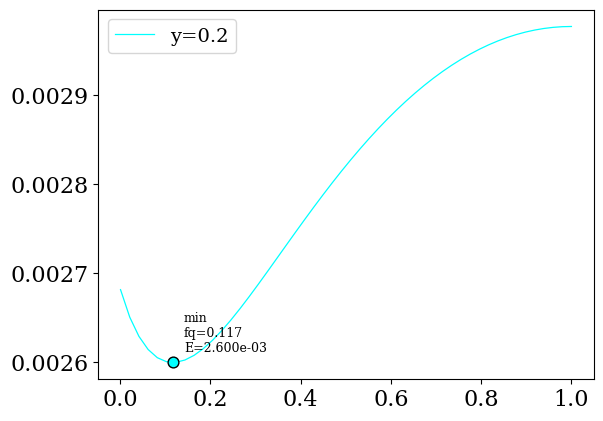

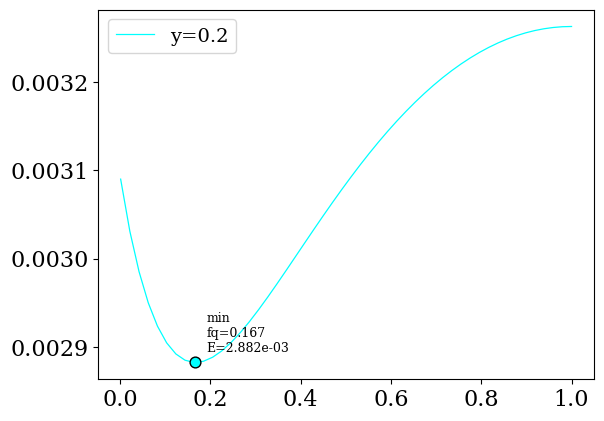

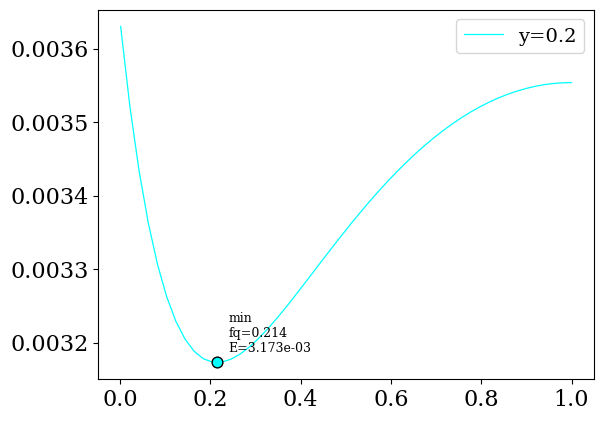

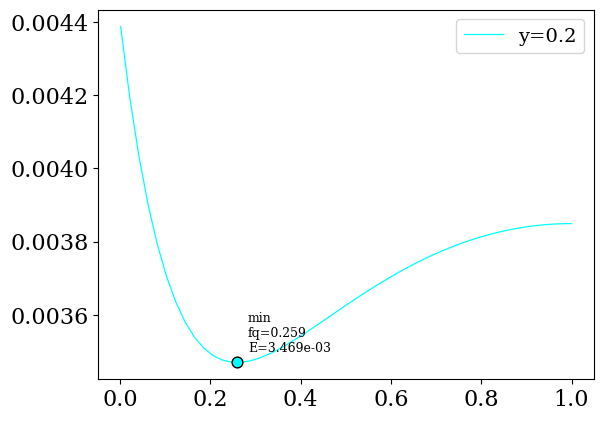

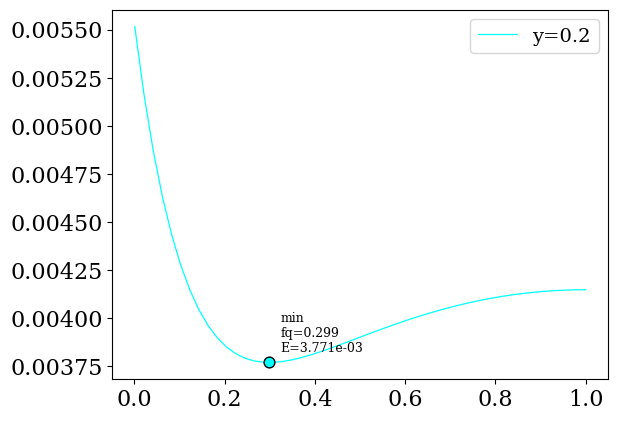

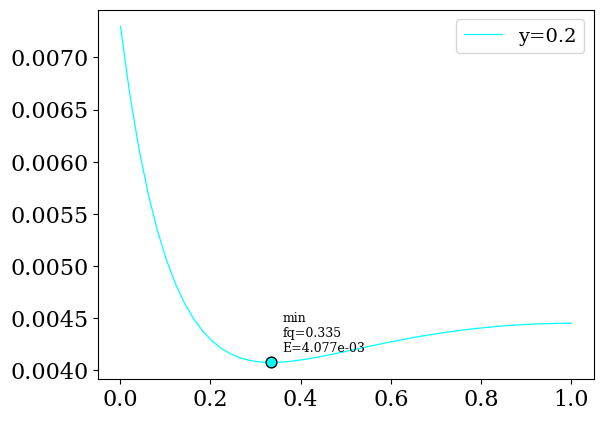

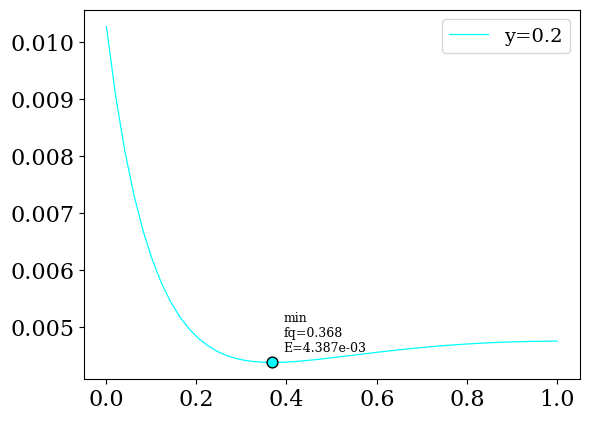

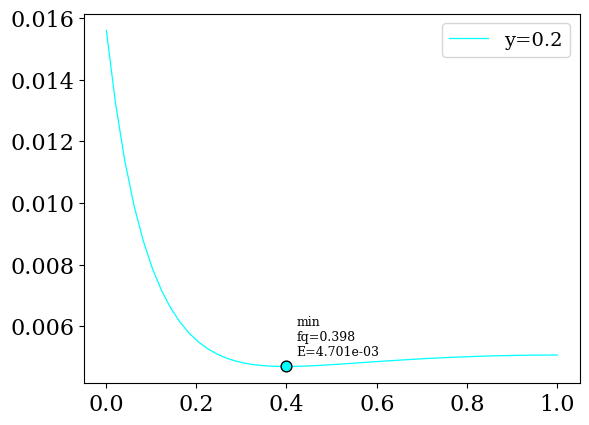

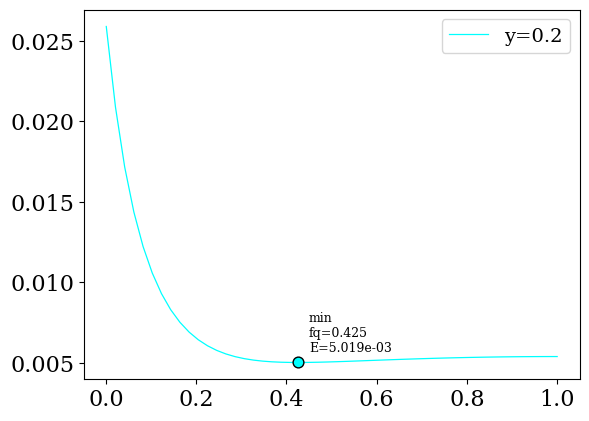

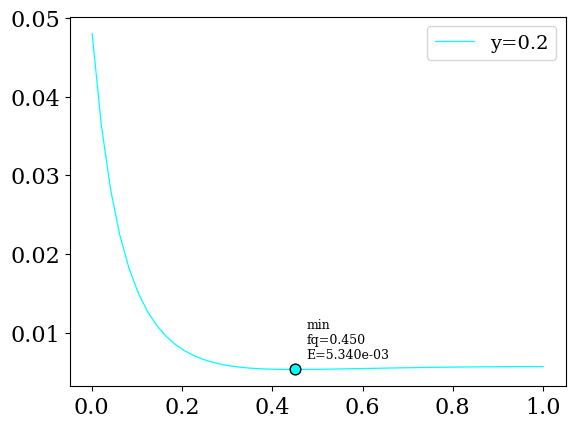

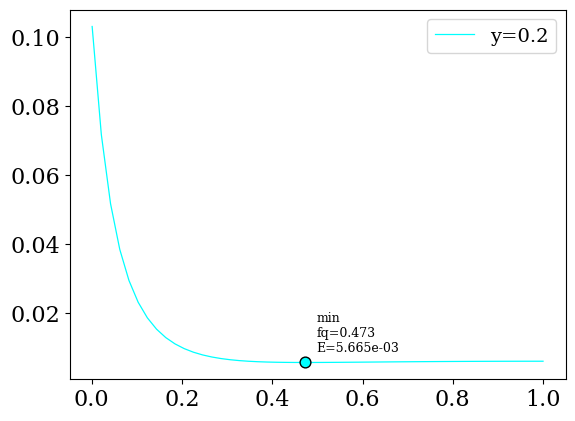

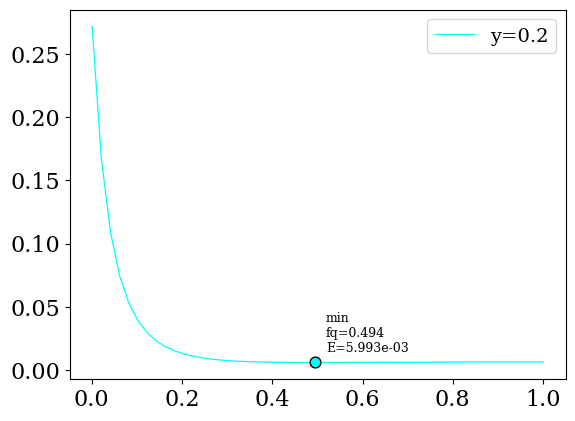

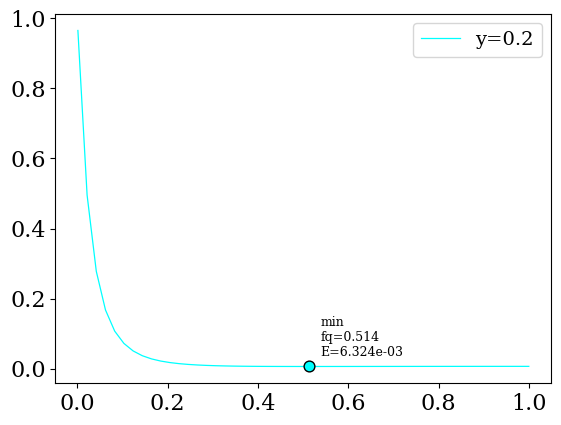

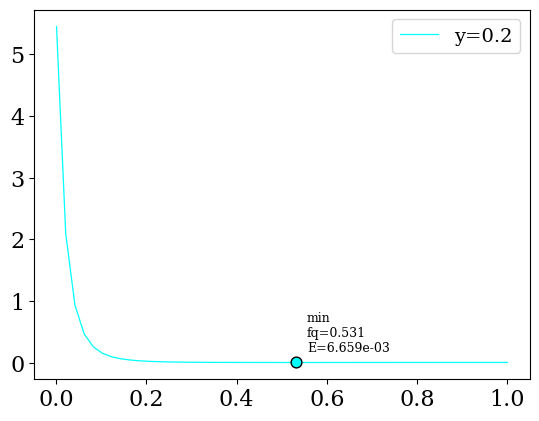

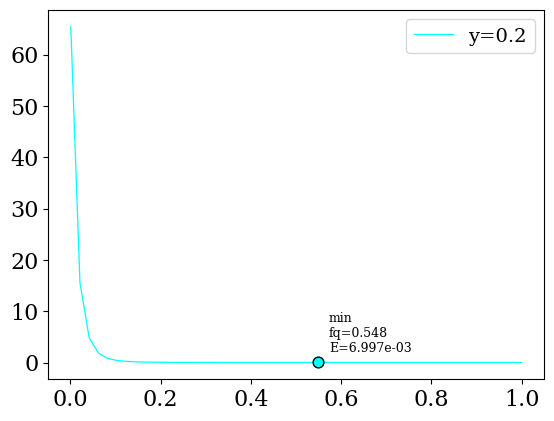

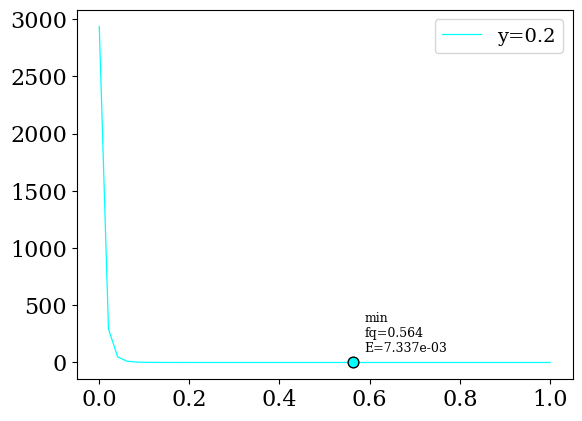

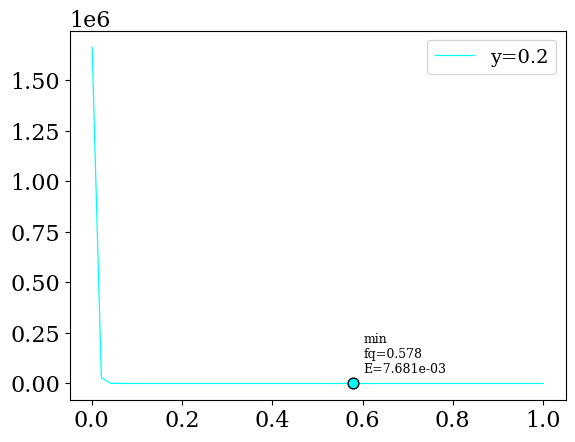

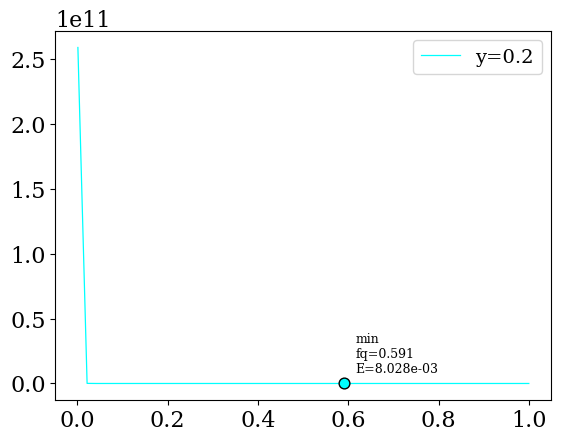

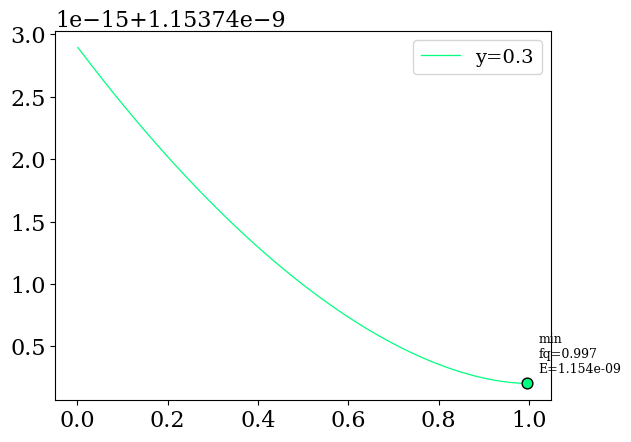

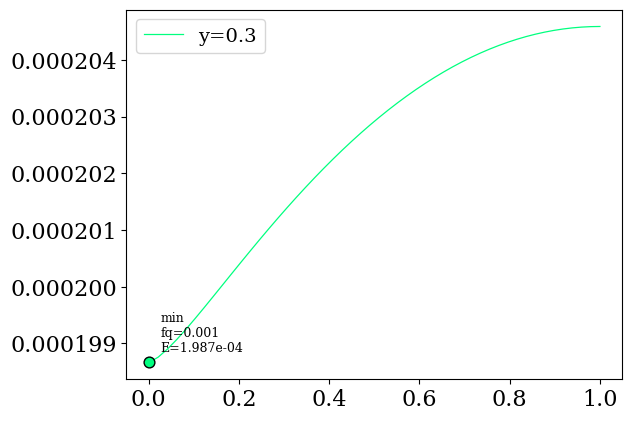

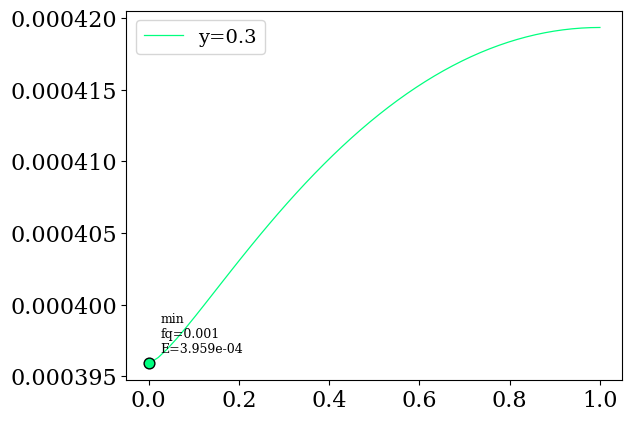

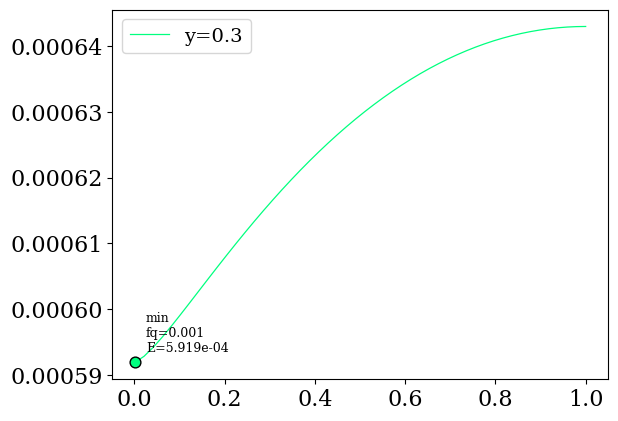

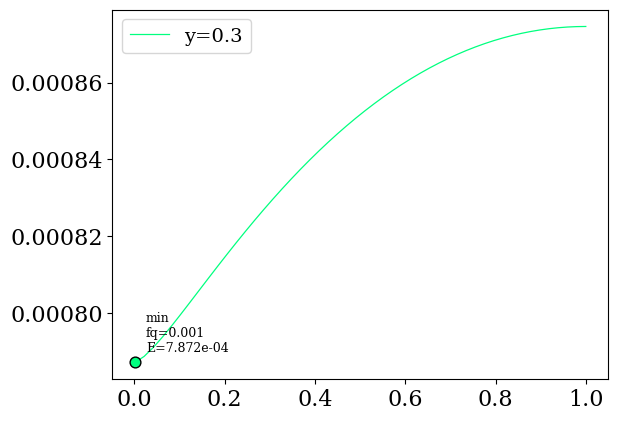

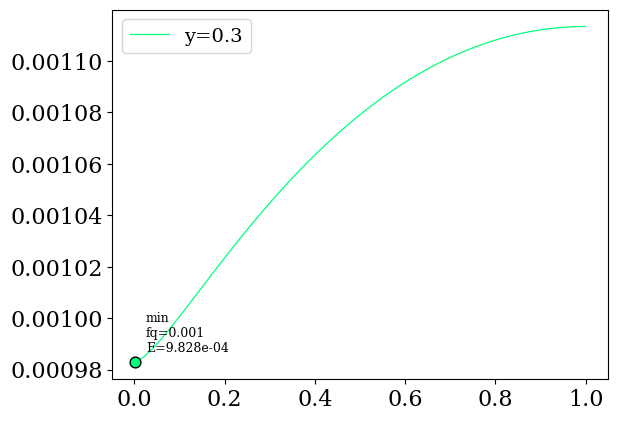

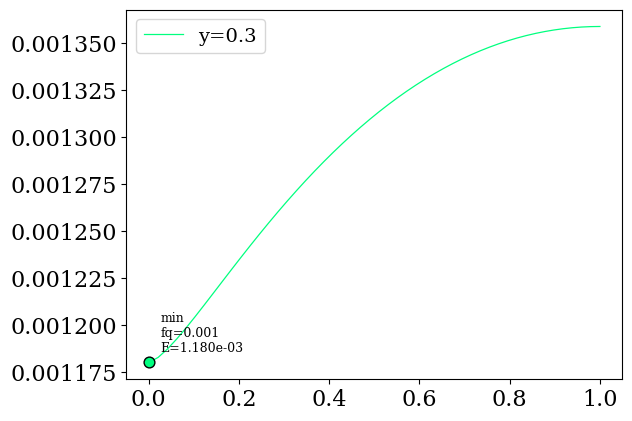

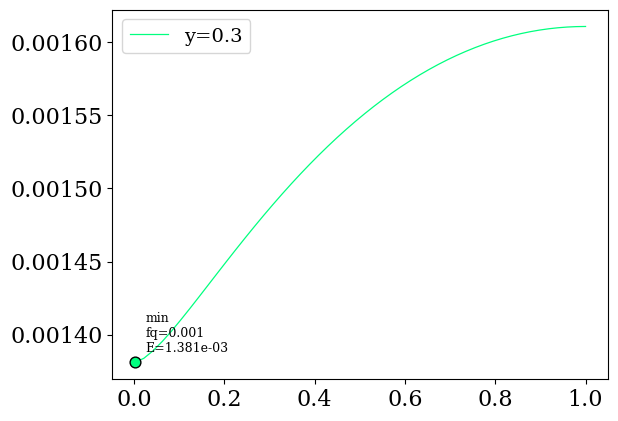

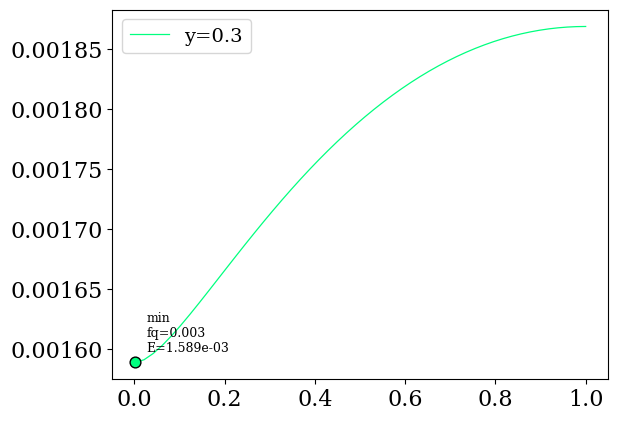

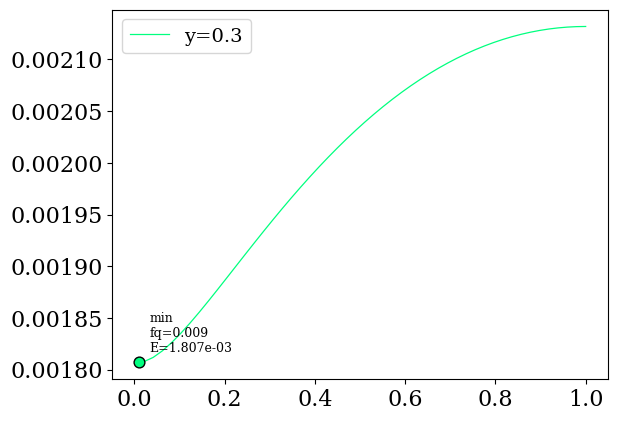

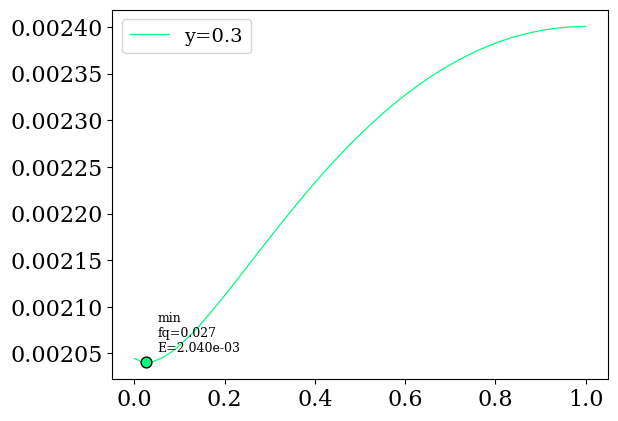

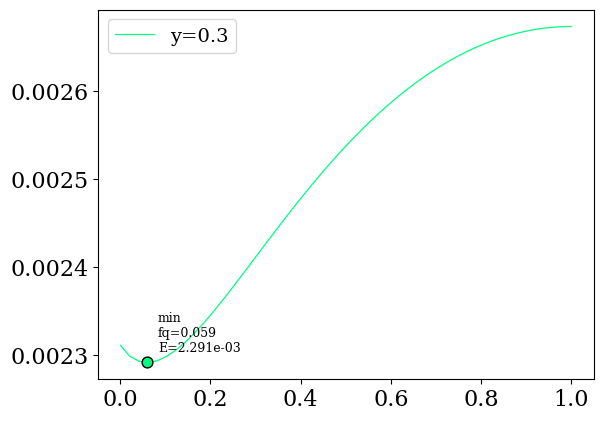

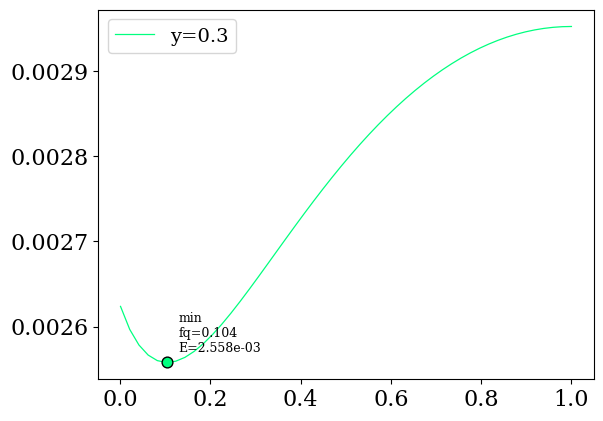

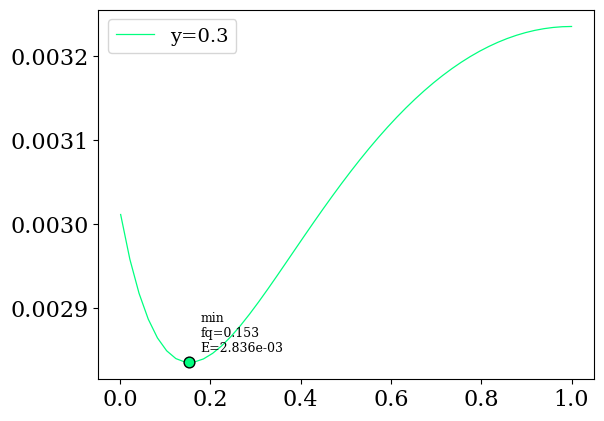

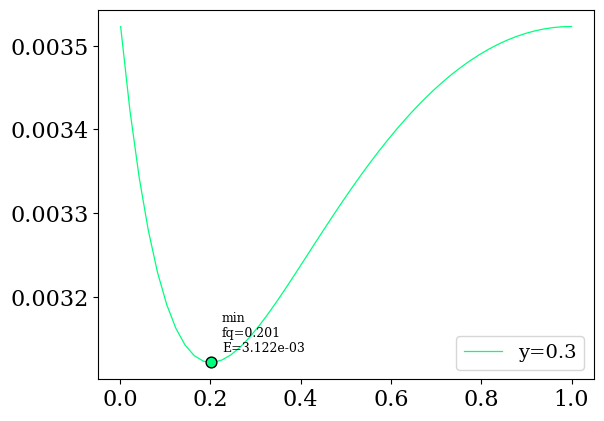

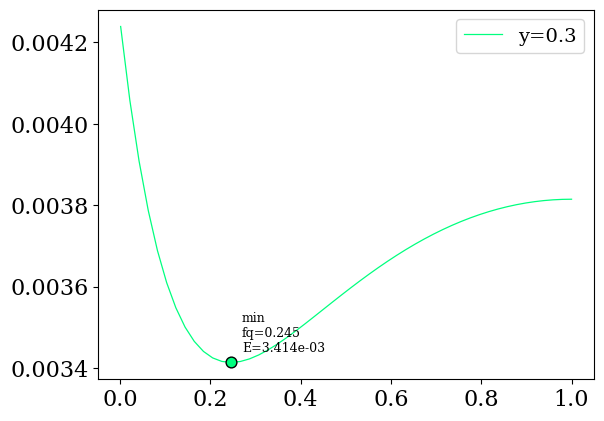

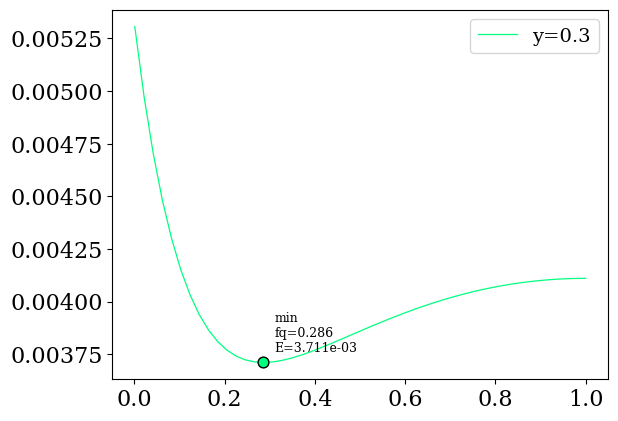

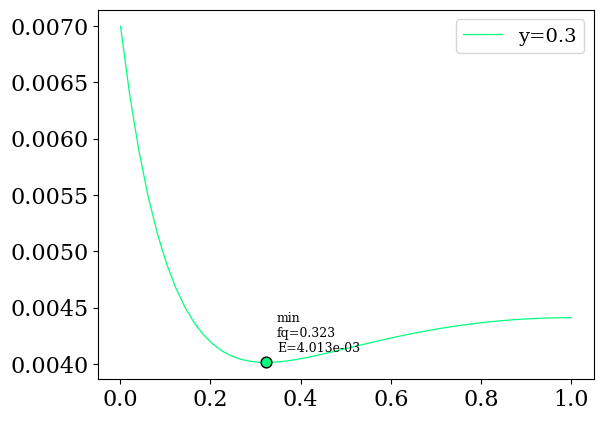

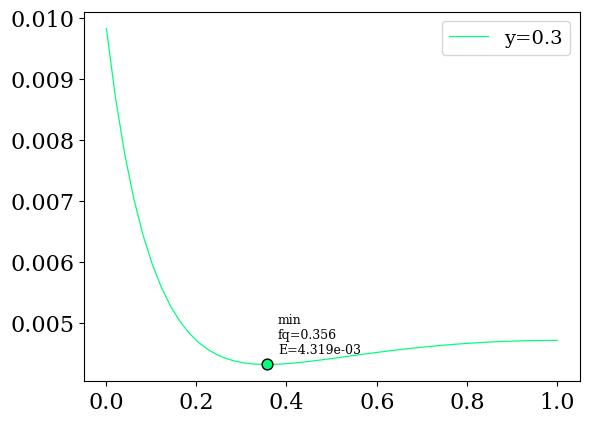

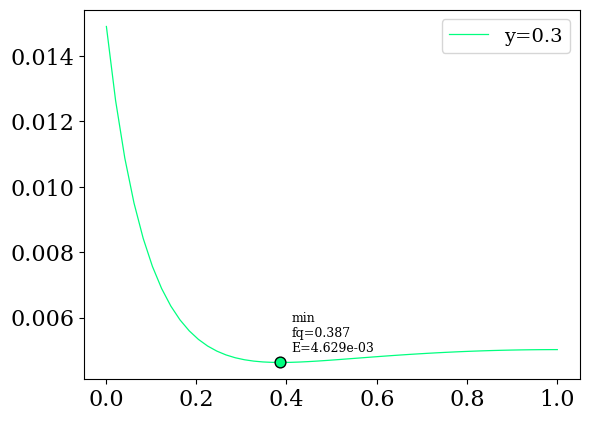

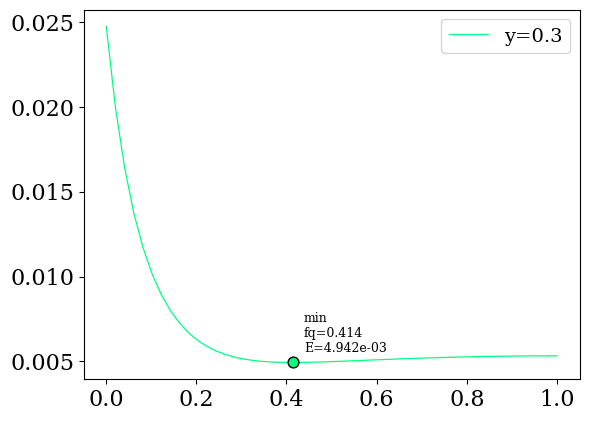

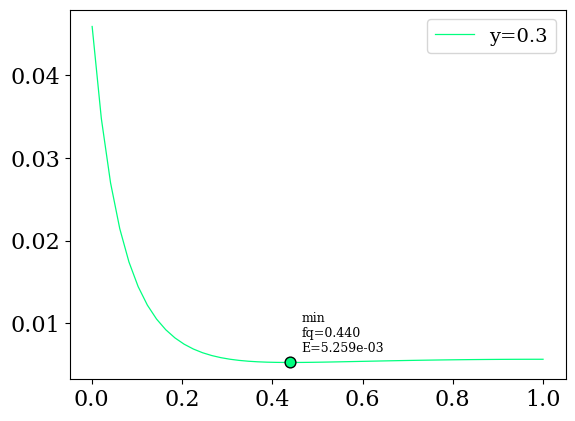

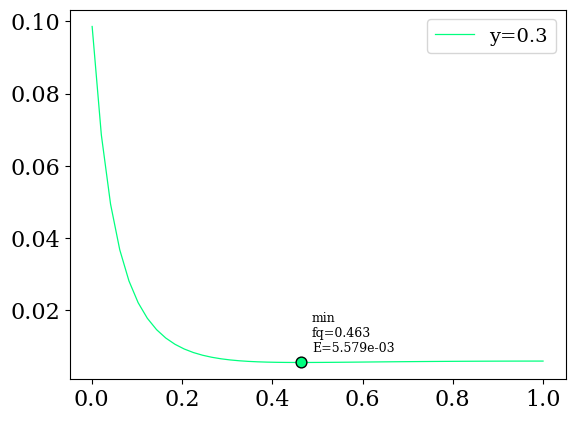

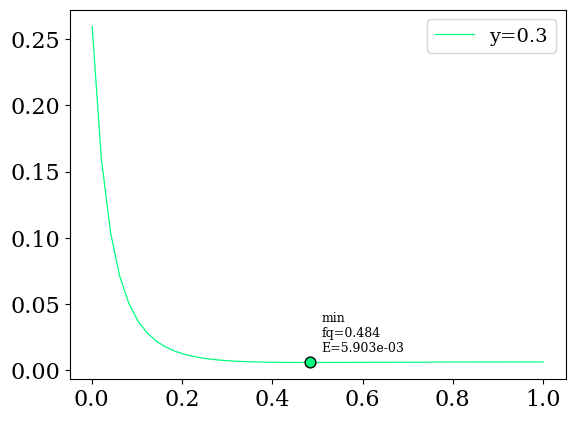

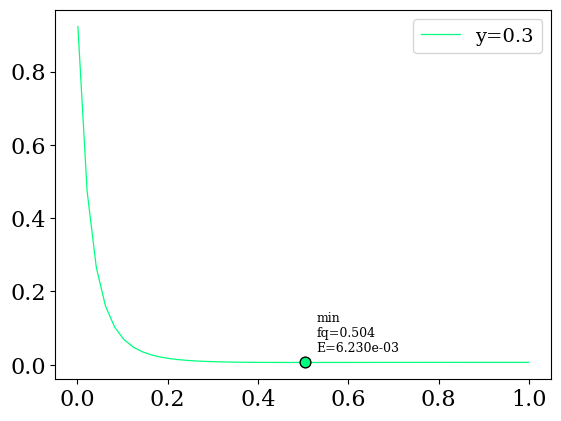

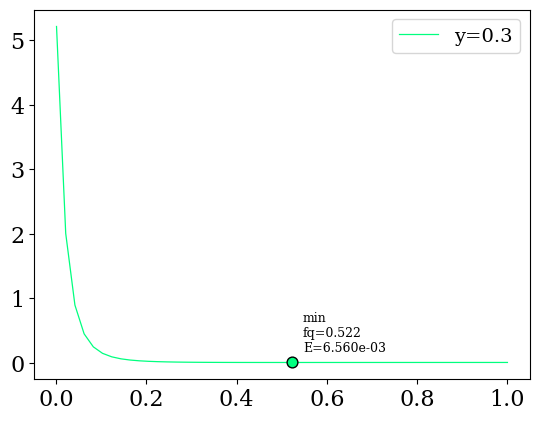

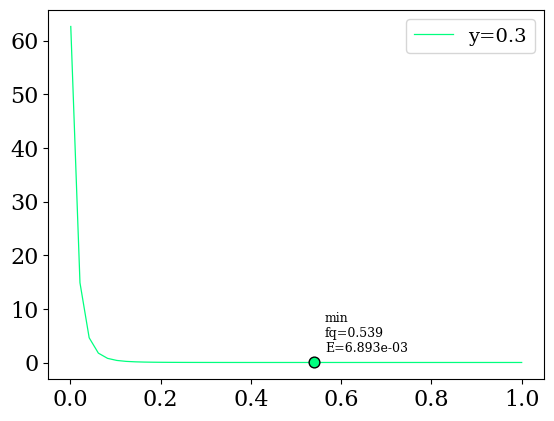

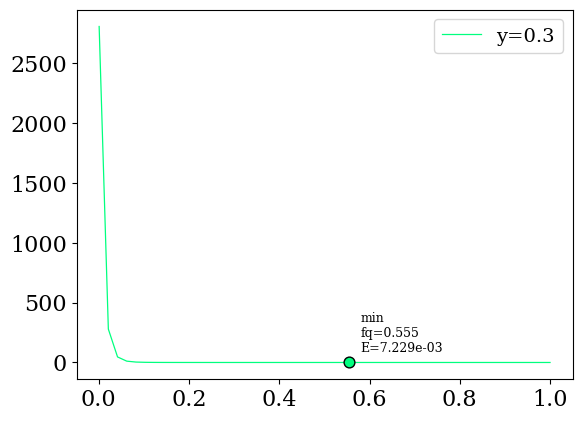

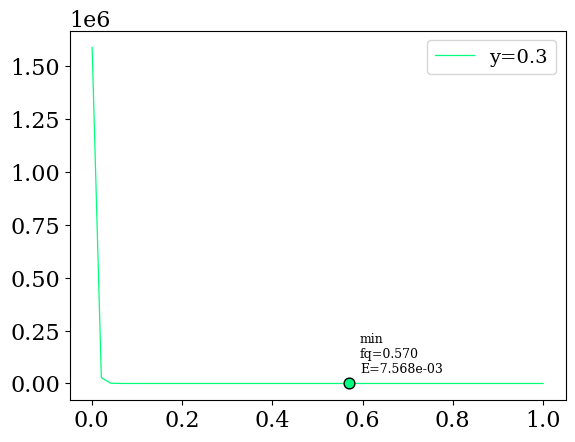

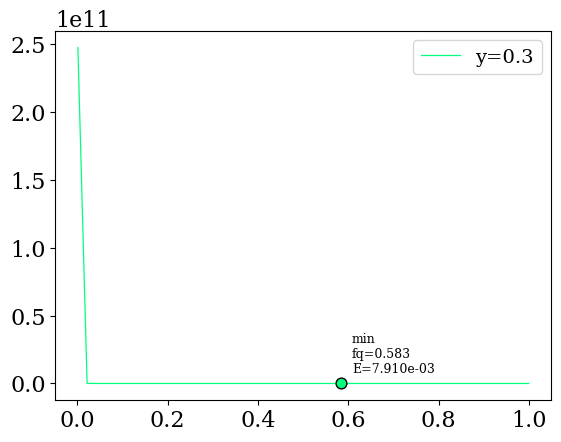

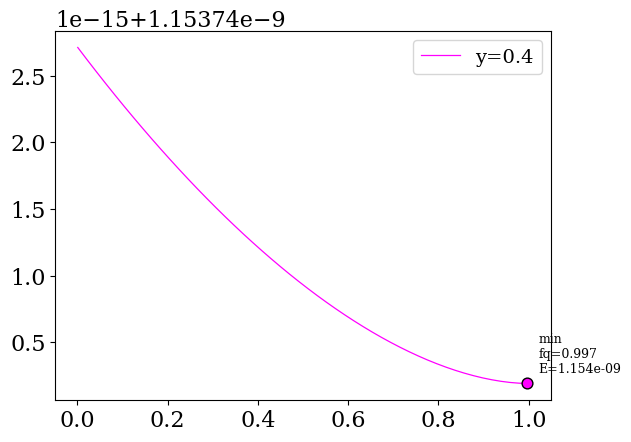

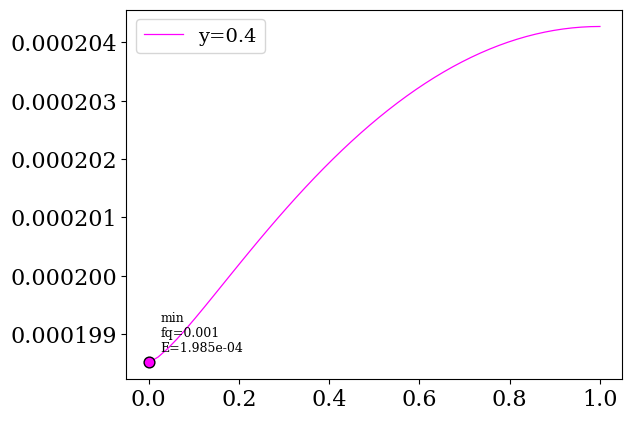

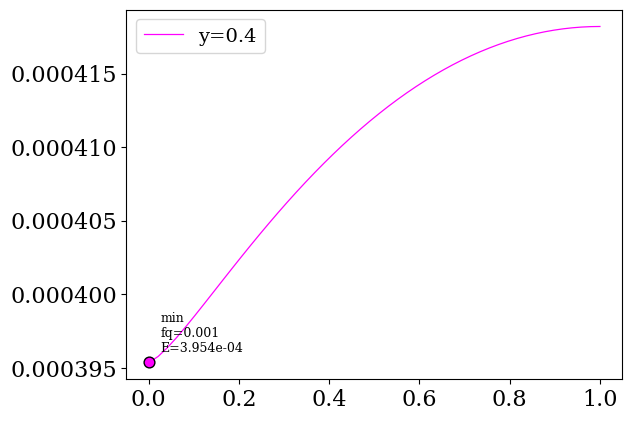

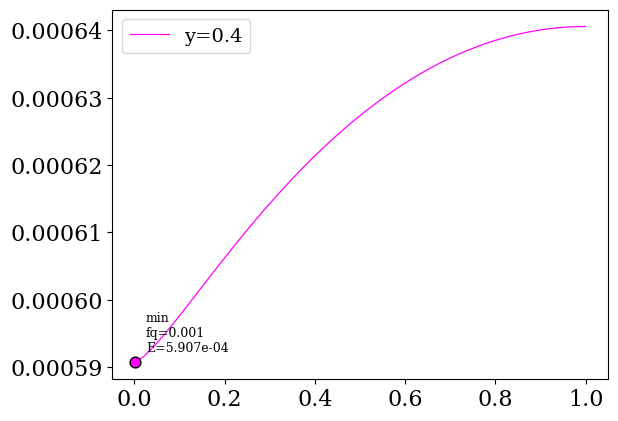

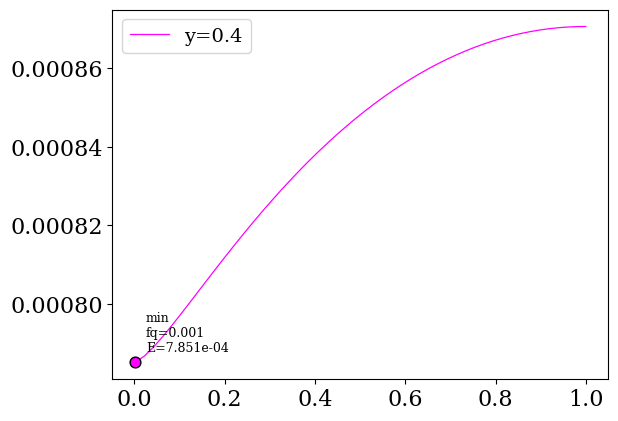

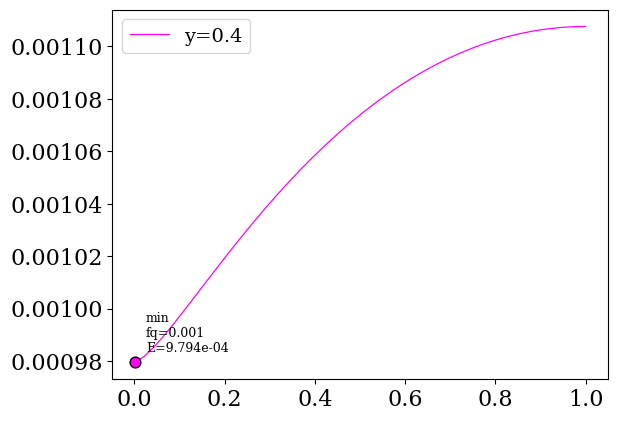

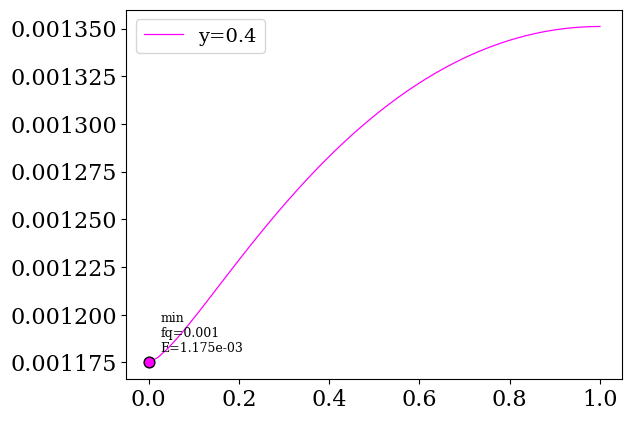

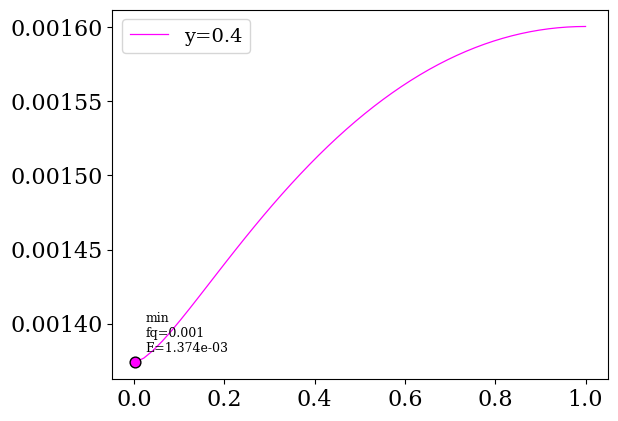

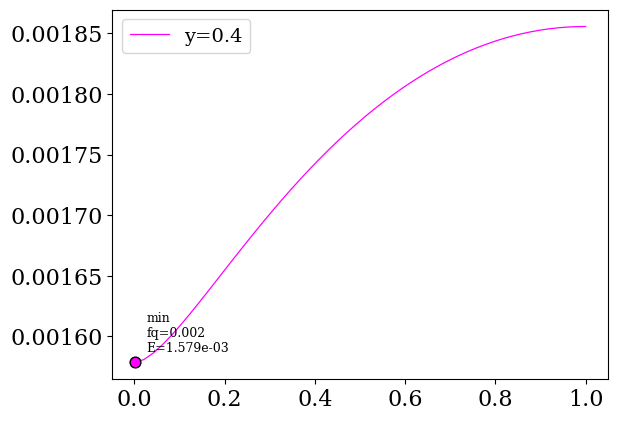

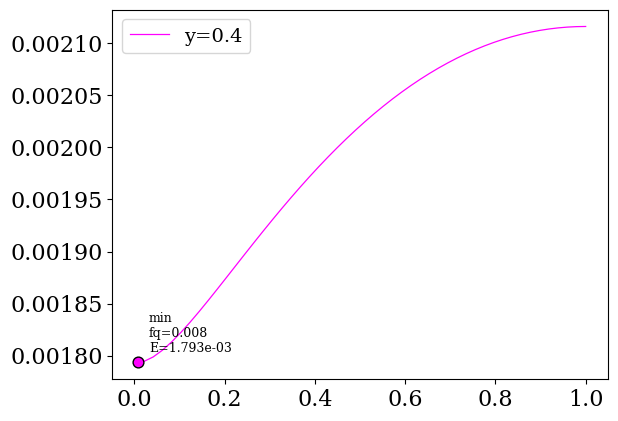

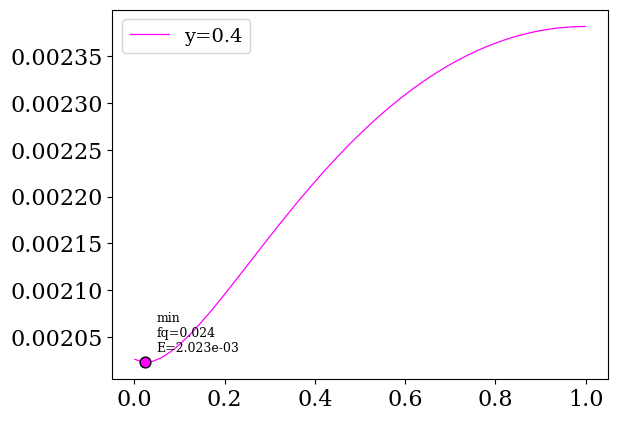

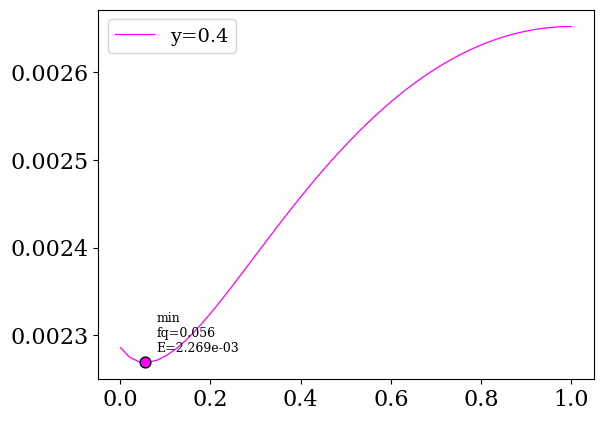

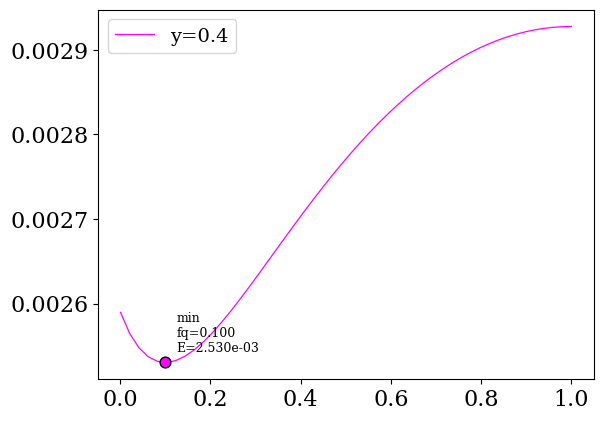

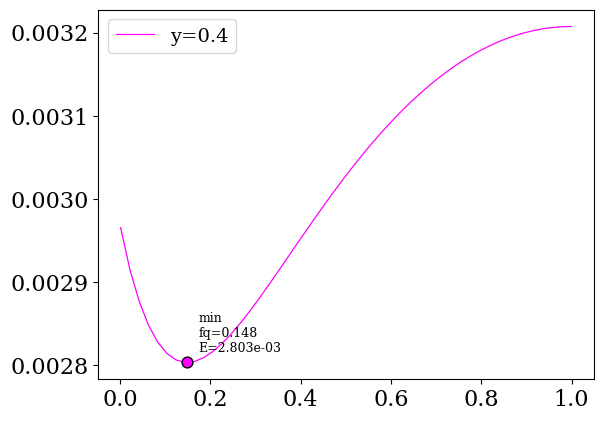

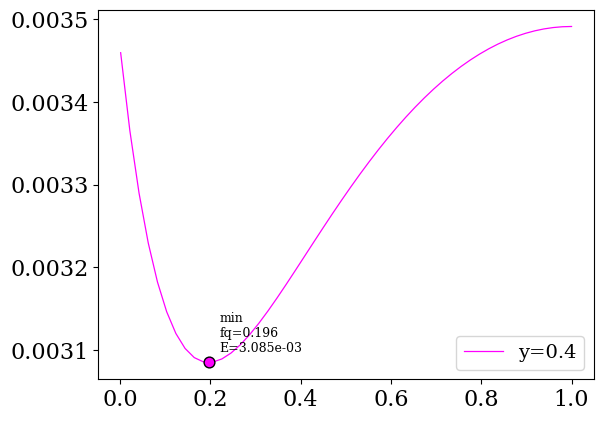

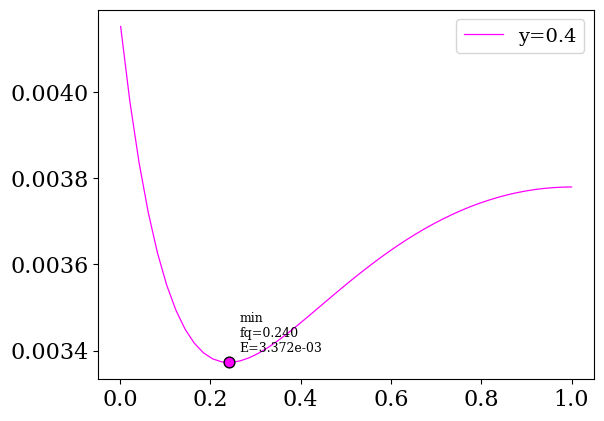

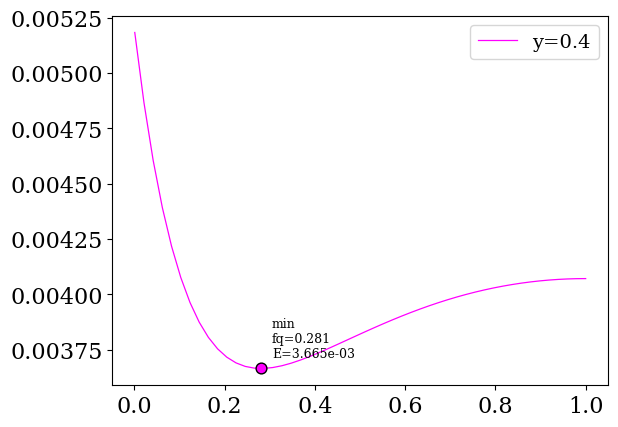

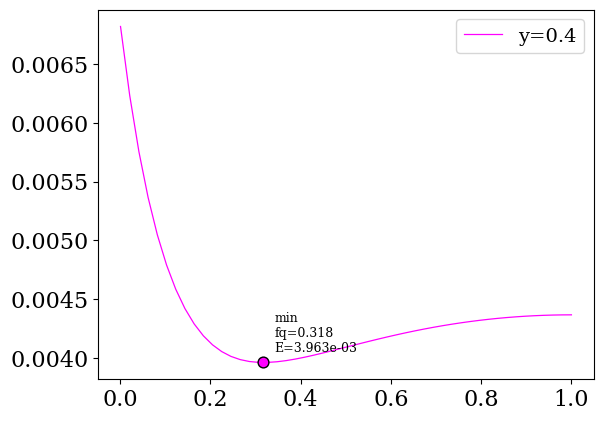

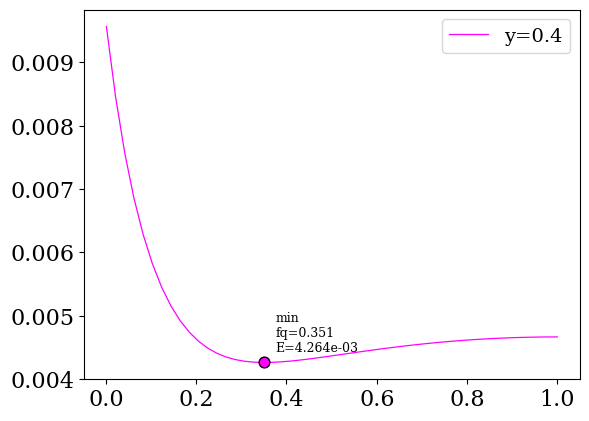

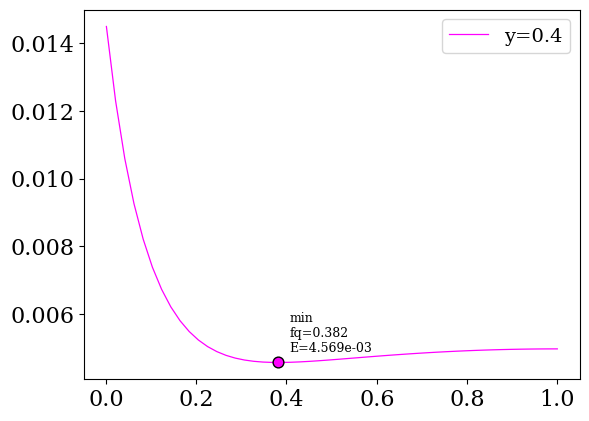

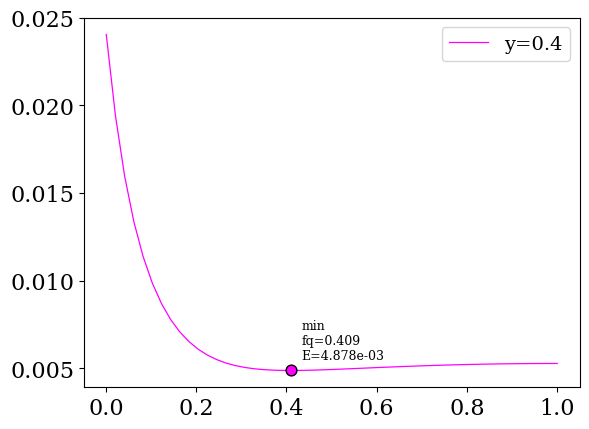

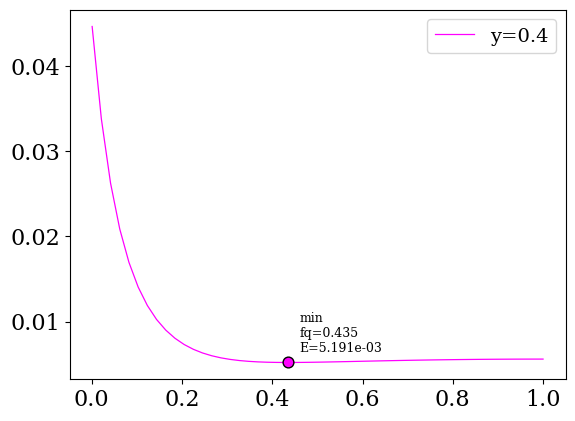

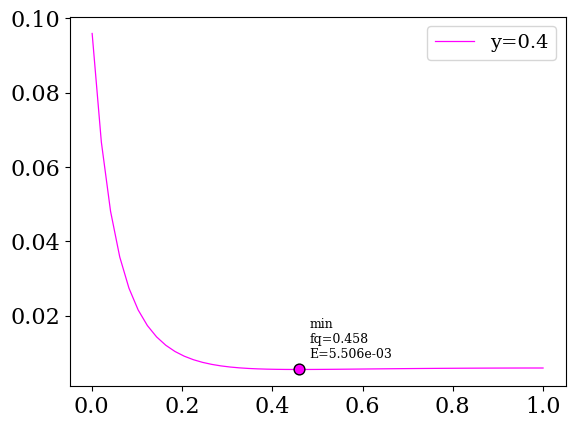

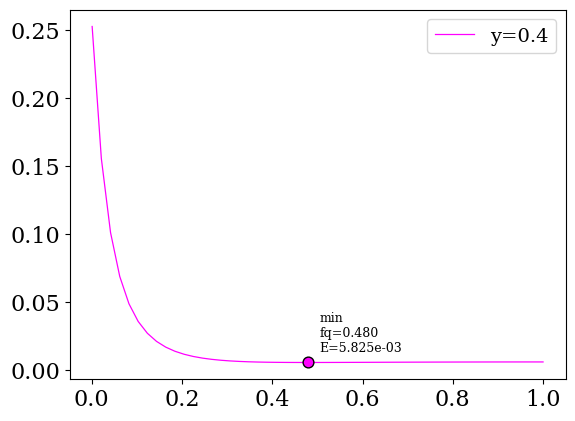

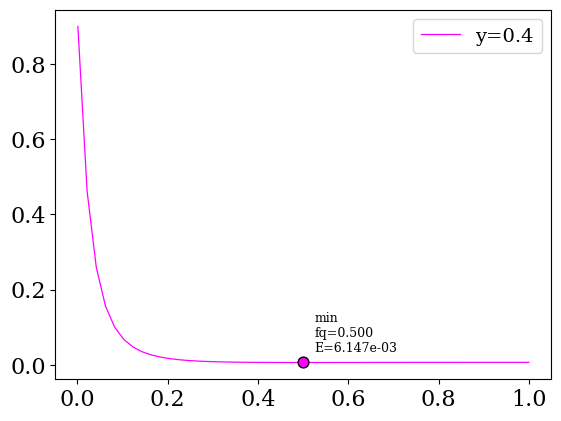

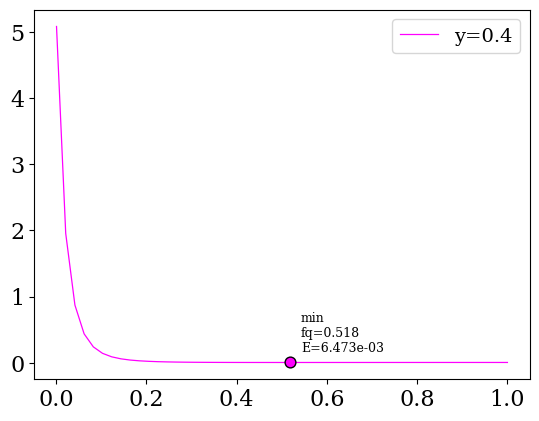

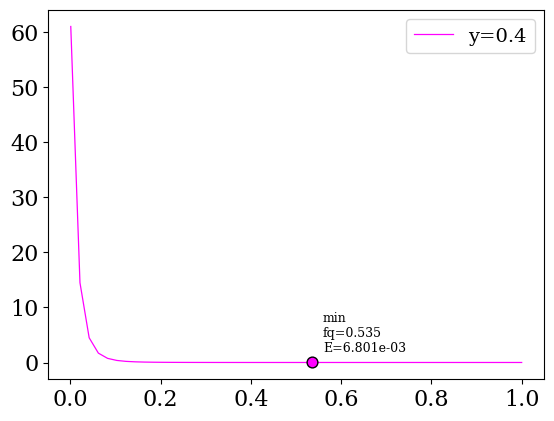

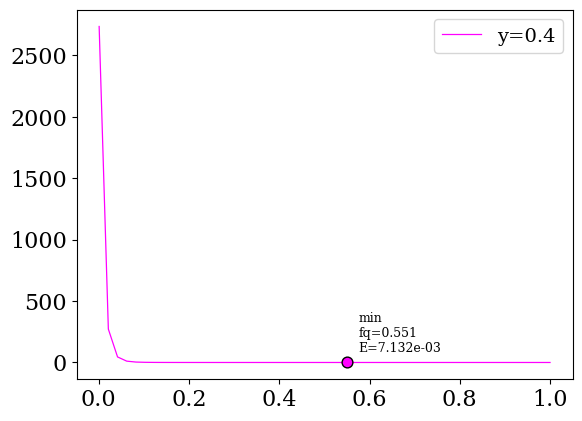

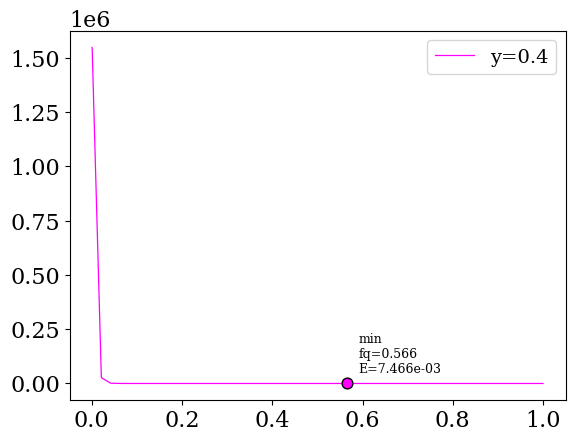

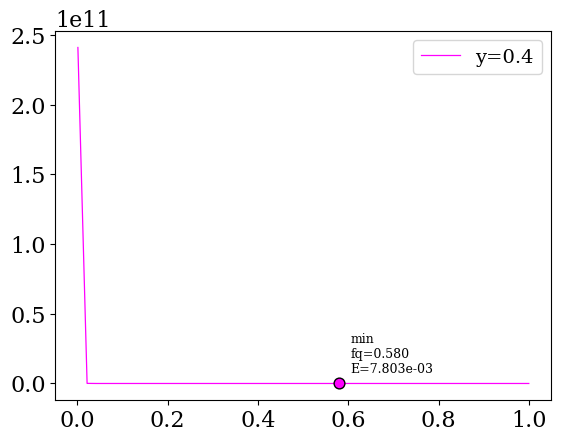

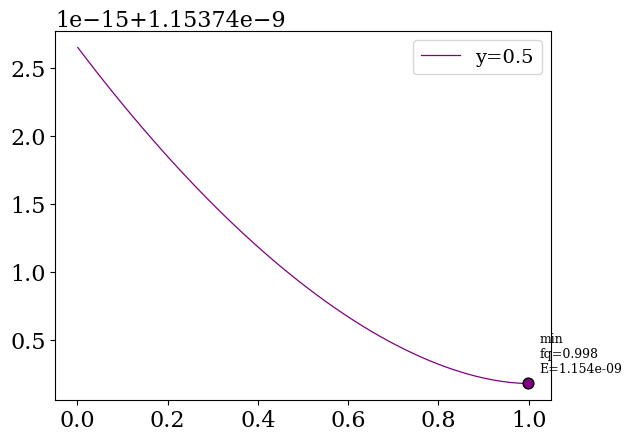

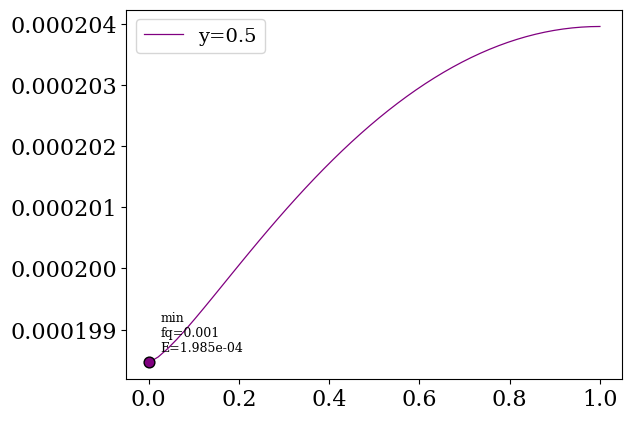

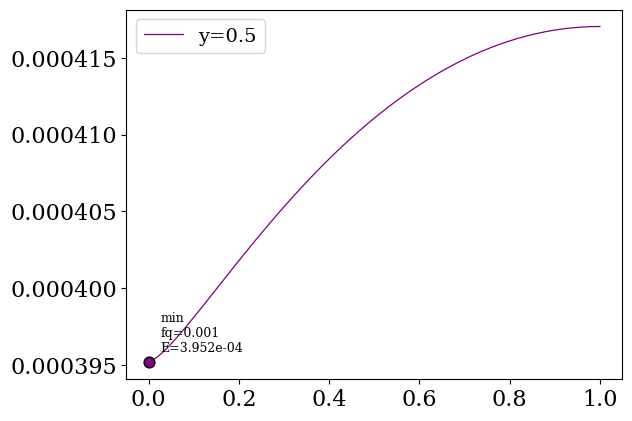

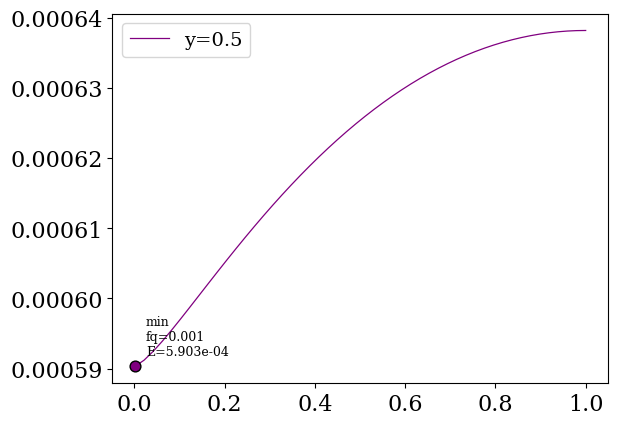

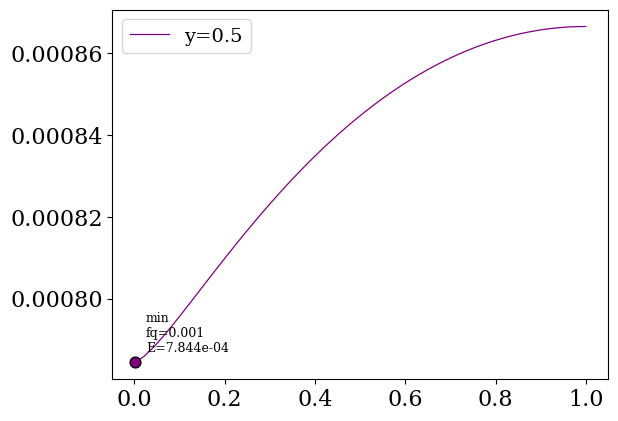

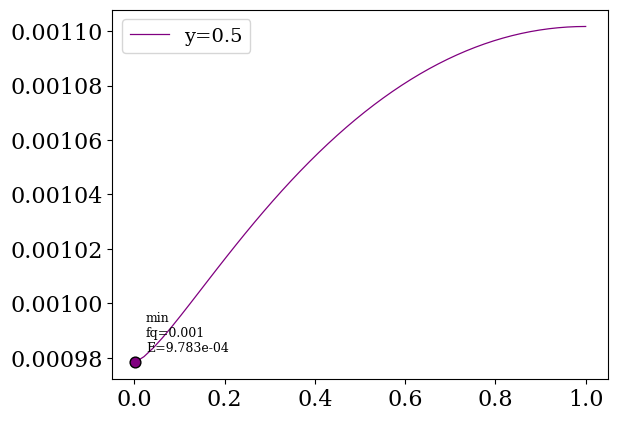

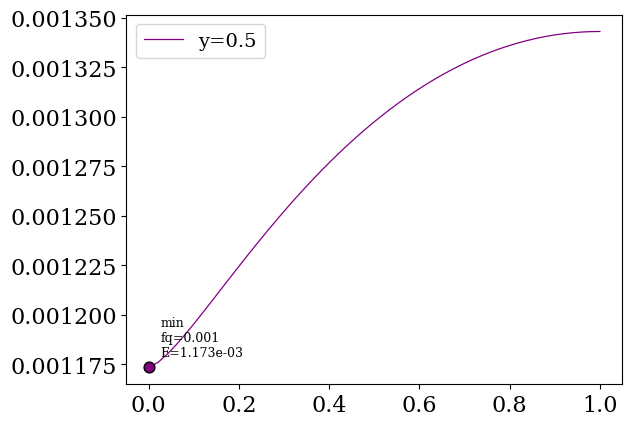

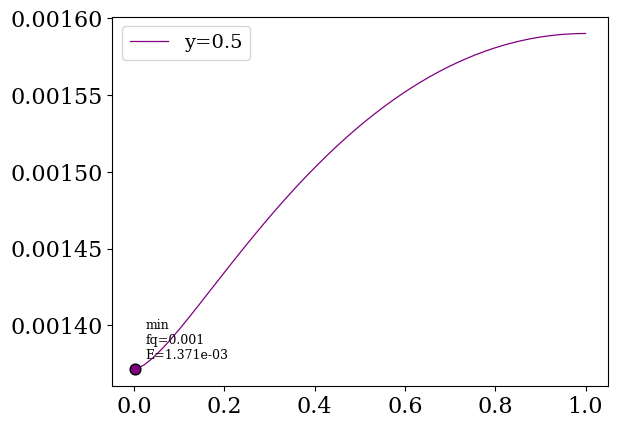

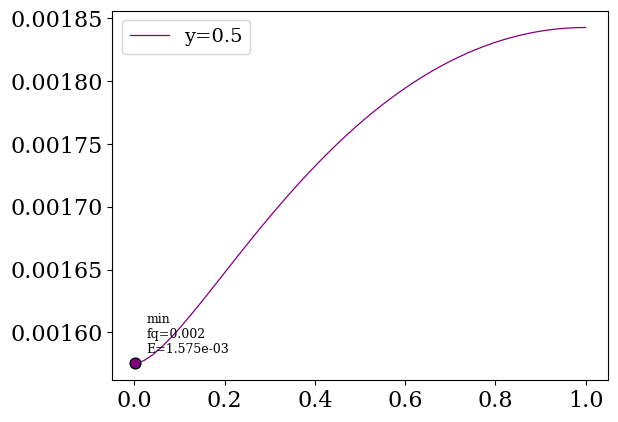

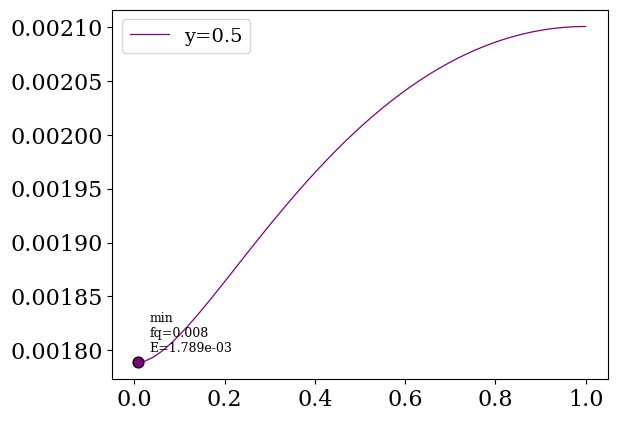

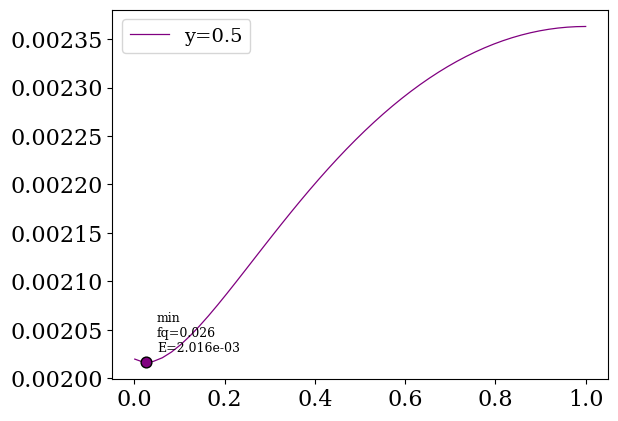

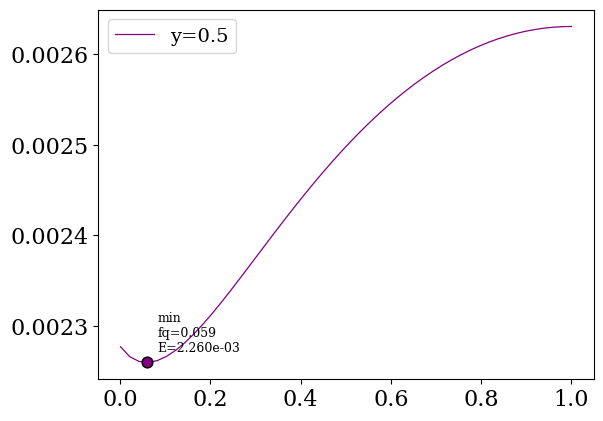

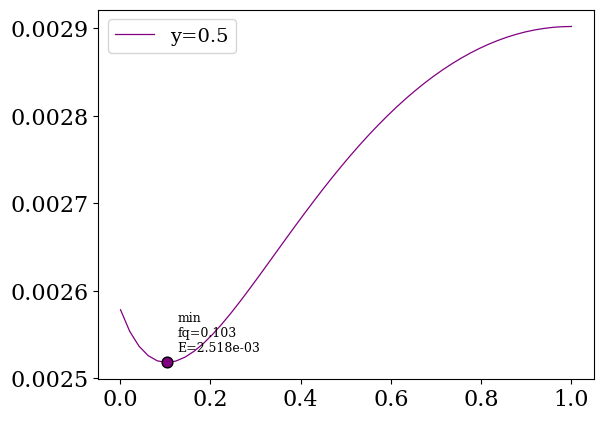

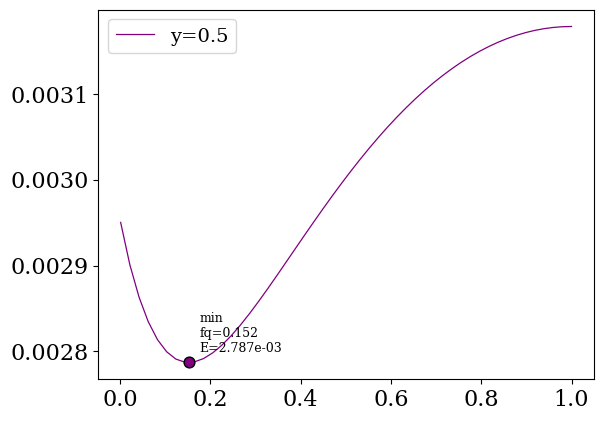

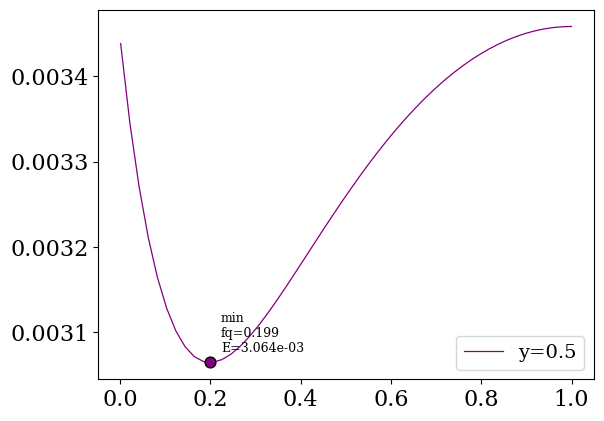

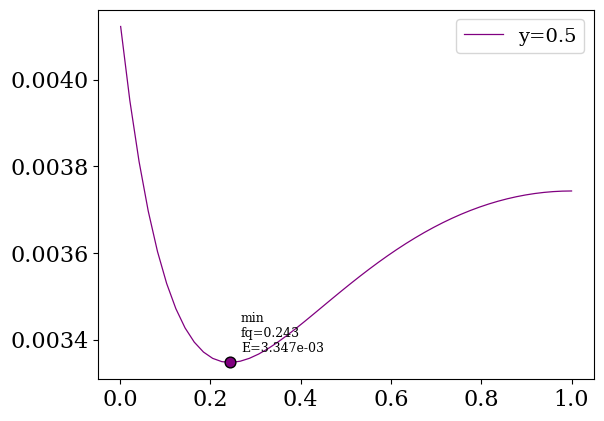

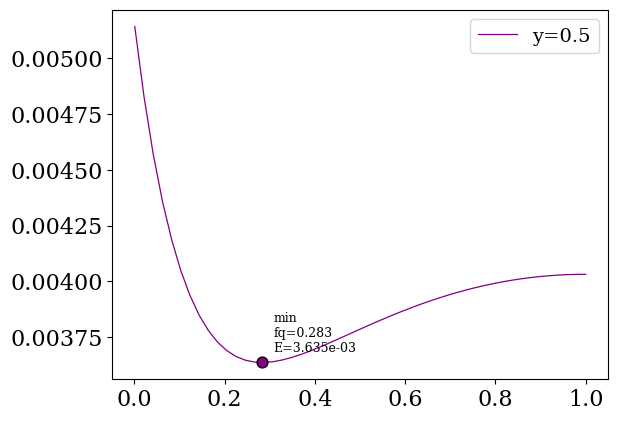

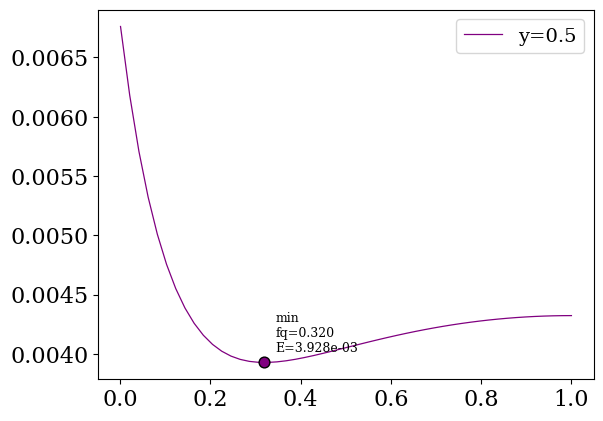

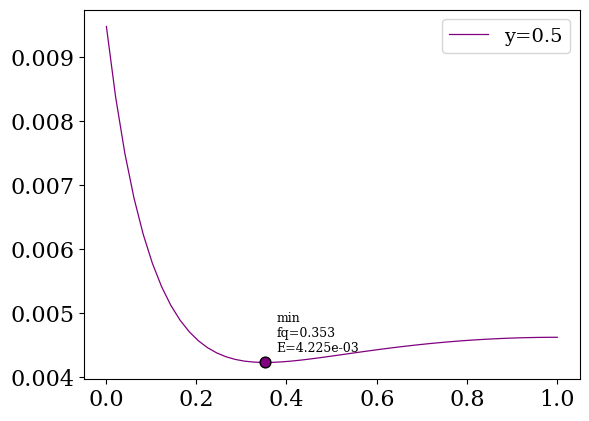

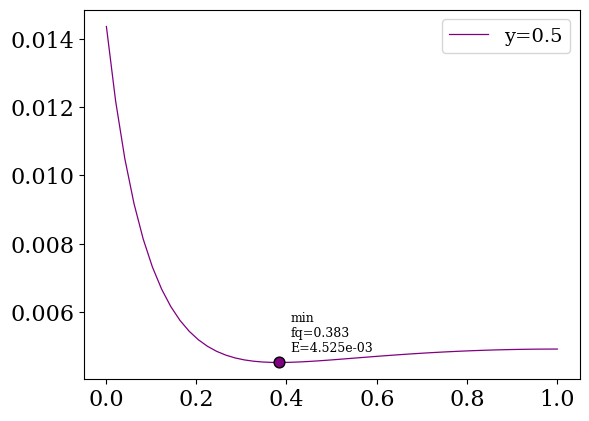

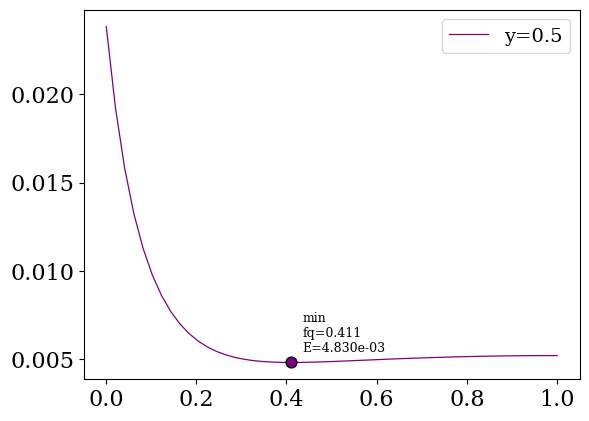

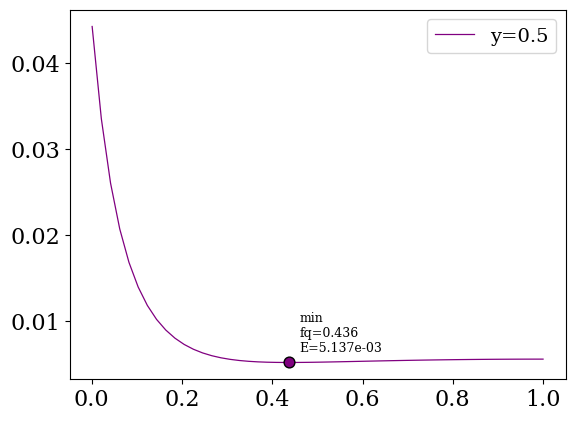

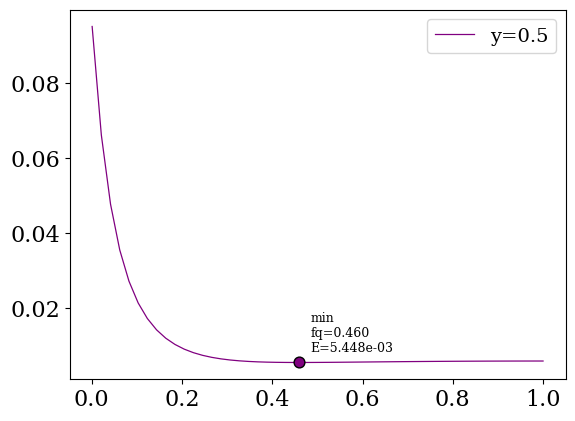

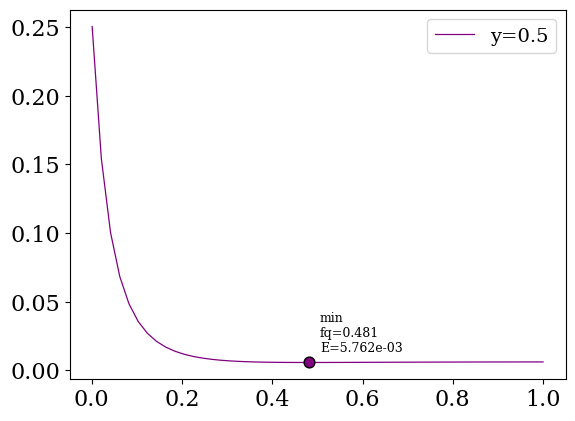

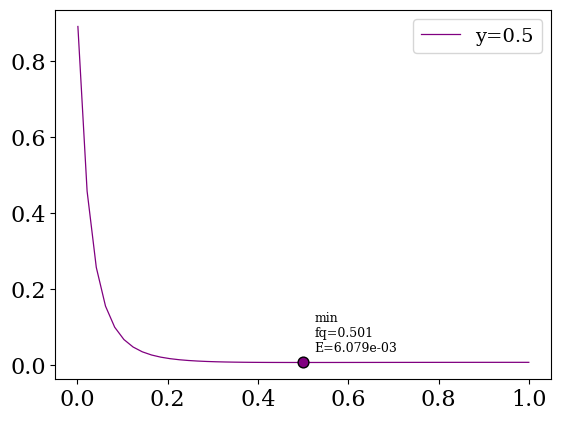

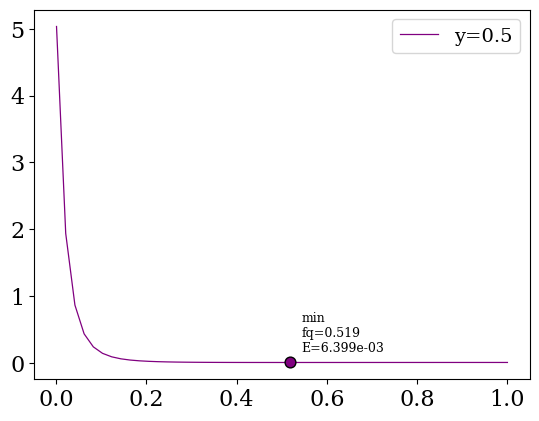

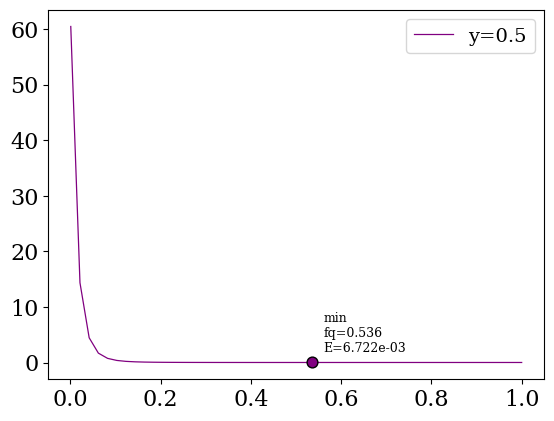

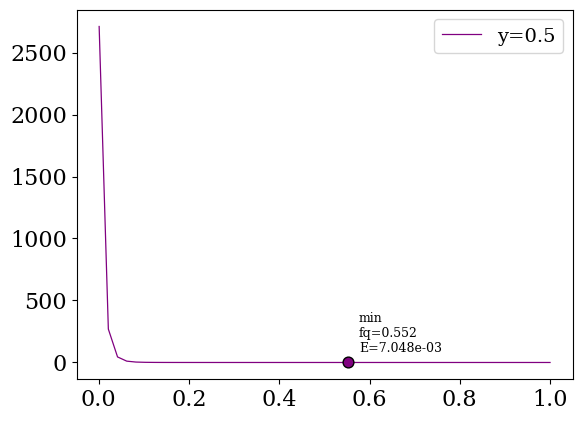

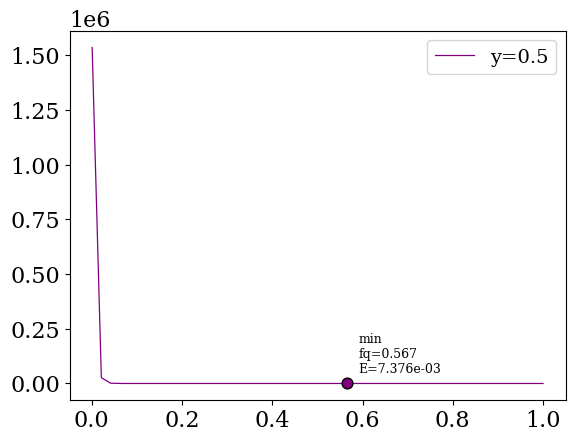

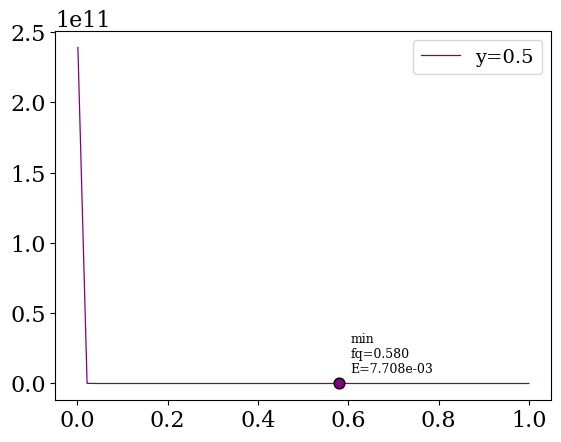

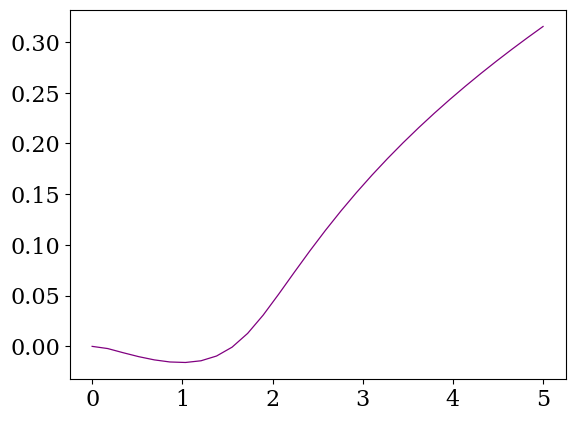

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.numerical_functions import *
# Properties for nucleons and quarks


g =2; mp = mn = 0.938 #GeV/c**2
Nc = 3; mu = md = mp/Nc; lam = 0.2 #GeV200;
rho0 = 1.23e-3  #GeV^3
rhob_list = np.linspace(1e-6, 5.0, 30) * rho0
y = 0.1; fq_min = 1e-3; fq_max = 1.0
fq_list = np.linspace(fq_min, fq_max, 50)
print(len(fq_list))


bn = bpn = an = apn = None

isos_repulsion = "eq"
model = 'cs'
def main(isos_repulsion,model):
    global bn, bpn, an, apn

    if model == 'cs':
        print('cs model')
        # -------------------- CS parameters 
        if isos_repulsion == "eq":   
            an  = 36.93 #36.9
            bn  = 579.17 #577.
            apn = 53.60#1.45 * an   
            bpn = 1.00 * bn   
            print(r'isospin-blind repulsion $b_n = b_{pn}$')
        elif isos_repulsion == "neq":   
            an  = 26.535 #26.6
            bn  =383.788#383.
            apn =63.999 #2.40 * an   
            bpn = 774.64 #2.01 * bn   
            print(r'isospin-dependent repulsion $b_n \neq b_{pn}$') 
    elif model == 'tvm':
        print('tvm model')
        # -------------------- TVM parameters


        if isos_repulsion == 'eq':
        # bpn = bn
            an = 37.33    #26.4
            bn = 560.08  #361
            apn = 53.72#1.43 * an
            bpn = 1.0 * bn
            print(r'isospin-blind repulsion $b_n = b_{pn}$')

        elif isos_repulsion == 'neq':
        # bpn neq bn
            an = 26.78#37.33    #26.4
            bn = 363.72 #560.08  #361
            apn = 64.67 #2.44 * an
            bpn = 756.4 #2.08 * bn
            print(r'isospin-dependent repulsion $b_n \neq b_{pn}$') 


    # ------------- help-functions 
    def integrate_simpson(f, a, b, n=1000):
        h = (b - a) / n
        s = f(a) + f(b)
        x = a
        for i in range(1, n):
            x += h
            s += (4.0 if (i % 2) == 1 else 2.0) * f(x)
        return s * (h / 3.0)

    # Ideal quarks u,d energy density

    def f1(q):
        return q * np.sqrt(lam**2 + q**2) * np.sqrt(mu**2 + q**2)
    def f2(q):
        return q * np.sqrt(lam**2 + q**2) * np.sqrt(md**2 + q**2)

    def euid(kbu, y, N=1000):
        k = g / (2 * np.pi**2)
        result = (1+y)/(2-y) * integrate_simpson(f1,0,kbu / Nc)#simpson(f, x=q)
        return Nc * k * result
    def edid(kbu, N=1000):
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f2,0,kbu / Nc)
        return Nc * k * result

    # Ideal proton, neutrons energy density

    def f3(k):
        return k**2 * np.sqrt(mn**2 + k**2)
    def f4(k):
        return k**2 * np.sqrt(mp**2 + k**2)
        
    def enid(kbu, kfn, N=1000):
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f3,kbu, kfn)
        return k * result
    def epid(kbu, kfp, N=1000): 
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f4,kbu, kfp)
        return k * result

    # Ideal quarks u,d baryon density

    def f5(q):
        return q * np.sqrt(lam**2 + q**2) 
    def f6(q):
        return q * np.sqrt(lam**2 + q**2) 

    def nuid(kbu, y, N=1000):
        k = g / (2 * np.pi**2)
        result = (1+y)/(2-y) * integrate_simpson(f5,0,kbu / Nc)#simpson(f, x=q)
        return Nc * k * result
    def ndid(kbu, N=1000):
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f6,0,kbu / Nc)
        return Nc * k * result
        
    # Ideal proton, neutrons baryon density

    def f7(k):
        return k**2 
    def f8(k):
        return k**2 
        
    def nnid(kbu, kfn, N=1000):
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f7,kbu, kfn)
        return k * result
    def npid(kbu, kfp, N=1000): 
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f7,kbu, kfp)
        return k * result

    def kbu_solver(rhob, fq, y):
        k = g / (2.0*np.pi**2)
        w = (3.0/(2.0 - y)) * k
        nq = rhob * fq
        inside = (3.0*nq/w + lam**3)**(2.0/3.0) - lam**2
        return Nc * np.sqrt(max(inside, 0.0))


    def f_tvm(x):
        return np.exp(-x - 0.5*x**2)

    def f_cs(x):
        out = np.full_like(x, np.nan, dtype=float)
        m = x < 4.0
        xm = x[m]
        out[m] = np.exp(-(3*xm)/(4 - xm) - (4*xm)/((4 - xm)**2))
        return out

    def kfp_solver_CS_TVM(rhob, fq, y, kbu, model="tvm"):
        global bpn, bn
        n_p = rhob*(1.0 - fq)*y
        n_n = rhob*(1.0 - fq)*(1.0 - y)
        x_p = (bn*n_p + bpn*n_n)

        f = f_tvm(x_p) if model=="tvm" else f_cs(x_p)
        if not np.isfinite(f) or f <= 0:
            return np.nan

        n_p_id = n_p / f
        val = kbu**3 + (6.0*np.pi**2/g)*n_p_id
        return np.cbrt(max(val, 0.0))

    def kfn_solver_CS_TVM(rhob, fq, y, kbu, model="tvm"):
        global bpn, bn
        n_p = rhob*(1.0 - fq)*y
        n_n = rhob*(1.0 - fq)*(1.0 - y)
        x_n = bpn*n_p + bn*n_n

        f = f_tvm(x_n) if model=="tvm" else f_cs(x_n)
        if not np.isfinite(f) or f <= 0:
            return np.nan

        n_n_id = n_n / f
        val = kbu**3 + (6.0*np.pi**2/g)*n_n_id
        return np.cbrt(max(val, 0.0))


    def xx_of_fq(
        fq,
        rhob,
        y,
        *,
        model,
        bn, bpn, an, apn,
        kbu_solver,
        kfp_solver_CS_TVM,
        kfn_solver_CS_TVM,
        euid, edid, enid, epid,
        f_tvm, f_cs,
    ):
        # --- solve momenta
        kbu = kbu_solver(rhob, fq, y)
        kfp = kfp_solver_CS_TVM(rhob, fq, y, kbu, model=model)
        kfn = kfn_solver_CS_TVM(rhob, fq, y, kbu, model=model)

        # --- single-particle energies
        eu = euid(kbu, y=y)
        ed = edid(kbu)
        en = enid(kbu, kfn)
        ep = epid(kbu, kfp)

        # --- densities
        n_p = rhob * (1.0 - fq) * y
        n_n = rhob * (1.0 - fq) * (1.0 - y)

        # --- x_p, x_n
        x_p = (bn * n_p + bpn * n_n)
        x_n = (bpn * n_p + bn * n_n)

        # original guard
        if model == "cs" and ((x_p >= 4.0) or (x_n >= 4.0)):
            return np.nan

        # --- f(x)
        fp = f_tvm(x_p) if model == "tvm" else f_cs(x_p)
        fn = f_tvm(x_n) if model == "tvm" else f_cs(x_n)

        if (not np.isfinite(fp)) or (not np.isfinite(fn)) or (fp <= 0) or (fn <= 0):
            return np.nan

        nuclear_int = fp * ep + fn * en - an * (n_p**2 + n_n**2) - 2.0 * apn * n_p * n_n
        return eu + ed + nuclear_int


    def xx_of_fq_list(fq_list, rhob, y, **kwargs):
        # returns a numpy array same length as fq_list
        return np.array([xx_of_fq(fq, rhob, y, **kwargs) for fq in fq_list], dtype=float)

    def energy_of_fq(fq):
        return xx_of_fq(
        fq, rhob, y,
        model=model,
        bn=bn, bpn=bpn, an=an, apn=apn,
        kbu_solver=kbu_solver,
        kfp_solver_CS_TVM=kfp_solver_CS_TVM,
        kfn_solver_CS_TVM=kfn_solver_CS_TVM,
        euid=euid, edid=edid, enid=enid, epid=epid,
        f_tvm=f_tvm, f_cs=f_cs,
    )
    
    # colors = ['black','red','yellow','green','blue']

    colors = ['blue', 'deepskyblue', 'cyan', 'springgreen', 'magenta', 'purple']

    y_list = [0.0,0.1, 0.2, 0.3, 0.4, 0.5]

    plt.figure()

    for iy, y in enumerate(y_list):
        energy_density_list = []   

        for rhob in rhob_list:
            # xx = []
            xx = xx_of_fq_list(
            fq_list, rhob, y,
            model=model,
            bn=bn, bpn=bpn, an=an, apn=apn,
            kbu_solver=kbu_solver,
            kfp_solver_CS_TVM=kfp_solver_CS_TVM,
            kfn_solver_CS_TVM=kfn_solver_CS_TVM,
            euid=euid, edid=edid, enid=enid, epid=epid,
            f_tvm=f_tvm, f_cs=f_cs,
        )
            fq_star = gss(energy_of_fq, fq_min, fq_max, tol=1e-7)
            E_star  = energy_of_fq(fq_star)
            energy_density_list.append(E_star)
            
            # print(E_star)
            plt.plot(fq_list, xx, color=colors[iy], label=f"y={y:.1f}", lw=0.9)
            plt.scatter([fq_star], [E_star], s=60, marker="o", color=colors[iy], edgecolors="k", zorder=5)
            plt.annotate(
                f"min\nfq={fq_star:.3f}\nE={E_star:.3e}",
                (fq_star, E_star),
                textcoords="offset points",
                xytext=(8, 8),
                ha="left",
                fontsize=9
            )

            plt.legend()
            plt.show()
            plt.close()


            # for fq in fq_list:

            #     kbu = kbu_solver(rhob, fq, y)
            #     kfp = kfp_solver_CS_TVM(rhob, fq, y, kbu,model = model)
            #     kfn = kfn_solver_CS_TVM(rhob, fq, y, kbu,model=model)

            #     eu = euid(kbu, y=y)
            #     ed = edid(kbu)
            #     en = enid(kbu, kfn)
            #     ep = epid(kbu, kfp)
                
            #     n_p = rhob * (1.0 - fq) * y
            #     n_n = rhob * (1.0 - fq) * (1.0 - y)

            #     x_p = (bn*n_p + bpn*n_n)
            #     x_n = (bpn*n_p + bn*n_n)
                
            #     # if (x_p >= 1/4) or (x_n >= 1/4):
            #     #     xx.append(np.nan)
            #     #     continue
                
            #     if model == "cs" and ((x_p >= 4.0) or (x_n >= 4.0)):
            #         xx.append(np.nan)
            #         continue
                
            #     fp = f_tvm(x_p) if model=="tvm" else f_cs(x_p)
            #     fn = f_tvm(x_n) if model=="tvm" else f_cs(x_n)
                
            #     if (not np.isfinite(fp)) or (not np.isfinite(fn)) or (fp <= 0) or (fn <= 0):
            #         xx.append(np.nan); continue

            #     nuclear_int = fp*ep + fn*en - an*(n_p**2 + n_n**2) - 2.0*apn*n_p*n_n


            #     xx.append(eu + ed + nuclear_int)
            # plt.plot(fq_list, xx, color=colors[iy], label=f"y={y:.1f}", lw=0.9)
            # plt.show()
            # plt.close()

        #     epsilon = np.asarray(xx, float)
        #     mask = np.isfinite(epsilon)
        #     eps_phys = epsilon[mask]

        #     if eps_phys.size == 0:
        #         energy_density_list.append(np.nan)
        #     else:
        #         energy_density_list.append(np.min(eps_phys))

        energy_density_arr = np.asarray(energy_density_list, float)
    plt.plot(
        rhob_list/rho0,
        energy_density_arr / rhob_list - mn,
        color=colors[iy],
        label=f"y={y:.1f}",lw=0.9
    )
    
plt.ylim(-0.05, 0.5)
plt.xlim(0, 5)
plt.xlabel(r"$\rho_B [\rho_0]$")
plt.ylabel(r"$\epsilon/\rho_B - m_n$")

# if isos_repulsion == 'eq':
#     plt.title(r'$b_{pn} = b_n$')  
# elif   isos_repulsion == 'neq':
#     plt.title(r'$b_{pn} \neq b_n$')  

# if model == 'tvm':
#     if isos_repulsion == 'eq':
#         plt.title(r' Trivirial model $b_{pn} = b_n$') 
#     elif   isos_repulsion == 'neq':
#         plt.title(r' Trivirial model $b_{pn} \neq b_n$') 

# elif model== 'cs':
#     if isos_repulsion == 'eq':
#         plt.title(r' Carnaghan Stirl model $b_{pn} = b_n$') 
#     elif   isos_repulsion == 'neq':
#         plt.title(r' Carnaghan Stirl  model $b_{pn} \neq b_n$') 

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'dejavuserif',
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 14,
})
plt.legend()

plt.tight_layout()
# if model == 'tvm':
#     if isos_repulsion == 'eq':
#         plt.savefig("./TVM_eq.png", dpi=90, bbox_inches="tight")
#         plt.savefig("./TVM_eq.pdf", bbox_inches="tight") 
#     elif   isos_repulsion == 'neq':
#         plt.savefig("./TVM_neq.png", dpi=90, bbox_inches="tight")
#         plt.savefig("./TVM_neq.pdf", bbox_inches="tight") 
# elif model== 'cs':
#     if isos_repulsion == 'eq':
#             plt.savefig("./cs_eq.png", dpi=90, bbox_inches="tight")
#             plt.savefig("./cs_eq.pdf", bbox_inches="tight") 
#     elif isos_repulsion == 'neq':
#         plt.savefig("./cs_neq.png", dpi=90, bbox_inches="tight")
#         plt.savefig("./cs_neq.pdf", bbox_inches="tight") 
plt.show()
plt.close()

# main('eq','tvm')
# main('neq','tvm')
main('eq','cs')
# main('neq','cs')

50
tvm model
isospin-blind repulsion $b_n = b_{pn}$


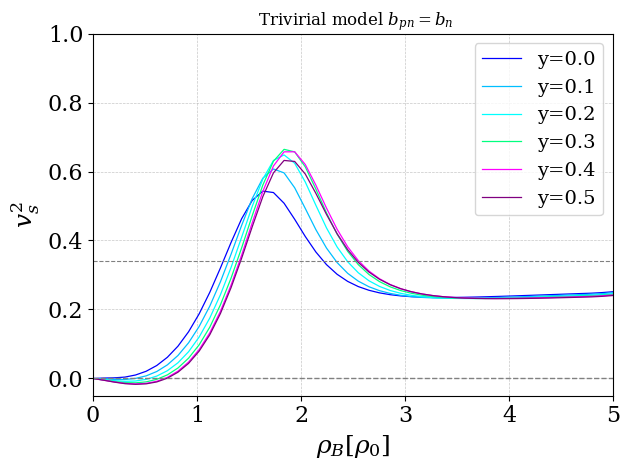

tvm model
isospin-dependent repulsion $b_n \neq b_{pn}$


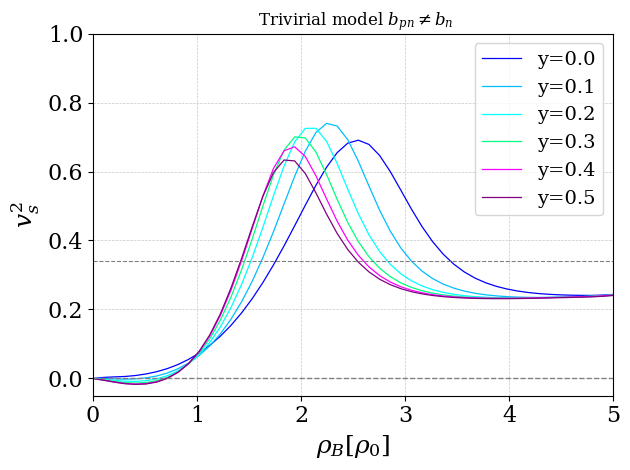

cs model
isospin-blind repulsion $b_n = b_{pn}$


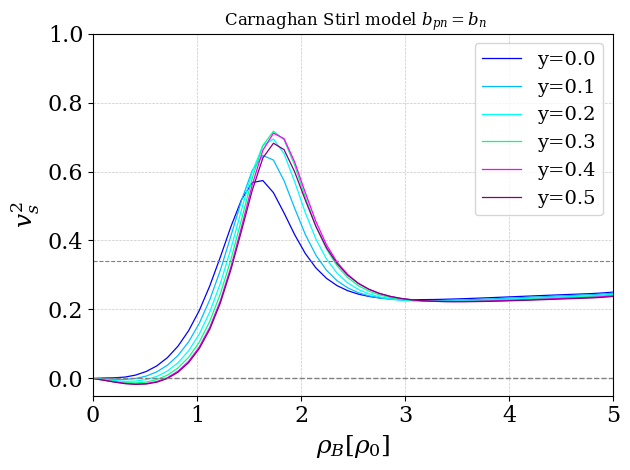

cs model
isospin-dependent repulsion $b_n \neq b_{pn}$


/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_66195/359515779.py:71: RuntimeWarning: overflow encountered in scalar multiply
  return s * (h / 3.0)


KeyboardInterrupt: 

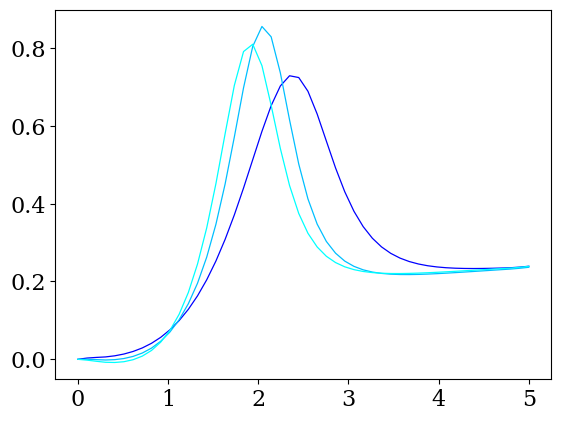

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from src.numerical_functions import *



# Properties for nucleons and quarks


g =2; mp = mn = 0.938 #GeV/c**2
Nc = 3; mu = md = mp/Nc; lam = 0.2 #GeV200;
rho0 = 1.23e-3  #GeV^3
rhob_list = np.linspace(1e-6, 5.0, 50) * rho0
y = 0.1; fq_min = 1e-3; fq_max = 1.0
fq_list = np.linspace(fq_min, fq_max, 50)
print(len(fq_list))


bn = bpn = an = apn = None

isos_repulsion = "eq"
model = 'cs'
def main(isos_repulsion,model):
    global bn, bpn, an, apn

    if model == 'cs':
        print('cs model')
        # -------------------- CS parameters
        if isos_repulsion == "eq":
            an  = 36.93 #36.9
            bn  = 579.17 #577.
            apn = 53.60#1.45 * an
            bpn = 1.00 * bn
            print(r'isospin-blind repulsion $b_n = b_{pn}$')
        elif isos_repulsion == "neq":
            an  = 26.535 #26.6
            bn  =383.788#383.
            apn =63.999 #2.40 * an
            bpn = 774.64 #2.01 * bn
            print(r'isospin-dependent repulsion $b_n \neq b_{pn}$')
    elif model == 'tvm':
        print('tvm model')
        # -------------------- TVM parameters


        if isos_repulsion == 'eq':
        # bpn = bn
            an = 37.33    #26.4
            bn = 560.08  #361
            apn = 53.72#1.43 * an
            bpn = 1.0 * bn
            print(r'isospin-blind repulsion $b_n = b_{pn}$')

        elif isos_repulsion == 'neq':
        # bpn neq bn
            an = 26.78#37.33    #26.4
            bn = 363.72 #560.08  #361
            apn = 64.67 #2.44 * an
            bpn = 756.4 #2.08 * bn
            print(r'isospin-dependent repulsion $b_n \neq b_{pn}$')


    # ------------- help-functions
    def integrate_simpson(f, a, b, n=1000):
        h = (b - a) / n
        s = f(a) + f(b)
        x = a
        for i in range(1, n):
            x += h
            s += (4.0 if (i % 2) == 1 else 2.0) * f(x)
        return s * (h / 3.0)

    # Ideal quarks u,d energy density

    def f1(q):
        return q * np.sqrt(lam**2 + q**2) * np.sqrt(mu**2 + q**2)
    def f2(q):
        return q * np.sqrt(lam**2 + q**2) * np.sqrt(md**2 + q**2)

    def euid(kbu, y, N=1000):
        k = g / (2 * np.pi**2)
        result = (1+y)/(2-y) * integrate_simpson(f1,0,kbu / Nc)#simpson(f, x=q)
        return Nc * k * result
    def edid(kbu, N=1000):
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f2,0,kbu / Nc)
        return Nc * k * result

    # Ideal proton, neutrons energy density

    def f3(k):
        return k**2 * np.sqrt(mn**2 + k**2)
    def f4(k):
        return k**2 * np.sqrt(mp**2 + k**2)

    def enid(kbu, kfn, N=1000):
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f3,kbu, kfn)
        return k * result
    def epid(kbu, kfp, N=1000):
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f4,kbu, kfp)
        return k * result

    # Ideal quarks u,d baryon density

    def f5(q):
        return q * np.sqrt(lam**2 + q**2)
    def f6(q):
        return q * np.sqrt(lam**2 + q**2)

    def nuid(kbu, y, N=1000):
        k = g / (2 * np.pi**2)
        result = (1+y)/(2-y) * integrate_simpson(f5,0,kbu / Nc)#simpson(f, x=q)
        return Nc * k * result
    def ndid(kbu, N=1000):
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f6,0,kbu / Nc)
        return Nc * k * result

    # Ideal proton, neutrons baryon density

    def f7(k):
        return k**2
    def f8(k):
        return k**2

    def nnid(kbu, kfn, N=1000):
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f7,kbu, kfn)
        return k * result
    def npid(kbu, kfp, N=1000):
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f7,kbu, kfp)
        return k * result

    def kbu_solver(rhob, fq, y):
        k = g / (2.0*np.pi**2)
        w = (3.0/(2.0 - y)) * k
        nq = rhob * fq
        inside = (3.0*nq/w + lam**3)**(2.0/3.0) - lam**2
        return Nc * np.sqrt(max(inside, 0.0))


    def f_tvm(x):
        return np.exp(-x - 0.5*x**2)

    def f_cs(x):
        out = np.full_like(x, np.nan, dtype=float)
        m = x < 4.0
        xm = x[m]
        out[m] = np.exp(-(3*xm)/(4 - xm) - (4*xm)/((4 - xm)**2))
        return out

    def kfp_solver_CS_TVM(rhob, fq, y, kbu, model="tvm"):
        global bpn, bn
        n_p = rhob*(1.0 - fq)*y
        n_n = rhob*(1.0 - fq)*(1.0 - y)
        x_p = (bn*n_p + bpn*n_n)

        f = f_tvm(x_p) if model=="tvm" else f_cs(x_p)
        if not np.isfinite(f) or f <= 0:
            return np.nan

        n_p_id = n_p / f
        val = kbu**3 + (6.0*np.pi**2/g)*n_p_id
        return np.cbrt(max(val, 0.0))

    def kfn_solver_CS_TVM(rhob, fq, y, kbu, model="tvm"):
        global bpn, bn
        n_p = rhob*(1.0 - fq)*y
        n_n = rhob*(1.0 - fq)*(1.0 - y)
        x_n = bpn*n_p + bn*n_n

        f = f_tvm(x_n) if model=="tvm" else f_cs(x_n)
        if not np.isfinite(f) or f <= 0:
            return np.nan

        n_n_id = n_n / f
        val = kbu**3 + (6.0*np.pi**2/g)*n_n_id
        return np.cbrt(max(val, 0.0))


    def xx_of_fq(
        fq,
        rhob,
        y,
        *,
        model,
        bn, bpn, an, apn,
        kbu_solver,
        kfp_solver_CS_TVM,
        kfn_solver_CS_TVM,
        euid, edid, enid, epid,
        f_tvm, f_cs,
    ):
        # --- solve momenta
        kbu = kbu_solver(rhob, fq, y)
        kfp = kfp_solver_CS_TVM(rhob, fq, y, kbu, model=model)
        kfn = kfn_solver_CS_TVM(rhob, fq, y, kbu, model=model)

        # --- single-particle energies
        eu = euid(kbu, y=y)
        ed = edid(kbu)
        en = enid(kbu, kfn)
        ep = epid(kbu, kfp)

        # --- densities
        n_p = rhob * (1.0 - fq) * y
        n_n = rhob * (1.0 - fq) * (1.0 - y)

        # --- x_p, x_n
        x_p = (bn * n_p + bpn * n_n)
        x_n = (bpn * n_p + bn * n_n)

        # original guard
        if model == "cs" and ((x_p >= 4.0) or (x_n >= 4.0)):
            return np.nan

        # --- f(x)
        fp = f_tvm(x_p) if model == "tvm" else f_cs(x_p)
        fn = f_tvm(x_n) if model == "tvm" else f_cs(x_n)

        if (not np.isfinite(fp)) or (not np.isfinite(fn)) or (fp <= 0) or (fn <= 0):
            return np.nan

        nuclear_int = fp * ep + fn * en - an*(n_p**2 + n_n**2) - 2.0*apn*n_p*n_n
        return eu + ed + nuclear_int


    def xx_of_fq_list(fq_list, rhob, y, **kwargs):
        # returns a numpy array same length as fq_list
        return np.array([xx_of_fq(fq, rhob, y, **kwargs) for fq in fq_list], dtype=float)

    def energy_of_fq(fq):
        return xx_of_fq(
        fq, rhob, y,
        model=model,
        bn=bn, bpn=bpn, an=an, apn=apn,
        kbu_solver=kbu_solver,
        kfp_solver_CS_TVM=kfp_solver_CS_TVM,
        kfn_solver_CS_TVM=kfn_solver_CS_TVM,
        euid=euid, edid=edid, enid=enid, epid=epid,
        f_tvm=f_tvm, f_cs=f_cs,
    )

    # colors = ['black','red','yellow','green','blue']

    colors = ['blue', 'deepskyblue', 'cyan', 'springgreen', 'magenta', 'purple']

    y_list = [0.0,0.1, 0.2, 0.3, 0.4, 0.5]

    plt.figure()

    for iy, y in enumerate(y_list):
        energy_density_list = []

        for rhob in rhob_list:
            # xx = []
            xx = xx_of_fq_list(
            fq_list, rhob, y,
            model=model,
            bn=bn, bpn=bpn, an=an, apn=apn,
            kbu_solver=kbu_solver,
            kfp_solver_CS_TVM=kfp_solver_CS_TVM,
            kfn_solver_CS_TVM=kfn_solver_CS_TVM,
            euid=euid, edid=edid, enid=enid, epid=epid,
            f_tvm=f_tvm, f_cs=f_cs,
        )
            fq_star = gss(energy_of_fq, fq_min, fq_max, tol=1e-7)
            E_star  = energy_of_fq(fq_star)
            energy_density_list.append(E_star)

            # print(E_star)
            # fig_fq = plt.figure()
            # plt.plot(fq_list, xx, color=colors[iy], label=f"y={y:.1f}", lw=0.9)
            # plt.scatter([fq_star], [E_star], s=60, marker="o", color=colors[iy], edgecolors="k", zorder=5)
            # plt.annotate(
            #     f"min\nfq={fq_star:.3f}\nE={E_star:.3e}",
            #     (fq_star, E_star),
            #     textcoords="offset points",
            #     xytext=(8, 8),
            #     ha="left",
            #     fontsize=9
            # )

            # plt.legend()
            # plt.show()
            # plt.close(fig_fq)

        energy_density_arr = np.asarray(energy_density_list, float)
        # plt.plot(
        #     rhob_list/rho0,
        #     energy_density_arr / rhob_list - mn,
        #     color=colors[iy],
        #     label=f"y={y:.1f}",lw=0.9
        # )
        # mu_b = derivative(rhob_list, energy_density_arr)
        # mu_bb = derivative(rhob_list, mu_b)
        E = np.array(energy_density_arr)

        mu_b = np.gradient(E, rhob_list, edge_order=2)
        mu_bb = np.gradient(mu_b, rhob_list, edge_order=2)
        vs2 = rhob_list/mu_b * mu_bb
      
        plt.plot(
            rhob_list/rho0,
            vs2,
            color=colors[iy],
            label=f"y={y:.1f}",lw=0.9
        )
    plt.rcParams.update({
        'font.family': 'serif',
        'mathtext.fontset': 'dejavuserif',
        'axes.labelsize': 18,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 14,
    })
    plt.ylim(-0.05, 1.0)
    plt.xlim(0, 5)
    plt.xlabel(r"$\rho_B [\rho_0]$")
    plt.ylabel(r"$v_s^2$")
    plt.axhline(y=0.34, color='gray', linestyle='--', linewidth=0.8)
    if isos_repulsion == 'eq':
        plt.title(r'$b_{pn} = b_n$')
    elif   isos_repulsion == 'neq':
        plt.title(r'$b_{pn} \neq b_{pn}$')

    if model == 'tvm':
        if isos_repulsion == 'eq':
            plt.title(r' Trivirial model $b_{pn} = b_n$')
        elif   isos_repulsion == 'neq':
            plt.title(r' Trivirial model $b_{pn} \neq b_n$')

    elif model== 'cs':
        if isos_repulsion == 'eq':
            plt.title(r' Carnaghan Stirl model $b_{pn} = b_n$')
        elif   isos_repulsion == 'neq':
            plt.title(r' Carnaghan Stirl  model $b_{pn} \neq b_n$')

    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

    plt.legend()

    plt.tight_layout()
    # if model == 'tvm':
    #     if isos_repulsion == 'eq':
    #         plt.savefig("./vs2TVM_eq.png", dpi=90, bbox_inches="tight")
    #         plt.savefig("./vs2TVM_eq.pdf", bbox_inches="tight")
    #     elif   isos_repulsion == 'neq':
    #         plt.savefig("./vs2TVM_neq.png", dpi=90, bbox_inches="tight")
    #         plt.savefig("./vs2TVM_neq.pdf", bbox_inches="tight")
    # elif model== 'cs':
    #     if isos_repulsion == 'eq':
    #             plt.savefig("./vs2cs_eq.png", dpi=90, bbox_inches="tight")
    #             plt.savefig("./vs2cs_eq.pdf", bbox_inches="tight")
    #     elif isos_repulsion == 'neq':
    #         plt.savefig("./vs2cs_neq.png", dpi=90, bbox_inches="tight")
    #         plt.savefig("./vs2cs_neq.pdf", bbox_inches="tight")
    plt.show()
    plt.close()

main('eq','tvm')
main('neq','tvm')
main('eq','cs')
main('neq','cs')


In [ ]:
# leptons
me  = 0.000511   # GeV
mmu = 0.10566    # GeV

# Properties for nucleons and quarks


g =2; mp = mn = 0.938 #GeV/c**2
Nc = 3; mu = md = mp/Nc; lam = 0.2 #GeV200;
rho0 = 1.23e-3  #GeV^3
rhob_list = np.linspace(1e-6, 5.0, 500) * rho0
y = 0.1; fq_min = 1e-3; fq_max = 1.0
fq_list = np.linspace(fq_min, fq_max, 500)
print(len(fq_list))


bn = bpn = an = apn = None

def lepton_kf_from_mu(mu_l, m_l):
    x = mu_l**2 - m_l**2
    return np.sqrt(max(x, 0.0))

def lepton_density_from_mu(mu_l, m_l):
    # rho_l = 2 kF^3 / (6 pi^2) = kF^3 / (3 pi^2)
    if mu_l <= m_l:
        return 0.0
    kf = lepton_kf_from_mu(mu_l, m_l)
    return kf**3 / (3.0 * np.pi**2)

def lepton_energy_density_from_mu(mu_l, m_l, nint=1000):
    # epsilon_l = 2/(2 pi^2) \int_0^{kF} k^2 sqrt(k^2 + m^2) dk
    if mu_l <= m_l:
        return 0.0
    kf = lepton_kf_from_mu(mu_l, m_l)

    def f(k):
        return k**2 * np.sqrt(k**2 + m_l**2)

    return (1.0 / np.pi**2) * integrate_simpson(f, 0.0, kf, n=nint)

500


In [ ]:
def energy_hq_of_fq_y(
    fq, rhob, y,
    *,
    model,
    bn, bpn, an, apn,
    kbu_solver,
    kfp_solver_CS_TVM,
    kfn_solver_CS_TVM,
    euid, edid, enid, epid,
    f_tvm, f_cs,
):
    kbu = kbu_solver(rhob, fq, y)
    kfp = kfp_solver_CS_TVM(rhob, fq, y, kbu, model=model)
    kfn = kfn_solver_CS_TVM(rhob, fq, y, kbu, model=model)

    eu = euid(kbu, y=y)
    ed = edid(kbu)
    en = enid(kbu, kfn)
    ep = epid(kbu, kfp)

    n_p = rhob * (1.0 - fq) * y
    n_n = rhob * (1.0 - fq) * (1.0 - y)

    x_p = bn * n_p + bpn * n_n
    x_n = bpn * n_p + bn * n_n

    if model == "cs" and ((x_p >= 4.0) or (x_n >= 4.0)):
        return np.nan

    fp = f_tvm(x_p) if model == "tvm" else f_cs(x_p)
    fn = f_tvm(x_n) if model == "tvm" else f_cs(x_n)

    if (not np.isfinite(fp)) or (not np.isfinite(fn)) or (fp <= 0) or (fn <= 0):
        return np.nan

    nuclear_int = fp * ep + fn * en - an * (n_p**2 + n_n**2) - 2.0 * apn * n_p * n_n
    return eu + ed + nuclear_int

isospin-blind repulsion $b_n = b_{pn}$


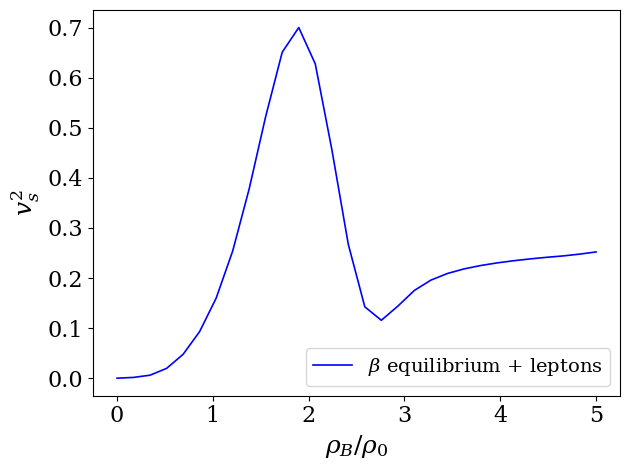

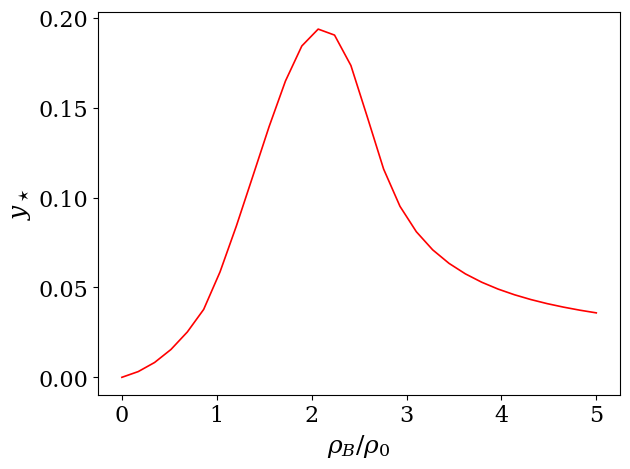

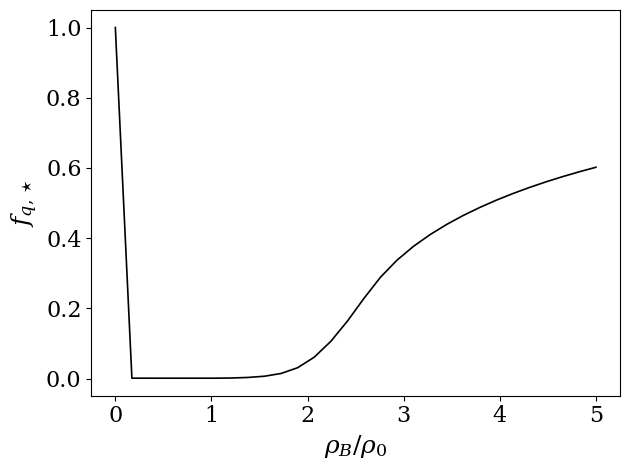

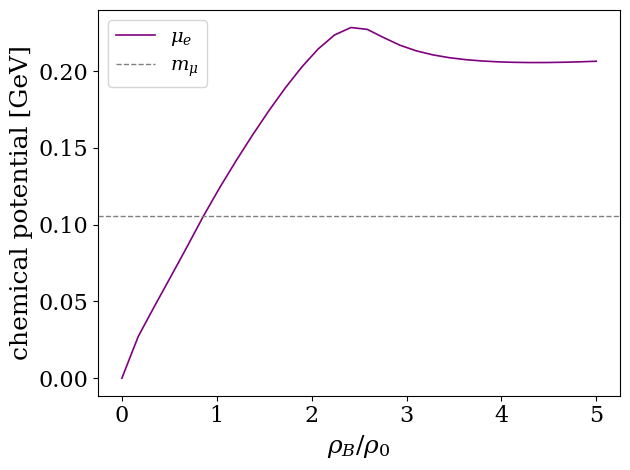

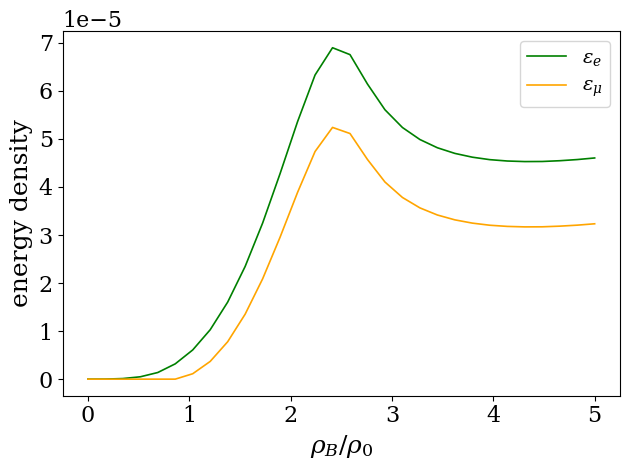

rhob=1.230000e-09  fq*=1.000000  y*=0.000001  mu_e=-0.000000  E=1.153740e-09
rhob=2.120702e-04  fq*=0.001010  y*=0.003185  mu_e=0.027167  E=2.000576e-04
rhob=4.241391e-04  fq*=0.001000  y*=0.008249  mu_e=0.046999  E=4.003721e-04
rhob=6.362080e-04  fq*=0.001000  y*=0.015480  mu_e=0.066358  E=6.011496e-04
rhob=8.482769e-04  fq*=0.001000  y*=0.025203  mu_e=0.085921  E=8.031544e-04
rhob=1.060346e-03  fq*=0.001000  y*=0.037756  mu_e=0.105894  E=1.007508e-03
rhob=1.272415e-03  fq*=0.001000  y*=0.058619  mu_e=0.124466  E=1.215631e-03
rhob=1.484484e-03  fq*=0.001535  y*=0.084183  mu_e=0.141945  E=1.429236e-03
rhob=1.696553e-03  fq*=0.003094  y*=0.111719  mu_e=0.158620  E=1.650581e-03
rhob=1.908622e-03  fq*=0.006595  y*=0.139423  mu_e=0.174446  E=1.882524e-03
rhob=2.120690e-03  fq*=0.014428  y*=0.164797  mu_e=0.189239  E=2.128404e-03
rhob=2.332759e-03  fq*=0.030828  y*=0.184279  mu_e=0.202737  E=2.391336e-03
rhob=2.544828e-03  fq*=0.060846  y*=0.193667  mu_e=0.214479  E=2.672488e-03
rhob=2.7568

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Full code with leptons + beta equilibrium + charge neutrality
# ============================================================
model = 'tvm'          # or 'cs'
isos_repulsion = 'eq'  # or 'neq'
# ----------------------------
# physical/constants
# ----------------------------
Nc = 3.0
g = 2.0

# masses in GeV
mp = 0.9382720813
mn = 0.9395654133
me = 0.000511
mmu = 0.10566

# keep your quark masses / lambda exactly as in your code
# example:
# mu = ...
# md = ...
# lam = ...

# keep your rho0, rhob_list, fq_list, fq_min, fq_max, model, isos_repulsion
# exactly as in your code


# ----------------------------
# interaction parameters
# ----------------------------
if isos_repulsion == 'eq':
    an = 37.33
    bn = 560.08
    apn = 53.72
    bpn = 1.0 * bn
    print(r'isospin-blind repulsion $b_n = b_{pn}$')

elif isos_repulsion == 'neq':
    an = 26.78
    bn = 363.72
    apn = 64.67
    bpn = 756.4
    print(r'isospin-dependent repulsion $b_n \neq b_{pn}$')


# ----------------------------
# helper functions
# ----------------------------
def integrate_simpson(f, a, b, n=1000):
    if not np.isfinite(a) or not np.isfinite(b):
        return np.nan
    if b < a:
        return 0.0
    if abs(b - a) < 1e-14:
        return 0.0
    if n % 2 == 1:
        n += 1
    h = (b - a) / n
    s = f(a) + f(b)
    x = a
    for i in range(1, n):
        x += h
        s += (4.0 if (i % 2) == 1 else 2.0) * f(x)
    return s * (h / 3.0)


def gss(f, a, b, tol=1e-7, max_iter=500):
    gr = (np.sqrt(5.0) + 1.0) / 2.0
    c = b - (b - a) / gr
    d = a + (b - a) / gr
    fc = f(c)
    fd = f(d)

    for _ in range(max_iter):
        if abs(b - a) < tol:
            break

        if (not np.isfinite(fc)) and (not np.isfinite(fd)):
            c = b - (b - a) / gr
            d = a + (b - a) / gr
            fc = f(c)
            fd = f(d)
            continue

        if not np.isfinite(fc):
            a = c
            c = d
            fc = fd
            d = a + (b - a) / gr
            fd = f(d)
            continue

        if not np.isfinite(fd):
            b = d
            d = c
            fd = fc
            c = b - (b - a) / gr
            fc = f(c)
            continue

        if fc < fd:
            b = d
            d = c
            fd = fc
            c = b - (b - a) / gr
            fc = f(c)
        else:
            a = c
            c = d
            fc = fd
            d = a + (b - a) / gr
            fd = f(d)

    return 0.5 * (a + b)


# ----------------------------
# ideal quark energy densities
# ----------------------------
def f1(q):
    return q * np.sqrt(lam**2 + q**2) * np.sqrt(mu**2 + q**2)

def f2(q):
    return q * np.sqrt(lam**2 + q**2) * np.sqrt(md**2 + q**2)

def euid(kbu, y, N=1000):
    k = g / (2.0 * np.pi**2)
    result = (1.0 + y) / (2.0 - y) * integrate_simpson(f1, 0.0, kbu / Nc, n=N)
    return Nc * k * result

def edid(kbu, N=1000):
    k = g / (2.0 * np.pi**2)
    result = integrate_simpson(f2, 0.0, kbu / Nc, n=N)
    return Nc * k * result


# ----------------------------
# ideal nucleon energy densities
# ----------------------------
def f3(k):
    return k**2 * np.sqrt(mn**2 + k**2)

def f4(k):
    return k**2 * np.sqrt(mp**2 + k**2)

def enid(kbu, kfn, N=1000):
    k = g / (2.0 * np.pi**2)
    result = integrate_simpson(f3, kbu, kfn, n=N)
    return k * result

def epid(kbu, kfp, N=1000):
    k = g / (2.0 * np.pi**2)
    result = integrate_simpson(f4, kbu, kfp, n=N)
    return k * result


# ----------------------------
# ideal quark baryon densities
# ----------------------------
def f5(q):
    return q * np.sqrt(lam**2 + q**2)

def f6(q):
    return q * np.sqrt(lam**2 + q**2)

def nuid(kbu, y, N=1000):
    k = g / (2.0 * np.pi**2)
    result = (1.0 + y) / (2.0 - y) * integrate_simpson(f5, 0.0, kbu / Nc, n=N)
    return Nc * k * result

def ndid(kbu, N=1000):
    k = g / (2.0 * np.pi**2)
    result = integrate_simpson(f6, 0.0, kbu / Nc, n=N)
    return Nc * k * result


# ----------------------------
# ideal nucleon baryon densities
# ----------------------------
def f7(k):
    return k**2

def nnid(kbu, kfn, N=1000):
    k = g / (2.0 * np.pi**2)
    result = integrate_simpson(f7, kbu, kfn, n=N)
    return k * result

def npid(kbu, kfp, N=1000):
    k = g / (2.0 * np.pi**2)
    result = integrate_simpson(f7, kbu, kfp, n=N)
    return k * result


# ----------------------------
# excluded-volume functions
# ----------------------------
def f_tvm(x):
    return np.exp(-x - 0.5 * x**2)

def f_cs(x):
    if x >= 4.0:
        return np.nan
    return np.exp(-(4.0 - 3.0 * x) * x / (1.0 - x)**2)


# ----------------------------
# solvers for momenta
# ----------------------------
def kbu_solver(rhob, fq, y):
    k = g / (2.0 * np.pi**2)
    w = (3.0 / (2.0 - y)) * k
    nq = rhob * fq
    inside = (3.0 * nq / w + lam**3)**(2.0 / 3.0) - lam**2
    return Nc * np.sqrt(max(inside, 0.0))


def kfp_solver_CS_TVM(rhob, fq, y, kbu, model="tvm"):
    n_p = rhob * (1.0 - fq) * y
    n_n = rhob * (1.0 - fq) * (1.0 - y)
    x_p = bn * n_p + bpn * n_n

    f = f_tvm(x_p) if model == "tvm" else f_cs(x_p)
    if not np.isfinite(f) or f <= 0:
        return np.nan

    n_p_id = n_p / f
    val = kbu**3 + (6.0 * np.pi**2 / g) * n_p_id
    return np.cbrt(max(val, 0.0))


def kfn_solver_CS_TVM(rhob, fq, y, kbu, model="tvm"):
    n_p = rhob * (1.0 - fq) * y
    n_n = rhob * (1.0 - fq) * (1.0 - y)
    x_n = bpn * n_p + bn * n_n

    f = f_tvm(x_n) if model == "tvm" else f_cs(x_n)
    if not np.isfinite(f) or f <= 0:
        return np.nan

    n_n_id = n_n / f
    val = kbu**3 + (6.0 * np.pi**2 / g) * n_n_id
    return np.cbrt(max(val, 0.0))


# ----------------------------
# hadron+quark energy only
# ----------------------------
def energy_hq_of_fq_y(
    fq,
    rhob,
    y,
    *,
    model,
    bn, bpn, an, apn,
    kbu_solver,
    kfp_solver_CS_TVM,
    kfn_solver_CS_TVM,
    euid, edid, enid, epid,
    f_tvm, f_cs,
):
    if y <= 0.0 or y >= 0.5:
        return np.nan

    kbu = kbu_solver(rhob, fq, y)
    kfp = kfp_solver_CS_TVM(rhob, fq, y, kbu, model=model)
    kfn = kfn_solver_CS_TVM(rhob, fq, y, kbu, model=model)

    if (not np.isfinite(kbu)) or (not np.isfinite(kfp)) or (not np.isfinite(kfn)):
        return np.nan

    eu = euid(kbu, y=y)
    ed = edid(kbu)
    en = enid(kbu, kfn)
    ep = epid(kbu, kfp)

    n_p = rhob * (1.0 - fq) * y
    n_n = rhob * (1.0 - fq) * (1.0 - y)

    x_p = bn * n_p + bpn * n_n
    x_n = bpn * n_p + bn * n_n

    if model == "cs" and ((x_p >= 4.0) or (x_n >= 4.0)):
        return np.nan

    fp = f_tvm(x_p) if model == "tvm" else f_cs(x_p)
    fn = f_tvm(x_n) if model == "tvm" else f_cs(x_n)

    if (not np.isfinite(fp)) or (not np.isfinite(fn)) or (fp <= 0) or (fn <= 0):
        return np.nan

    nuclear_int = fp * ep + fn * en - an * (n_p**2 + n_n**2) - 2.0 * apn * n_p * n_n
    return eu + ed + nuclear_int


# ----------------------------
# lepton sector
# ----------------------------
def lepton_kf_from_mu(mu_l, m_l):
    x = mu_l**2 - m_l**2
    return np.sqrt(max(x, 0.0))

def lepton_density_from_mu(mu_l, m_l):
    if mu_l <= m_l:
        return 0.0
    kf = lepton_kf_from_mu(mu_l, m_l)
    return kf**3 / (3.0 * np.pi**2)

def lepton_energy_density_from_mu(mu_l, m_l, nint=1000):
    if mu_l <= m_l:
        return 0.0
    kf = lepton_kf_from_mu(mu_l, m_l)

    def f(k):
        return k**2 * np.sqrt(k**2 + m_l**2)

    return (1.0 / np.pi**2) * integrate_simpson(f, 0.0, kf, n=nint)


# ----------------------------
# charge density of hadron+quark sector
# ----------------------------
def charge_density_hq(rhob, fq, y):
    kbu = kbu_solver(rhob, fq, y)

    if not np.isfinite(kbu):
        return np.nan

    n_p = rhob * (1.0 - fq) * y

    # nuid and ndid in your code are baryon densities carried by quarks
    # so multiply by 3 to get quark number densities
    n_u = 3.0 * nuid(kbu, y)
    n_d = 3.0 * ndid(kbu)

    return n_p + (2.0 / 3.0) * n_u - (1.0 / 3.0) * n_d


# ----------------------------
# chemical potentials
# ----------------------------
def mu_Q_fd(rhob, fq, y, dy=1e-5):
    y1 = max(1.0e-8, y - dy)
    y2 = min(0.5 - 1.0e-8, y + dy)

    e1 = energy_hq_of_fq_y(
        fq, rhob, y1,
        model=model,
        bn=bn, bpn=bpn, an=an, apn=apn,
        kbu_solver=kbu_solver,
        kfp_solver_CS_TVM=kfp_solver_CS_TVM,
        kfn_solver_CS_TVM=kfn_solver_CS_TVM,
        euid=euid, edid=edid, enid=enid, epid=epid,
        f_tvm=f_tvm, f_cs=f_cs,
    )

    e2 = energy_hq_of_fq_y(
        fq, rhob, y2,
        model=model,
        bn=bn, bpn=bpn, an=an, apn=apn,
        kbu_solver=kbu_solver,
        kfp_solver_CS_TVM=kfp_solver_CS_TVM,
        kfn_solver_CS_TVM=kfn_solver_CS_TVM,
        euid=euid, edid=edid, enid=enid, epid=epid,
        f_tvm=f_tvm, f_cs=f_cs,
    )

    if (not np.isfinite(e1)) or (not np.isfinite(e2)):
        return np.nan

    return (e2 - e1) / (rhob * (y2 - y1))


def mu_e_from_y(rhob, fq, y):
    muQ = mu_Q_fd(rhob, fq, y)
    if not np.isfinite(muQ):
        return np.nan
    return -muQ


# ----------------------------
# charge neutrality
# ----------------------------
def neutrality_residual(y, rhob, fq):
    mu_e = mu_e_from_y(rhob, fq, y)
    if not np.isfinite(mu_e):
        return np.nan

    rho_hq = charge_density_hq(rhob, fq, y)
    rho_e = lepton_density_from_mu(mu_e, me)
    rho_mu = lepton_density_from_mu(mu_e, mmu)

    if not np.isfinite(rho_hq):
        return np.nan

    return rho_hq - (rho_e + rho_mu)


def solve_y_beta_equilibrium(rhob, fq, y_min=1.0e-6, y_max=0.5 - 1.0e-6, nscan=300):
    ys = np.linspace(y_min, y_max, nscan)
    vals = []

    for y in ys:
        vals.append(neutrality_residual(y, rhob, fq))

    vals = np.asarray(vals, dtype=float)

    ystar = np.nan

    for i in range(len(ys) - 1):
        a = ys[i]
        b = ys[i + 1]
        fa = vals[i]
        fb = vals[i + 1]

        if (not np.isfinite(fa)) or (not np.isfinite(fb)):
            continue

        if abs(fa) < 1e-12:
            ystar = a
            break

        if fa * fb < 0.0:
            left = a
            right = b
            fl = fa

            for _ in range(200):
                mid = 0.5 * (left + right)
                fm = neutrality_residual(mid, rhob, fq)

                if not np.isfinite(fm):
                    break

                if abs(fm) < 1e-12:
                    left = mid
                    right = mid
                    break

                if fl * fm <= 0.0:
                    right = mid
                else:
                    left = mid
                    fl = fm

            ystar = 0.5 * (left + right)
            break

    if not np.isfinite(ystar):
        return np.nan, np.nan, np.nan, np.nan

    mu_e = mu_e_from_y(rhob, fq, ystar)
    eps_e = lepton_energy_density_from_mu(mu_e, me)
    eps_mu = lepton_energy_density_from_mu(mu_e, mmu)

    return ystar, mu_e, eps_e, eps_mu


# ----------------------------
# full energy with leptons
# ----------------------------
def total_energy_beta(fq, rhob):
    ystar, mu_e, eps_e, eps_mu = solve_y_beta_equilibrium(rhob, fq)

    if not np.isfinite(ystar):
        return np.nan

    eps_hq = energy_hq_of_fq_y(
        fq, rhob, ystar,
        model=model,
        bn=bn, bpn=bpn, an=an, apn=apn,
        kbu_solver=kbu_solver,
        kfp_solver_CS_TVM=kfp_solver_CS_TVM,
        kfn_solver_CS_TVM=kfn_solver_CS_TVM,
        euid=euid, edid=edid, enid=enid, epid=epid,
        f_tvm=f_tvm, f_cs=f_cs,
    )

    if not np.isfinite(eps_hq):
        return np.nan

    return eps_hq + eps_e + eps_mu


# ----------------------------
# main loop: solve fq and y*
# ----------------------------
colors = ['blue', 'deepskyblue', 'cyan', 'springgreen', 'magenta', 'purple']

energy_density_list = []
fq_star_list = []
y_star_list = []
mu_e_list = []
eps_e_list = []
eps_mu_list = []

for rhob in rhob_list:
    def f_to_minimize(fq):
        return total_energy_beta(fq, rhob)

    fq_star = gss(f_to_minimize, fq_min, fq_max, tol=1e-7)
    E_star = f_to_minimize(fq_star)

    y_star, mu_e_star, eps_e_star, eps_mu_star = solve_y_beta_equilibrium(rhob, fq_star)

    fq_star_list.append(fq_star)
    energy_density_list.append(E_star)
    y_star_list.append(y_star)
    mu_e_list.append(mu_e_star)
    eps_e_list.append(eps_e_star)
    eps_mu_list.append(eps_mu_star)

energy_density_arr = np.asarray(energy_density_list, dtype=float)
fq_star_arr = np.asarray(fq_star_list, dtype=float)
y_star_arr = np.asarray(y_star_list, dtype=float)
mu_e_arr = np.asarray(mu_e_list, dtype=float)
eps_e_arr = np.asarray(eps_e_list, dtype=float)
eps_mu_arr = np.asarray(eps_mu_list, dtype=float)


# ----------------------------
# thermodynamics
# ----------------------------
mu_b = np.gradient(energy_density_arr, rhob_list, edge_order=2)
mu_bb = np.gradient(mu_b, rhob_list, edge_order=2)
vs2 = rhob_list / mu_b * mu_bb


# ----------------------------
# plots
# ----------------------------
plt.figure()
plt.plot(rhob_list / rho0, vs2, color='blue', lw=1.2, label=r'$\beta$ equilibrium + leptons')
plt.xlabel(r'$\rho_B/\rho_0$')
plt.ylabel(r'$v_s^2$')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(rhob_list / rho0, y_star_arr, color='red', lw=1.2)
plt.xlabel(r'$\rho_B/\rho_0$')
plt.ylabel(r'$y_\star$')
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(rhob_list / rho0, fq_star_arr, color='black', lw=1.2)
plt.xlabel(r'$\rho_B/\rho_0$')
plt.ylabel(r'$f_{q,\star}$')
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(rhob_list / rho0, mu_e_arr, color='purple', lw=1.2, label=r'$\mu_e$')
plt.axhline(mmu, color='gray', ls='--', lw=1.0, label=r'$m_\mu$')
plt.xlabel(r'$\rho_B/\rho_0$')
plt.ylabel(r'chemical potential [GeV]')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(rhob_list / rho0, eps_e_arr, color='green', lw=1.2, label=r'$\epsilon_e$')
plt.plot(rhob_list / rho0, eps_mu_arr, color='orange', lw=1.2, label=r'$\epsilon_\mu$')
plt.xlabel(r'$\rho_B/\rho_0$')
plt.ylabel(r'energy density')
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------
# optional print table
# ----------------------------
for i, rhob in enumerate(rhob_list):
    print(
        f"rhob={rhob:.6e}  "
        f"fq*={fq_star_arr[i]:.6f}  "
        f"y*={y_star_arr[i]:.6f}  "
        f"mu_e={mu_e_arr[i]:.6f}  "
        f"E={energy_density_arr[i]:.6e}"
    )



In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ============================================================
# # Quarkyonic matter: 4-panel comparison plot
# #   (a) y
# #   (b) epsilon/rho_B - m_N
# #   (c) f_q
# #   (d) v_s^2
# #
# # Curves included:
# #   - van der Waals, b_pn = b_n       (black, solid)
# #   - Carnahan-Starling, b_pn = b_n   (blue, dotted)
# #   - virial/TVM, b_pn = b_n          (red, dash-dot)
# #   - Carnahan-Starling, b_pn != b_n  (green, dotted)
# #   - virial/TVM, b_pn != b_n         (orange, dash-dot)
# # ============================================================

# # ----------------------------
# # USER PARAMETERS
# # ----------------------------
# Nc = 3.0
# g = 2.0

# # masses in GeV
# mp = 0.9382720813
# mn = 0.9395654133
# me = 0.000511
# mmu = 0.10566

# # IMPORTANT:
# # Put here the SAME quark masses / lambda that you use in your notebook/code
# m_uq = 0.0
# m_dq = 0.0
# lam_q = 0.3

# # saturation density
# rho0 = 0.16

# # density grid
# rhob_red = np.linspace(1.0e-4, 5.0, 220)   # rho_B / rho0
# rhob_list = rhob_red * rho0

# # minimization range for fq
# fq_min = 0.0
# fq_max = 1.0

# # numerical settings
# NINT = 800
# YSCAN = 260
# GSS_TOL = 1e-6

# # ----------------------------
# # helper functions
# # ----------------------------
# def integrate_simpson(f, a, b, n=1000):
#     if not np.isfinite(a) or not np.isfinite(b):
#         return np.nan
#     if b < a:
#         return 0.0
#     if abs(b - a) < 1.0e-14:
#         return 0.0
#     if n % 2 == 1:
#         n += 1

#     h = (b - a) / n
#     s = f(a) + f(b)

#     for i in range(1, n):
#         x = a + i * h
#         s += (4.0 if i % 2 == 1 else 2.0) * f(x)

#     return s * h / 3.0


# def gss(f, a, b, tol=1e-7, max_iter=400):
#     gr = (np.sqrt(5.0) + 1.0) / 2.0
#     c = b - (b - a) / gr
#     d = a + (b - a) / gr
#     fc = f(c)
#     fd = f(d)

#     for _ in range(max_iter):
#         if abs(b - a) < tol:
#             break

#         if not np.isfinite(fc) and not np.isfinite(fd):
#             c = b - (b - a) / gr
#             d = a + (b - a) / gr
#             fc = f(c)
#             fd = f(d)
#             continue

#         if not np.isfinite(fc):
#             a = c
#             c = d
#             fc = fd
#             d = a + (b - a) / gr
#             fd = f(d)
#             continue

#         if not np.isfinite(fd):
#             b = d
#             d = c
#             fd = fc
#             c = b - (b - a) / gr
#             fc = f(c)
#             continue

#         if fc < fd:
#             b = d
#             d = c
#             fd = fc
#             c = b - (b - a) / gr
#             fc = f(c)
#         else:
#             a = c
#             c = d
#             fc = fd
#             d = a + (b - a) / gr
#             fd = f(d)

#     return 0.5 * (a + b)


# # ----------------------------
# # ideal quark sector
# # ----------------------------
# def f1(q):
#     return q * np.sqrt(lam_q**2 + q**2) * np.sqrt(m_uq**2 + q**2)

# def f2(q):
#     return q * np.sqrt(lam_q**2 + q**2) * np.sqrt(m_dq**2 + q**2)

# def euid(kbu, y, N=NINT):
#     k = g / (2.0 * np.pi**2)
#     result = (1.0 + y) / (2.0 - y) * integrate_simpson(f1, 0.0, kbu / Nc, n=N)
#     return Nc * k * result

# def edid(kbu, N=NINT):
#     k = g / (2.0 * np.pi**2)
#     result = integrate_simpson(f2, 0.0, kbu / Nc, n=N)
#     return Nc * k * result


# # ----------------------------
# # ideal nucleon sector
# # ----------------------------
# def f3(k):
#     return k**2 * np.sqrt(mn**2 + k**2)

# def f4(k):
#     return k**2 * np.sqrt(mp**2 + k**2)

# def enid(kbu, kfn, N=NINT):
#     k = g / (2.0 * np.pi**2)
#     result = integrate_simpson(f3, kbu, kfn, n=N)
#     return k * result

# def epid(kbu, kfp, N=NINT):
#     k = g / (2.0 * np.pi**2)
#     result = integrate_simpson(f4, kbu, kfp, n=N)
#     return k * result


# # ----------------------------
# # ideal quark baryon densities
# # ----------------------------
# def f5(q):
#     return q * np.sqrt(lam_q**2 + q**2)

# def f6(q):
#     return q * np.sqrt(lam_q**2 + q**2)

# def nuid(kbu, y, N=NINT):
#     k = g / (2.0 * np.pi**2)
#     result = (1.0 + y) / (2.0 - y) * integrate_simpson(f5, 0.0, kbu / Nc, n=N)
#     return Nc * k * result

# def ndid(kbu, N=NINT):
#     k = g / (2.0 * np.pi**2)
#     result = integrate_simpson(f6, 0.0, kbu / Nc, n=N)
#     return Nc * k * result


# # ----------------------------
# # ideal nucleon baryon densities
# # ----------------------------
# def f7(k):
#     return k**2

# def nnid(kbu, kfn, N=NINT):
#     k = g / (2.0 * np.pi**2)
#     result = integrate_simpson(f7, kbu, kfn, n=N)
#     return k * result

# def npid(kbu, kfp, N=NINT):
#     k = g / (2.0 * np.pi**2)
#     result = integrate_simpson(f7, kbu, kfp, n=N)
#     return k * result


# # ----------------------------
# # excluded-volume factors
# # ----------------------------
# def f_tvm(x):
#     return np.exp(-x - 0.5 * x**2)

# def f_cs(x):
#     if x >= 4.0:
#         return np.nan
#     return np.exp(-(4.0 - 3.0 * x) * x / (1.0 - x)**2)

# def f_vdw(x):
#     if x >= 1.0:
#         return np.nan
#     return 1.0 - x


# # ----------------------------
# # parameter sets
# # ----------------------------
# def get_interaction_params(isos_repulsion):
#     if isos_repulsion == 'eq':
#         an = 37.33
#         bn = 560.08
#         apn = 53.72
#         bpn = 1.0 * bn
#     elif isos_repulsion == 'neq':
#         an = 26.78
#         bn = 363.72
#         apn = 64.67
#         bpn = 756.4
#     else:
#         raise ValueError("isos_repulsion must be 'eq' or 'neq'")
#     return an, bn, apn, bpn


# def available_factor(model, x):
#     if model == 'tvm':
#         return f_tvm(x)
#     elif model == 'cs':
#         return f_cs(x)
#     elif model == 'vdw':
#         return f_vdw(x)
#     else:
#         raise ValueError("model must be 'vdw', 'cs', or 'tvm'")


# # ----------------------------
# # momenta
# # ----------------------------
# def kbu_solver(rhob, fq, y):
#     k = g / (2.0 * np.pi**2)
#     w = (3.0 / (2.0 - y)) * k
#     nq = rhob * fq
#     inside = (3.0 * nq / w + lam_q**3)**(2.0 / 3.0) - lam_q**2
#     return Nc * np.sqrt(max(inside, 0.0))


# def kfp_solver(rhob, fq, y, kbu, model, bn, bpn):
#     n_p = rhob * (1.0 - fq) * y
#     n_n = rhob * (1.0 - fq) * (1.0 - y)
#     x_p = bn * n_p + bpn * n_n

#     f = available_factor(model, x_p)
#     if not np.isfinite(f) or f <= 0.0:
#         return np.nan

#     n_p_id = n_p / f
#     val = kbu**3 + (6.0 * np.pi**2 / g) * n_p_id
#     return np.cbrt(max(val, 0.0))


# def kfn_solver(rhob, fq, y, kbu, model, bn, bpn):
#     n_p = rhob * (1.0 - fq) * y
#     n_n = rhob * (1.0 - fq) * (1.0 - y)
#     x_n = bpn * n_p + bn * n_n

#     f = available_factor(model, x_n)
#     if not np.isfinite(f) or f <= 0.0:
#         return np.nan

#     n_n_id = n_n / f
#     val = kbu**3 + (6.0 * np.pi**2 / g) * n_n_id
#     return np.cbrt(max(val, 0.0))


# # ----------------------------
# # total H+Q energy for fixed (fq, y)
# # ----------------------------
# def energy_hq_of_fq_y(fq, rhob, y, model, an, bn, apn, bpn):
#     if y <= 0.0 or y >= 0.5:
#         return np.nan

#     kbu = kbu_solver(rhob, fq, y)
#     kfp = kfp_solver(rhob, fq, y, kbu, model, bn, bpn)
#     kfn = kfn_solver(rhob, fq, y, kbu, model, bn, bpn)

#     if not np.isfinite(kbu) or not np.isfinite(kfp) or not np.isfinite(kfn):
#         return np.nan

#     eu = euid(kbu, y=y)
#     ed = edid(kbu)
#     en = enid(kbu, kfn)
#     ep = epid(kbu, kfp)

#     n_p = rhob * (1.0 - fq) * y
#     n_n = rhob * (1.0 - fq) * (1.0 - y)

#     x_p = bn * n_p + bpn * n_n
#     x_n = bpn * n_p + bn * n_n

#     fp = available_factor(model, x_p)
#     fn = available_factor(model, x_n)

#     if not np.isfinite(fp) or not np.isfinite(fn) or fp <= 0.0 or fn <= 0.0:
#         return np.nan

#     nuclear_term = fp * ep + fn * en - an * (n_p**2 + n_n**2) - 2.0 * apn * n_p * n_n
#     return eu + ed + nuclear_term


# # ----------------------------
# # lepton sector
# # ----------------------------
# def lepton_kf_from_mu(mu_l, m_l):
#     x = mu_l**2 - m_l**2
#     return np.sqrt(max(x, 0.0))

# def lepton_density_from_mu(mu_l, m_l):
#     if mu_l <= m_l:
#         return 0.0
#     kf = lepton_kf_from_mu(mu_l, m_l)
#     return kf**3 / (3.0 * np.pi**2)

# def lepton_energy_density_from_mu(mu_l, m_l, nint=NINT):
#     if mu_l <= m_l:
#         return 0.0

#     kf = lepton_kf_from_mu(mu_l, m_l)

#     def f(k):
#         return k**2 * np.sqrt(k**2 + m_l**2)

#     return (1.0 / np.pi**2) * integrate_simpson(f, 0.0, kf, n=nint)


# # ----------------------------
# # charge density
# # ----------------------------
# def charge_density_hq(rhob, fq, y):
#     kbu = kbu_solver(rhob, fq, y)
#     if not np.isfinite(kbu):
#         return np.nan

#     n_p = rhob * (1.0 - fq) * y
#     n_u = 3.0 * nuid(kbu, y)
#     n_d = 3.0 * ndid(kbu)

#     return n_p + (2.0 / 3.0) * n_u - (1.0 / 3.0) * n_d


# # ----------------------------
# # chemical potentials by finite difference
# # ----------------------------
# def mu_Q_fd(rhob, fq, y, model, an, bn, apn, bpn, dy=1.0e-5):
#     y1 = max(1.0e-8, y - dy)
#     y2 = min(0.5 - 1.0e-8, y + dy)

#     e1 = energy_hq_of_fq_y(fq, rhob, y1, model, an, bn, apn, bpn)
#     e2 = energy_hq_of_fq_y(fq, rhob, y2, model, an, bn, apn, bpn)

#     if not np.isfinite(e1) or not np.isfinite(e2):
#         return np.nan

#     return (e2 - e1) / (rhob * (y2 - y1))


# def mu_e_from_y(rhob, fq, y, model, an, bn, apn, bpn):
#     muQ = mu_Q_fd(rhob, fq, y, model, an, bn, apn, bpn)
#     if not np.isfinite(muQ):
#         return np.nan
#     return -muQ


# # ----------------------------
# # neutrality
# # ----------------------------
# def neutrality_residual(y, rhob, fq, model, an, bn, apn, bpn):
#     mu_e = mu_e_from_y(rhob, fq, y, model, an, bn, apn, bpn)
#     if not np.isfinite(mu_e):
#         return np.nan

#     rho_hq = charge_density_hq(rhob, fq, y)
#     rho_e = lepton_density_from_mu(mu_e, me)
#     rho_mu = lepton_density_from_mu(mu_e, mmu)

#     if not np.isfinite(rho_hq):
#         return np.nan

#     return rho_hq - (rho_e + rho_mu)


# def solve_y_beta_equilibrium(rhob, fq, model, an, bn, apn, bpn,
#                              y_min=1.0e-6, y_max=0.5 - 1.0e-6, nscan=YSCAN):
#     ys = np.linspace(y_min, y_max, nscan)
#     vals = np.array(
#         [neutrality_residual(y, rhob, fq, model, an, bn, apn, bpn) for y in ys],
#         dtype=float
#     )

#     ystar = np.nan

#     for i in range(len(ys) - 1):
#         a = ys[i]
#         b = ys[i + 1]
#         fa = vals[i]
#         fb = vals[i + 1]

#         if not np.isfinite(fa) or not np.isfinite(fb):
#             continue

#         if abs(fa) < 1.0e-12:
#             ystar = a
#             break

#         if fa * fb < 0.0:
#             left = a
#             right = b
#             fl = fa

#             for _ in range(160):
#                 mid = 0.5 * (left + right)
#                 fm = neutrality_residual(mid, rhob, fq, model, an, bn, apn, bpn)

#                 if not np.isfinite(fm):
#                     break

#                 if abs(fm) < 1.0e-12:
#                     left = mid
#                     right = mid
#                     break

#                 if fl * fm <= 0.0:
#                     right = mid
#                 else:
#                     left = mid
#                     fl = fm

#             ystar = 0.5 * (left + right)
#             break

#     if not np.isfinite(ystar):
#         return np.nan, np.nan, np.nan, np.nan

#     mu_e = mu_e_from_y(rhob, fq, ystar, model, an, bn, apn, bpn)
#     eps_e = lepton_energy_density_from_mu(mu_e, me)
#     eps_mu = lepton_energy_density_from_mu(mu_e, mmu)

#     return ystar, mu_e, eps_e, eps_mu


# # ----------------------------
# # total energy at beta equilibrium
# # ----------------------------
# def total_energy_beta(fq, rhob, model, an, bn, apn, bpn):
#     ystar, mu_e, eps_e, eps_mu = solve_y_beta_equilibrium(rhob, fq, model, an, bn, apn, bpn)

#     if not np.isfinite(ystar):
#         return np.nan

#     eps_hq = energy_hq_of_fq_y(fq, rhob, ystar, model, an, bn, apn, bpn)
#     if not np.isfinite(eps_hq):
#         return np.nan

#     return eps_hq + eps_e + eps_mu


# # ----------------------------
# # solve one curve set
# # ----------------------------
# def solve_model(model, isos_repulsion):
#     an, bn, apn, bpn = get_interaction_params(isos_repulsion)

#     energy_density_list = []
#     fq_star_list = []
#     y_star_list = []
#     mu_e_list = []
#     eps_e_list = []
#     eps_mu_list = []

#     for rhob in rhob_list:
#         def f_to_minimize(fq):
#             return total_energy_beta(fq, rhob, model, an, bn, apn, bpn)

#         fq_star = gss(f_to_minimize, fq_min, fq_max, tol=GSS_TOL)
#         E_star = f_to_minimize(fq_star)

#         y_star, mu_e_star, eps_e_star, eps_mu_star = solve_y_beta_equilibrium(
#             rhob, fq_star, model, an, bn, apn, bpn
#         )

#         energy_density_list.append(E_star)
#         fq_star_list.append(fq_star)
#         y_star_list.append(y_star)
#         mu_e_list.append(mu_e_star)
#         eps_e_list.append(eps_e_star)
#         eps_mu_list.append(eps_mu_star)

#     energy_density_arr = np.asarray(energy_density_list, dtype=float)
#     fq_star_arr = np.asarray(fq_star_list, dtype=float)
#     y_star_arr = np.asarray(y_star_list, dtype=float)
#     mu_e_arr = np.asarray(mu_e_list, dtype=float)
#     eps_e_arr = np.asarray(eps_e_list, dtype=float)
#     eps_mu_arr = np.asarray(eps_mu_list, dtype=float)

#     mu_b = np.gradient(energy_density_arr, rhob_list, edge_order=2)
#     mu_bb = np.gradient(mu_b, rhob_list, edge_order=2)
#     vs2 = rhob_list / mu_b * mu_bb

#     e_per_b_minus_mn = energy_density_arr / rhob_list - mn

#     return {
#         "rhob": rhob_list.copy(),
#         "rhob_red": rhob_red.copy(),
#         "energy_density": energy_density_arr,
#         "e_per_b_minus_mn": e_per_b_minus_mn,
#         "fq": fq_star_arr,
#         "y": y_star_arr,
#         "mu_e": mu_e_arr,
#         "eps_e": eps_e_arr,
#         "eps_mu": eps_mu_arr,
#         "mu_b": mu_b,
#         "vs2": vs2,
#     }


# # ----------------------------
# # run all cases
# # ----------------------------
# results = {
#     ("vdw", "eq"): solve_model("vdw", "eq"),
#     ("cs",  "eq"): solve_model("cs",  "eq"),
#     ("tvm", "eq"): solve_model("tvm", "eq"),
#     ("cs",  "neq"): solve_model("cs",  "neq"),
#     ("tvm", "neq"): solve_model("tvm", "neq"),
# }


# # ----------------------------
# # plotting style
# # ----------------------------
# styles = {
#     ("vdw", "eq"):  dict(color="black",      ls="-",  lw=1.1, label="van der Waals"),
#     ("cs",  "eq"):  dict(color="blue",       ls=":",  lw=1.1, label="Carnahan-Starling"),
#     ("tvm", "eq"):  dict(color="red",        ls="-.", lw=1.1, label="trivirial model"),
#     ("cs",  "neq"): dict(color="green",      ls=":",  lw=1.1, label="Carnahan-Starling"),
#     ("tvm", "neq"): dict(color="orange",     ls="-.", lw=1.1, label="trivirial model"),
# }

# plt.rcParams.update({
#     "font.size": 12,
#     "axes.linewidth": 0.8,
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     "xtick.top": True,
#     "ytick.right": True,
#     "mathtext.fontset": "dejavusans",
# })


# # ----------------------------
# # make the 4-panel figure
# # ----------------------------
# fig, axs = plt.subplots(2, 2, figsize=(10.6, 7.3))
# (ax1, ax2), (ax3, ax4) = axs

# plot_order = [
#     ("vdw", "eq"),
#     ("cs",  "eq"),
#     ("tvm", "eq"),
#     ("cs",  "neq"),
#     ("tvm", "neq"),
# ]

# # (a) y
# for key in plot_order:
#     rr = results[key]
#     ax1.plot(rr["rhob_red"], rr["y"], **styles[key])

# ax1.set_xlim(0, 5)
# ax1.set_ylim(0, 0.20)
# ax1.set_xlabel(r'$\rho_{\mathrm{B}}\ [\rho_0]$')
# ax1.set_ylabel(r'$y$')
# ax1.text(0.02, 0.97, '(a)', transform=ax1.transAxes, ha='left', va='top')

# # (b) epsilon/rho_B - m_N
# for key in plot_order:
#     rr = results[key]
#     ax2.plot(rr["rhob_red"], rr["e_per_b_minus_mn"], **styles[key])

# ax2.set_xlim(0, 5)
# ax2.set_ylim(0, 0.50)
# ax2.set_xlabel(r'$\rho_{\mathrm{B}}\ [\rho_0]$')
# ax2.set_ylabel(r'$\varepsilon/\rho_{\mathrm{B}}^{*}\!-\!m_{\mathrm{N}}\ [\mathrm{GeV}]$')
# ax2.text(0.98, 0.97, '(b)', transform=ax2.transAxes, ha='right', va='top')

# # legend text block similar to your image
# y0 = 0.92
# ax2.text(0.17, y0, r'$\mathrm{b}_{\mathrm{pn}}=\mathrm{b}_{\mathrm{n}}$:', transform=ax2.transAxes)
# ax2.plot([0.04, 0.14], [y0 - 0.02, y0 - 0.02], transform=ax2.transAxes, clip_on=False, color='black', lw=1.1)
# ax2.text(0.15, y0 - 0.04, 'van der Waals', transform=ax2.transAxes, va='center')
# ax2.plot([0.04, 0.14], [y0 - 0.09, y0 - 0.09], transform=ax2.transAxes, clip_on=False, color='blue', lw=1.1, ls=':')
# ax2.text(0.15, y0 - 0.11, 'Carnahan-Starling', transform=ax2.transAxes, va='center')
# ax2.plot([0.04, 0.14], [y0 - 0.16, y0 - 0.16], transform=ax2.transAxes, clip_on=False, color='red', lw=1.1, ls='-.')
# ax2.text(0.15, y0 - 0.18, 'trivirial model', transform=ax2.transAxes, va='center')

# ax2.text(0.17, y0 - 0.28, r'$\mathrm{b}_{\mathrm{pn}}\neq\mathrm{b}_{\mathrm{n}}$:', transform=ax2.transAxes)
# ax2.plot([0.04, 0.14], [y0 - 0.35, y0 - 0.35], transform=ax2.transAxes, clip_on=False, color='green', lw=1.1, ls=':')
# ax2.text(0.15, y0 - 0.37, 'Carnahan-Starling', transform=ax2.transAxes, va='center')
# ax2.plot([0.04, 0.14], [y0 - 0.42, y0 - 0.42], transform=ax2.transAxes, clip_on=False, color='orange', lw=1.1, ls='-.')
# ax2.text(0.15, y0 - 0.44, 'trivirial model', transform=ax2.transAxes, va='center')

# # (c) fq
# for key in plot_order:
#     rr = results[key]
#     ax3.plot(rr["rhob_red"], rr["fq"], **styles[key])

# ax3.set_xlim(0, 5)
# ax3.set_ylim(0, 0.70)
# ax3.set_xlabel(r'$\rho_{\mathrm{B}}\ [\rho_0]$')
# ax3.set_ylabel(r'$f_q$')
# ax3.text(0.09, 0.38, r'$\Lambda = 0.2\ \mathrm{GeV}$', transform=ax3.transAxes)
# ax3.text(0.98, 0.03, '(c)', transform=ax3.transAxes, ha='right', va='bottom')

# # (d) vs^2
# for key in plot_order:
#     rr = results[key]
#     ax4.plot(rr["rhob_red"], rr["vs2"], **styles[key])

# ax4.axhline(1.0 / 3.0, color='black', lw=0.9, ls='--')
# ax4.set_xlim(0, 5)
# ax4.set_ylim(0, 1.0)
# ax4.set_xlabel(r'$\rho_{\mathrm{B}}\ [\rho_0]$')
# ax4.set_ylabel(r'$v_s^2$')
# ax4.text(0.98, 0.97, '(d)', transform=ax4.transAxes, ha='right', va='top')

# for ax in axs.flat:
#     ax.tick_params(length=3)

# plt.tight_layout()
# plt.show()

/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_22085/4110945130.py:428: RuntimeWarning: overflow encountered in scalar multiply
  if fa * fb < 0.0:
/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_22085/4110945130.py:73: RuntimeWarning: overflow encountered in scalar multiply
  return s * h / 3.0
/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_22085/4110945130.py:285: RuntimeWarning: overflow encountered in scalar multiply
  val = kbu**3 + (6.0 * np.pi**2 / g) * n_n_id
/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_22085/4110945130.py:71: RuntimeWarning: overflow encountered in scalar add
  s += (4.0 if i % 2 == 1 else 2.0) * f(x)
/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_22085/4110945130.py:71: RuntimeWarning: overflow encountered in scalar multiply
  s += (4.0 if i % 2 == 1 else 2.0) * f(x)
/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_22085/4110945130.py:284: RuntimeWarning: overflow encountered in scalar div

500
tvm model
isospin-blind repulsion $b_n = b_{pn}$


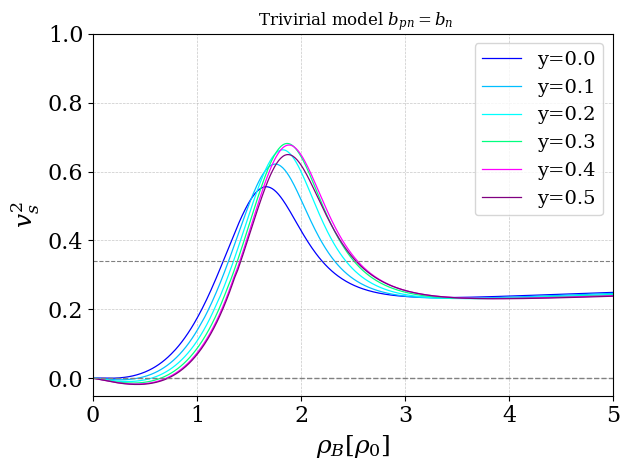

tvm model
isospin-dependent repulsion $b_n \neq b_{pn}$


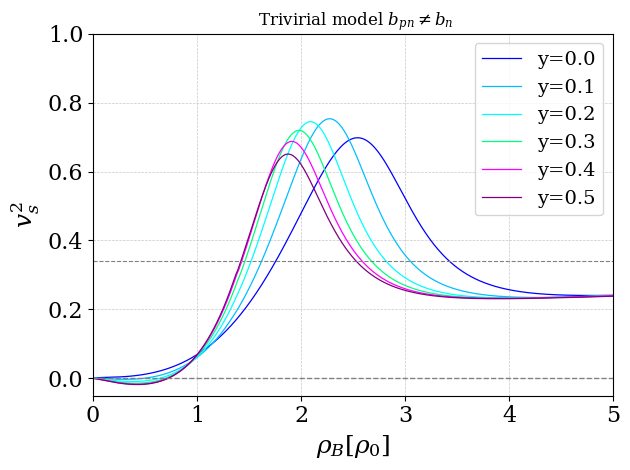

cs model
isospin-blind repulsion $b_n = b_{pn}$


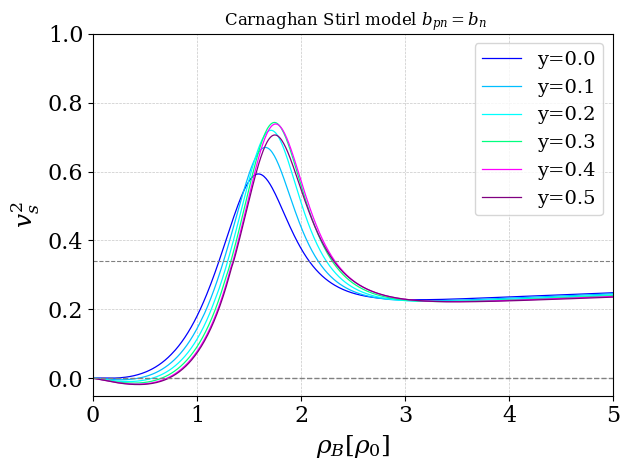

cs model
isospin-dependent repulsion $b_n \neq b_{pn}$


/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_66195/1766564253.py:72: RuntimeWarning: overflow encountered in scalar multiply
  return s * (h / 3.0)
/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_66195/1766564253.py:167: RuntimeWarning: overflow encountered in scalar multiply
  val = kbu**3 + (6.0*np.pi**2/g)*n_p_id
/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_66195/1766564253.py:166: RuntimeWarning: overflow encountered in divide
  n_p_id = n_p / f
/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_66195/1766564253.py:71: RuntimeWarning: overflow encountered in scalar add
  s += (4.0 if (i % 2) == 1 else 2.0) * f(x)
/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_66195/1766564253.py:71: RuntimeWarning: overflow encountered in scalar multiply
  s += (4.0 if (i % 2) == 1 else 2.0) * f(x)


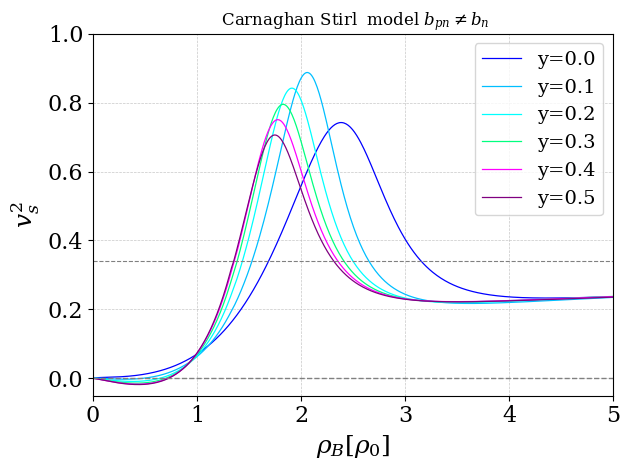

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from src.numerical_functions import *



# Properties for nucleons and quarks


g =2; mp = mn = 0.938 #GeV/c**2
Nc = 3; mu = md = mp/Nc; lam = 0.2 #GeV200;
rho0 = 1.23e-3  #GeV^3
rhob_list = np.linspace(1e-6, 5.0, 500) * rho0
y = 0.1; fq_min = 1e-3; fq_max = 1.0
fq_list = np.linspace(fq_min, fq_max, 500)
GEV4_TO_MEV_FM3 = 1.30148926289e5
print(len(fq_list))


bn = bpn = an = apn = None

isos_repulsion = "eq"
model = 'cs'
def main(isos_repulsion,model):
    global bn, bpn, an, apn

    if model == 'cs':
        print('cs model')
        # -------------------- CS parameters
        if isos_repulsion == "eq":
            an  = 36.93 #36.9
            bn  = 579.17 #577.
            apn = 53.60#1.45 * an
            bpn = 1.00 * bn
            print(r'isospin-blind repulsion $b_n = b_{pn}$')
        elif isos_repulsion == "neq":
            an  = 26.535 #26.6
            bn  =383.788#383.
            apn =63.999 #2.40 * an
            bpn = 774.64 #2.01 * bn
            print(r'isospin-dependent repulsion $b_n \neq b_{pn}$')
    elif model == 'tvm':
        print('tvm model')
        # -------------------- TVM parameters


        if isos_repulsion == 'eq':
        # bpn = bn
            an = 37.33    #26.4
            bn = 560.08  #361
            apn = 53.72#1.43 * an
            bpn = 1.0 * bn
            print(r'isospin-blind repulsion $b_n = b_{pn}$')

        elif isos_repulsion == 'neq':
        # bpn neq bn
            an = 26.78#37.33    #26.4
            bn = 363.72 #560.08  #361
            apn = 64.67 #2.44 * an
            bpn = 756.4 #2.08 * bn
            print(r'isospin-dependent repulsion $b_n \neq b_{pn}$')


    # ------------- help-functions
    def integrate_simpson(f, a, b, n=1000):
        h = (b - a) / n
        s = f(a) + f(b)
        x = a
        for i in range(1, n):
            x += h
            s += (4.0 if (i % 2) == 1 else 2.0) * f(x)
        return s * (h / 3.0)

    # Ideal quarks u,d energy density

    def f1(q):
        return q * np.sqrt(lam**2 + q**2) * np.sqrt(mu**2 + q**2)
    def f2(q):
        return q * np.sqrt(lam**2 + q**2) * np.sqrt(md**2 + q**2)

    def euid(kbu, y, N=1000):
        k = g / (2 * np.pi**2)
        result = (1+y)/(2-y) * integrate_simpson(f1,0,kbu / Nc)#simpson(f, x=q)
        return Nc * k * result
    def edid(kbu, N=1000):
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f2,0,kbu / Nc)
        return Nc * k * result

    # Ideal proton, neutrons energy density

    def f3(k):
        return k**2 * np.sqrt(mn**2 + k**2)
    def f4(k):
        return k**2 * np.sqrt(mp**2 + k**2)

    def enid(kbu, kfn, N=1000):
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f3,kbu, kfn)
        return k * result
    def epid(kbu, kfp, N=1000):
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f4,kbu, kfp)
        return k * result

    # Ideal quarks u,d baryon density

    def f5(q):
        return q * np.sqrt(lam**2 + q**2)
    def f6(q):
        return q * np.sqrt(lam**2 + q**2)

    def nuid(kbu, y, N=1000):
        k = g / (2 * np.pi**2)
        result = (1+y)/(2-y) * integrate_simpson(f5,0,kbu / Nc)#simpson(f, x=q)
        return Nc * k * result
    def ndid(kbu, N=1000):
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f6,0,kbu / Nc)
        return Nc * k * result

    # Ideal proton, neutrons baryon density

    def f7(k):
        return k**2
    def f8(k):
        return k**2

    def nnid(kbu, kfn, N=1000):
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f7,kbu, kfn)
        return k * result
    def npid(kbu, kfp, N=1000):
        k = g / (2 * np.pi**2)
        result = integrate_simpson(f7,kbu, kfp)
        return k * result

    def kbu_solver(rhob, fq, y):
        k = g / (2.0*np.pi**2)
        w = (3.0/(2.0 - y)) * k
        nq = rhob * fq
        inside = (3.0*nq/w + lam**3)**(2.0/3.0) - lam**2
        return Nc * np.sqrt(max(inside, 0.0))


    def f_tvm(x):
        return np.exp(-x - 0.5*x**2)

    def f_cs(x):
        out = np.full_like(x, np.nan, dtype=float)
        m = x < 4.0
        xm = x[m]
        out[m] = np.exp(-(3*xm)/(4 - xm) - (4*xm)/((4 - xm)**2))
        return out

    def kfp_solver_CS_TVM(rhob, fq, y, kbu, model="tvm"):
        global bpn, bn
        n_p = rhob*(1.0 - fq)*y
        n_n = rhob*(1.0 - fq)*(1.0 - y)
        x_p = (bn*n_p + bpn*n_n)

        f = f_tvm(x_p) if model=="tvm" else f_cs(x_p)
        if not np.isfinite(f) or f <= 0:
            return np.nan

        n_p_id = n_p / f
        val = kbu**3 + (6.0*np.pi**2/g)*n_p_id
        return np.cbrt(max(val, 0.0))

    def kfn_solver_CS_TVM(rhob, fq, y, kbu, model="tvm"):
        global bpn, bn
        n_p = rhob*(1.0 - fq)*y
        n_n = rhob*(1.0 - fq)*(1.0 - y)
        x_n = bpn*n_p + bn*n_n

        f = f_tvm(x_n) if model=="tvm" else f_cs(x_n)
        if not np.isfinite(f) or f <= 0:
            return np.nan

        n_n_id = n_n / f
        val = kbu**3 + (6.0*np.pi**2/g)*n_n_id
        return np.cbrt(max(val, 0.0))


    def xx_of_fq(
        fq,
        rhob,
        y,
        *,
        model,
        bn, bpn, an, apn,
        kbu_solver,
        kfp_solver_CS_TVM,
        kfn_solver_CS_TVM,
        euid, edid, enid, epid,
        f_tvm, f_cs,
    ):
        # --- solve momenta
        kbu = kbu_solver(rhob, fq, y)
        kfp = kfp_solver_CS_TVM(rhob, fq, y, kbu, model=model)
        kfn = kfn_solver_CS_TVM(rhob, fq, y, kbu, model=model)

        # --- single-particle energies
        eu = euid(kbu, y=y)
        ed = edid(kbu)
        en = enid(kbu, kfn)
        ep = epid(kbu, kfp)

        # --- densities
        n_p = rhob * (1.0 - fq) * y
        n_n = rhob * (1.0 - fq) * (1.0 - y)

        # --- x_p, x_n
        x_p = (bn * n_p + bpn * n_n)
        x_n = (bpn * n_p + bn * n_n)

        # original guard
        if model == "cs" and ((x_p >= 4.0) or (x_n >= 4.0)):
            return np.nan

        # --- f(x)
        fp = f_tvm(x_p) if model == "tvm" else f_cs(x_p)
        fn = f_tvm(x_n) if model == "tvm" else f_cs(x_n)

        if (not np.isfinite(fp)) or (not np.isfinite(fn)) or (fp <= 0) or (fn <= 0):
            return np.nan

        nuclear_int = fp * ep + fn * en - an*(n_p**2 + n_n**2) - 2.0*apn*n_p*n_n
        return eu + ed + nuclear_int


    def xx_of_fq_list(fq_list, rhob, y, **kwargs):
        # returns a numpy array same length as fq_list
        return np.array([xx_of_fq(fq, rhob, y, **kwargs) for fq in fq_list], dtype=float)

    def energy_of_fq(fq):
        return xx_of_fq(
        fq, rhob, y,
        model=model,
        bn=bn, bpn=bpn, an=an, apn=apn,
        kbu_solver=kbu_solver,
        kfp_solver_CS_TVM=kfp_solver_CS_TVM,
        kfn_solver_CS_TVM=kfn_solver_CS_TVM,
        euid=euid, edid=edid, enid=enid, epid=epid,
        f_tvm=f_tvm, f_cs=f_cs,
    )

    # colors = ['black','red','yellow','green','blue']

    colors = ['blue', 'deepskyblue', 'cyan', 'springgreen', 'magenta', 'purple']

    y_list = [0.0,0.1, 0.2, 0.3, 0.4, 0.5]

    plt.figure()

    for iy, y in enumerate(y_list):
        energy_density_list = []

        for rhob in rhob_list:
            # xx = []
            xx = xx_of_fq_list(
            fq_list, rhob, y,
            model=model,
            bn=bn, bpn=bpn, an=an, apn=apn,
            kbu_solver=kbu_solver,
            kfp_solver_CS_TVM=kfp_solver_CS_TVM,
            kfn_solver_CS_TVM=kfn_solver_CS_TVM,
            euid=euid, edid=edid, enid=enid, epid=epid,
            f_tvm=f_tvm, f_cs=f_cs,
        )
            fq_star = gss(energy_of_fq, fq_min, fq_max, tol=1e-7)
            E_star  = energy_of_fq(fq_star)
            energy_density_list.append(E_star)

            # print(E_star)
            # fig_fq = plt.figure()
            # plt.plot(fq_list, xx, color=colors[iy], label=f"y={y:.1f}", lw=0.9)
            # plt.scatter([fq_star], [E_star], s=60, marker="o", color=colors[iy], edgecolors="k", zorder=5)
            # plt.annotate(
            #     f"min\nfq={fq_star:.3f}\nE={E_star:.3e}",
            #     (fq_star, E_star),
            #     textcoords="offset points",
            #     xytext=(8, 8),
            #     ha="left",
            #     fontsize=9
            # )

            # plt.legend()
            # plt.show()
            # plt.close(fig_fq)

        energy_density_arr = np.asarray(energy_density_list, float)
        # plt.plot(
        #     rhob_list/rho0,
        #     energy_density_arr / rhob_list - mn,
        #     color=colors[iy],
        #     label=f"y={y:.1f}",lw=0.9
        # )
        # mu_b = derivative(rhob_list, energy_density_arr)
        # mu_bb = derivative(rhob_list, mu_b)
        E = np.array(energy_density_arr)

        mu_b = np.gradient(E, rhob_list, edge_order=2)
        mu_bb = np.gradient(mu_b, rhob_list, edge_order=2)
        
        pressure = rhob_list * mu_b - E
        
        E_MeVfm3 = E * 1.30148926289e5
        P_MeVfm3 = pressure * 1.30148926289e5
        
        fname = f"energy_vs_pressure_{model}_{isos_repulsion}_y{y:.1f}.dat"
        data_out = np.column_stack((E_MeVfm3, P_MeVfm3))

        np.savetxt(
            fname,
            data_out,
            header="MeV/fm^3               MeV/fm^3\nenergy_density         pressure",
            fmt="%.10e",
            comments="# "
        )
        
        vs2 = rhob_list/mu_b * mu_bb
      
        plt.plot(
            rhob_list/rho0,
            vs2,
            color=colors[iy],
            label=f"y={y:.1f}",lw=0.9
        )
    plt.rcParams.update({
        'font.family': 'serif',
        'mathtext.fontset': 'dejavuserif',
        'axes.labelsize': 18,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 14,
    })
    plt.ylim(-0.05, 1.0)
    plt.xlim(0, 5)
    plt.xlabel(r"$\rho_B [\rho_0]$")
    plt.ylabel(r"$v_s^2$")
    plt.axhline(y=0.34, color='gray', linestyle='--', linewidth=0.8)
    if isos_repulsion == 'eq':
        plt.title(r'$b_{pn} = b_n$')
    elif   isos_repulsion == 'neq':
        plt.title(r'$b_{pn} \neq b_{pn}$')

    if model == 'tvm':
        if isos_repulsion == 'eq':
            plt.title(r' Trivirial model $b_{pn} = b_n$')
        elif   isos_repulsion == 'neq':
            plt.title(r' Trivirial model $b_{pn} \neq b_n$')

    elif model== 'cs':
        if isos_repulsion == 'eq':
            plt.title(r' Carnaghan Stirl model $b_{pn} = b_n$')
        elif   isos_repulsion == 'neq':
            plt.title(r' Carnaghan Stirl  model $b_{pn} \neq b_n$')

    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

    plt.legend()

    plt.tight_layout()
    # if model == 'tvm':
    #     if isos_repulsion == 'eq':
    #         plt.savefig("./vs2TVM_eq.png", dpi=90, bbox_inches="tight")
    #         plt.savefig("./vs2TVM_eq.pdf", bbox_inches="tight")
    #     elif   isos_repulsion == 'neq':
    #         plt.savefig("./vs2TVM_neq.png", dpi=90, bbox_inches="tight")
    #         plt.savefig("./vs2TVM_neq.pdf", bbox_inches="tight")
    # elif model== 'cs':
    #     if isos_repulsion == 'eq':
    #             plt.savefig("./vs2cs_eq.png", dpi=90, bbox_inches="tight")
    #             plt.savefig("./vs2cs_eq.pdf", bbox_inches="tight")
    #     elif isos_repulsion == 'neq':
    #         plt.savefig("./vs2cs_neq.png", dpi=90, bbox_inches="tight")
    #         plt.savefig("./vs2cs_neq.pdf", bbox_inches="tight")
    plt.show()
    plt.close()

main('eq','tvm')
main('neq','tvm')
main('eq','cs')
main('neq','cs')
